<img src="https://www.austral.edu.ar/wp-content/uploads/2022/10/facultades-horizontales-03.png" width="50%" alt="Universidad Austral - Facultad de Ingeniería">

# Maestría en Ciencia de Datos 2024/2025

## Fundamentos del Aprendizaje Automático - Trabajo práctico Final

Integrantes:
- Cancelas, Martín.
-	Filipuzzi, Juan Manuel.
-	Gallardo, Ezequiel.
-	Nicolau, Jorge.

## **Configuración**

### Librerías

In [ ]:
# manejo de dataframes y cálculos
!pip install -q numpy pandas
# recoleccion y formateo de datos
!pip install -q dask google-colab ipython tabulate
!pip install -q --no-cache-dir scipy==1.13.1
!pip install -q --no-cache-dir ipython==7.34.0, google-colab
!pip install -q --no-cache-dir ydata-profiling==4.17.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 246.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 323.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 363.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 259.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 231.4 MB/s eta 

In [ ]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tabulate import tabulate
from collections import Counter
from google.colab import files
from IPython.display import display, HTML, Markdown
from matplotlib.backends.backend_pdf import PdfPages

### Obtención de dataset.

In [ ]:
url_csv = "https://raw.githubusercontent.com/georgsmeinung/mlops-pipeline/refs/heads/main/data/df_automl-serie_diaria.csv"
df = dd.read_csv(url_csv)

## **Preprocesamiento**

### Verificación de la estructura del dataset.

Información general.

In [ ]:
def dask_info(df, memory=True):
    nrows = len(df)
    ncols = len(df.columns)
    dtypes = df.dtypes
    nulls = df.isnull().sum().compute()

    max_col_len = max(len(col) for col in df.columns)

    print(f"<dask.dataframe.DataFrame>")
    print(f"RangeIndex: 0 to {nrows-1}")
    print(f"Data columns (total {ncols} columns):")
    for i, col in enumerate(df.columns):
        non_nulls = nrows - nulls[col]
        print(f" {i:<3} {col:<{max_col_len}}  {str(dtypes[col]):<10}  non-null={non_nulls:<6}  nulls={nulls[col]}")

    type_counts = Counter(map(str, dtypes))
    type_summary = ", ".join([f"{t}({c})" for t, c in type_counts.items()])
    print(f"dtypes: {type_summary}")

    if memory:
        part = df.get_partition(0).compute()
        mem_est = (part.memory_usage(deep=True).sum() / len(part)) * nrows
        print(f"memory usage: ~{mem_est/1024**2:.2f} MB (estimado)")

dask_info(df)

<dask.dataframe.DataFrame>
RangeIndex: 0 to 1185
Data columns (total 28 columns):
 0   dia                                  string      non-null=1186    nulls=0
 1   dia_semana                           int64       non-null=1186    nulls=0
 2   feriado                              int64       non-null=1186    nulls=0
 3   laborable                            int64       non-null=1186    nulls=0
 4   temp_min                             string      non-null=1186    nulls=0
 5   temp_max                             string      non-null=1186    nulls=0
 6   cant_socios                          int64       non-null=1186    nulls=0
 7   prom_edad_soc                        int64       non-null=1186    nulls=0
 8   consultas_guardia                    int64       non-null=1186    nulls=0
 9   total_cursos                         int64       non-null=1186    nulls=0
 10  internaciones                        int64       non-null=1186    nulls=0
 11  prom_t_internacion_min               string 

In [ ]:
df.head()

,dia,dia_semana,feriado,laborable,temp_min,temp_max,cant_socios,prom_edad_soc,consultas_guardia,total_cursos,...,cant_visitas,cant_moli_medico_on_line,prom_arribo_min_rojo,prom_arribo_min_amarillo,prom_arribo_min_visitas,prom_arribo_min_moli_medico_on_line,med_arribo_min_rojo,med_arribo_min_amarillo,med_arribo_min_visitas,med_arribo_min_moli_medico_on_line
0,2022-01-01,7,1,0,20,"27,5",104384,36,303,209,...,10,152,"26,79375","115,4346154","178,115","29,32620614","16,85833333","61,675","105,1583333","24,95"
1,2022-01-02,1,0,0,"19,2","30,3",104384,36,397,307,...,10,241,"69,92833333","159,6981481","147,705","40,58201936","33,71666667","62,75","143,55","31,41666667"
2,2022-01-03,2,0,1,"24,1","32,6",104384,36,540,670,...,22,557,"32,06190476","142,0301587","144,7227273","56,14847397","27,11666667","39,38333333","84,025","52,98333333"
3,2022-01-04,3,0,1,"23,8","31,7",104384,36,595,575,...,23,480,"129,4744444","133,3067708","215,7398551","47,74052083","46,13333333","75,65","122,6833333","38,24166667"
4,2022-01-05,4,0,1,"16,7","25,1",104384,36,536,627,...,15,540,"47,9047619","117,3734375","344,2966667","58,45777778","23,63333333","64,3","160,1166667","47,5"


In [ ]:
df.compute().sample(5, random_state=42)

,dia,dia_semana,feriado,laborable,temp_min,temp_max,cant_socios,prom_edad_soc,consultas_guardia,total_cursos,...,cant_visitas,cant_moli_medico_on_line,prom_arribo_min_rojo,prom_arribo_min_amarillo,prom_arribo_min_visitas,prom_arribo_min_moli_medico_on_line,med_arribo_min_rojo,med_arribo_min_amarillo,med_arribo_min_visitas,med_arribo_min_moli_medico_on_line
319,2022-11-16,4,0,1,"19,4","29,6",109334,36,442,172,...,29,53,"16,57083333","50,07179487","195,0241379","21,7572327","18,2","48,2","139,5166667","13,6"
956,2024-08-14,4,0,1,"8,3","16,5",105565,37,469,171,...,18,94,"17,82037037","31,53968254","164,2861111","38,4998227","13,53333333","28,38333333","48,54166667","26,41666667"
1182,2025-03-28,6,0,1,"21,0","26,7",107041,38,404,160,...,11,55,"16,08095238","35,05294118","162,7530303","49,27848485",15,"28,16666667","161,8166667","25,95"
86,2022-03-28,2,0,1,"16,7","25,5",105459,36,577,284,...,42,152,"22,47833333","118,1623932","211,3115079","66,58333333","21,39166667",44,"196,2583333","60,71666667"
990,2024-09-17,3,0,1,"15,1",21,105689,37,493,183,...,25,93,"54,08333333","32,22604167","182,406","19,87043011","21,85833333","25,41666667","88,58333333","15,86666667"


In [ ]:
df.tail()

,dia,dia_semana,feriado,laborable,temp_min,temp_max,cant_socios,prom_edad_soc,consultas_guardia,total_cursos,...,cant_visitas,cant_moli_medico_on_line,prom_arribo_min_rojo,prom_arribo_min_amarillo,prom_arribo_min_visitas,prom_arribo_min_moli_medico_on_line,med_arribo_min_rojo,med_arribo_min_amarillo,med_arribo_min_visitas,med_arribo_min_moli_medico_on_line
1181,2025-03-27,5,0,1,"20,1","27,0",107041,38,412,140,...,17,64,"22,80416667","34,53611111","195,6264706","51,12604167","10,16666667","29,26666667","172,9666667","42,39166667"
1182,2025-03-28,6,0,1,"21,0","26,7",107041,38,404,160,...,11,55,"16,08095238","35,05294118","162,7530303","49,27848485",15,"28,16666667","161,8166667","25,95"
1183,2025-03-29,7,0,0,"17,8","26,2",107041,38,353,118,...,6,56,"14,9530303","37,23888889","92,68055556","35,4547619","14,66666667","33,58333333","96,50833333","31,40833333"
1184,2025-03-30,1,0,0,"21,0","29,0",107041,38,334,95,...,7,41,"338,8296296","33,85392157","267,4833333","56,1004065","26,18333333",27,"183,4166667","35,66666667"
1185,2025-03-31,2,0,1,"14,0","28,9",107041,38,505,153,...,18,71,"44,55","32,30378788","166,8101852","43,20798122","23,33333333","23,88333333","135,3666667","33,75"


### Optimización de uso de memoria.

Conversión de datos *string* a numéricos.

In [ ]:
cols_int = [
    "temp_min", "temp_max", "prom_t_internacion_min", "mediana_t_internacion_min",
    "prom_arribo_min_rojo", "prom_arribo_min_amarillo", "prom_arribo_min_visitas",
    "prom_arribo_min_moli_medico_on_line", "med_arribo_min_rojo", "med_arribo_min_amarillo",
    "med_arribo_min_visitas", "med_arribo_min_moli_medico_on_line"
]

keep_int64 = [c for c, t in df.dtypes.items() if str(t) == "int64" and c not in cols_int]
df["dia"] = dd.to_datetime(df["dia"], errors="coerce", meta=("dia", "datetime64[ns]"))

def _to_int_nullable(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    s = s.str.replace(",", ".", regex=False)
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True)
    out = pd.to_numeric(s, errors="coerce").astype("Int64")
    return out

for col in cols_int:
    df[col] = df[col].map_partitions(_to_int_nullable, meta=(col, "Int64"))

df = df.astype({c: "int64" for c in keep_int64})

Sugerencias de cambio de formato de datos.

In [ ]:
def sugerir_tipos_enteros(ddf):
    sugerencias = {}
    resumen = []
    enteros = [c for c, t in ddf.dtypes.items() if "int" in str(t).lower()]

    for col in enteros:
        minimo = ddf[col].min().compute()
        maximo = ddf[col].max().compute()
        if np.iinfo(np.int8).min <= minimo and maximo <= np.iinfo(np.int8).max:
            sugerido = "int8"
        elif np.iinfo(np.int16).min <= minimo and maximo <= np.iinfo(np.int16).max:
            sugerido = "int16"
        elif np.iinfo(np.int32).min <= minimo and maximo <= np.iinfo(np.int32).max:
            sugerido = "int32"
        else:
            sugerido = "int64"

        sugerencias[col] = sugerido
        resumen.append([col, str(ddf[col].dtype), minimo, maximo, sugerido])

    print(tabulate(resumen, headers=["Columna", "Tipo actual", "Mínimo", "Máximo", "Tipo sugerido"], tablefmt="pretty"))
    return sugerencias

sugerencias = sugerir_tipos_enteros(df)

+-------------------------------------+-------------+--------+--------+---------------+
|               Columna               | Tipo actual | Mínimo | Máximo | Tipo sugerido |
+-------------------------------------+-------------+--------+--------+---------------+
|             dia_semana              |    int64    |   1    |   7    |     int8      |
|               feriado               |    int64    |   0    |   1    |     int8      |
|              laborable              |    int64    |   0    |   1    |     int8      |
|              temp_min               |    Int64    |   1    |   28   |     int8      |
|              temp_max               |    Int64    |   9    |   37   |     int8      |
|             cant_socios             |    int64    | 104384 | 112187 |     int32     |
|            prom_edad_soc            |    int64    |   36   |   38   |     int8      |
|          consultas_guardia          |    int64    |  164   |  619   |     int16     |
|            total_cursos       

Función de optimización.

In [ ]:
def optimizar_enteros(ddf, sugerencias):
    ddf_opt = ddf.copy()
    for col, nuevo_tipo in sugerencias.items():
        if str(ddf_opt[col].dtype) != nuevo_tipo:
            ddf_opt[col] = ddf_opt[col].astype(nuevo_tipo)
    return ddf_opt

df_opt = optimizar_enteros(df, sugerencias)

Resultado de optimización.

In [ ]:
mem_antes = df.memory_usage(deep=True).sum().compute() / 1024**2
mem_despues = df_opt.memory_usage(deep=True).sum().compute() / 1024**2
ahorro = mem_antes - mem_despues

print(f"Consumo anterior: {mem_antes:.2f} MB")
print(f"Consumo actual: {mem_despues:.2f} MB")
print(f"Optimización: {ahorro:.2f} MB ({(ahorro/mem_antes*100):.2f}%)")

Consumo anterior: 0.27 MB
Consumo actual: 0.06 MB
Optimización: 0.21 MB (77.93%)


### Transformación a Pandas

Distintas librerías requieren que el *dataframe* se encuentre en formato Pandas.

In [ ]:
df_pandas = df_opt.compute()

## **Análisis Exploratorio - Auto EDA**

#### YData Profiling

[**YData Profiling**](https://docs.profiling.ydata.ai/latest/) es una librería de Python para análisis exploratorio de datos (*EDA*) que automatiza la generación de reportes detallados sobre datasets tabulares. Produce estadísticas descriptivas, visualizaciones de distribuciones, análisis de correlaciones, valores faltantes y posibles anomalías, así como alertas sobre calidad de los datos, todo en un solo reporte interactivo en HTML. Su objetivo es facilitar la comprensión rápida del dataset, detectar problemas de limpieza y estructuración, y acelerar la preparación de datos para machine learning, ofreciendo una visión integral sin necesidad de escribir múltiples líneas de código para análisis individuales.


In [ ]:
import ydata_profiling as pp

In [ ]:
profile = pp.ProfileReport(df_pandas, minimal=True)

# Almacenar reporte en formato HTML para visualización
profile.to_file("reporte_ydata.html")

# Alamacenar reporte en formato JSON para pipeline
profile.to_file("reporte_ydata.json")

# Descomentar para usar el resultado en pipeline
# files.download("/content/reporte_ydata.html")
# files.download("/content/reporte_ydata.json")

HTML(filename="reporte_ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 28/28 [00:00<00:00, 101.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Render JSON:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### SweetViz

[**SweetViz**](https://github.com/fbdesignpro/sweetviz) es una librería de Python enfocada en el análisis exploratorio de datos (*EDA*) que genera reportes visuales interactivos de manera automática. A partir de un dataset o de la comparación entre un conjunto de entrenamiento y otro de prueba, SweetViz produce estadísticas descriptivas, distribuciones, correlaciones y comparaciones de variables de forma clara y visual, destacando diferencias y similitudes entre datasets. Su objetivo es facilitar la comprensión de los datos, identificar posibles sesgos o anomalías, y acelerar la preparación de los datos para machine learning sin necesidad de crear manualmente gráficos o tablas estadísticas.


In [ ]:
# herramientas de autoeda y reporting
!pip install -q sweetviz autoviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.1 MB/s eta 0:00:00


In [ ]:
import warnings
import sweetviz as sv

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



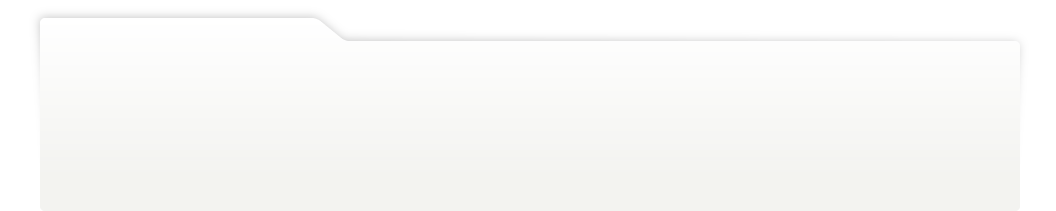
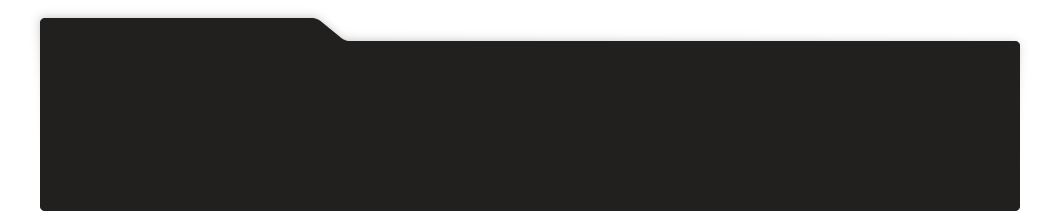
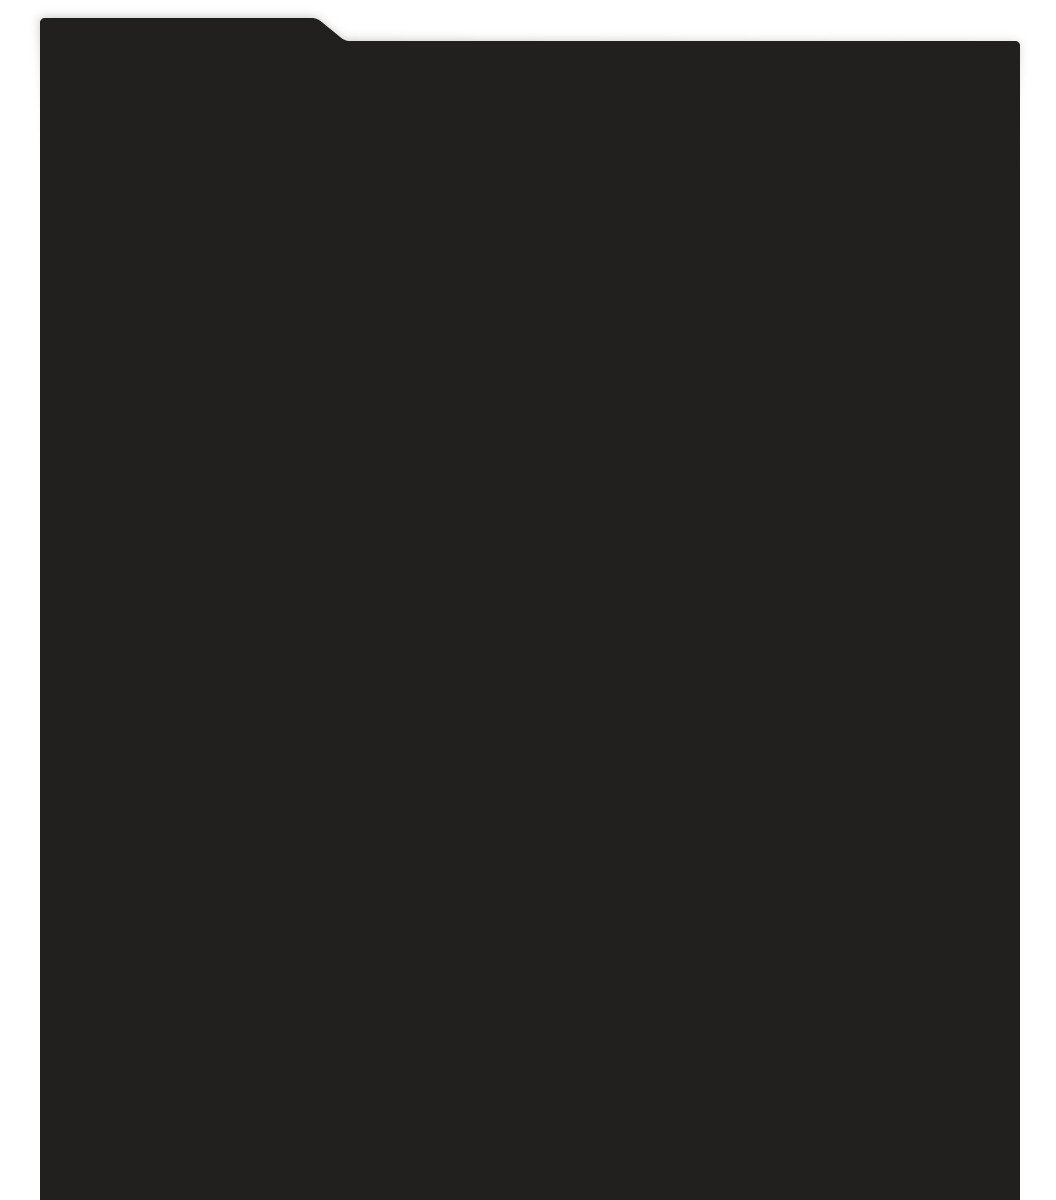
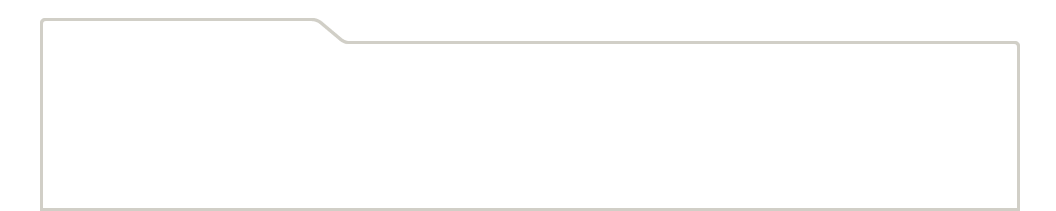
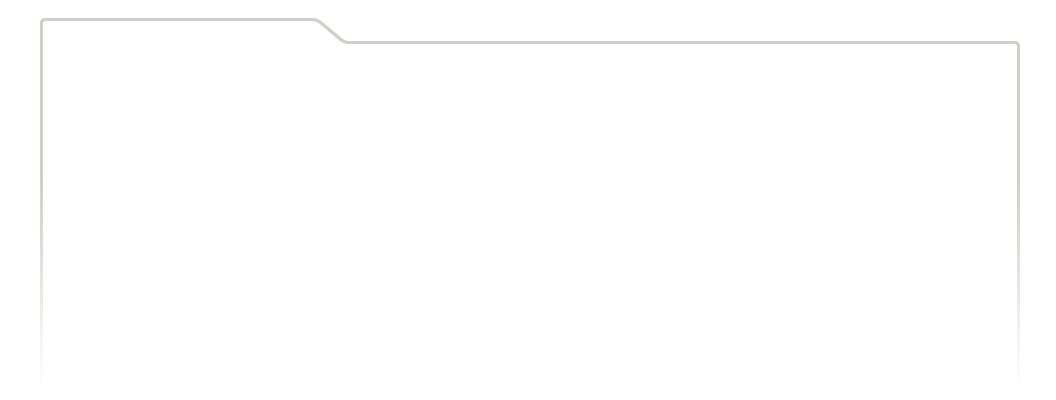
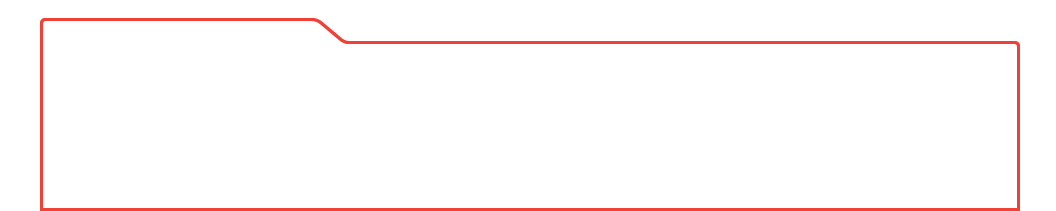
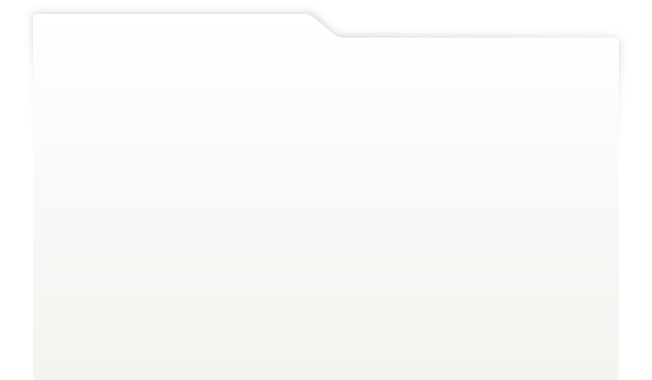
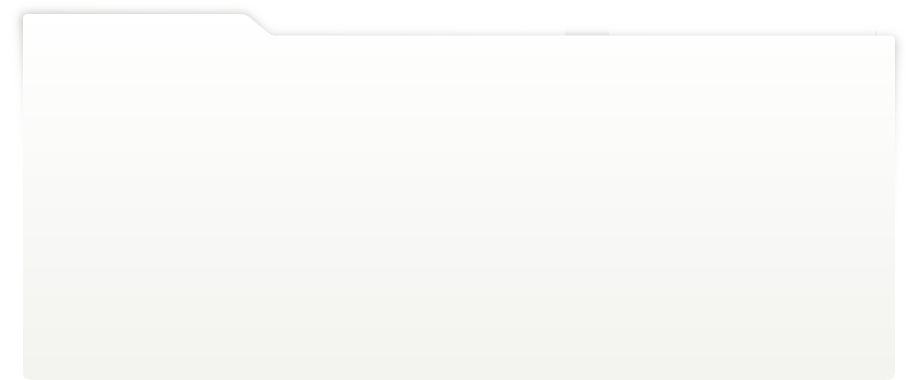
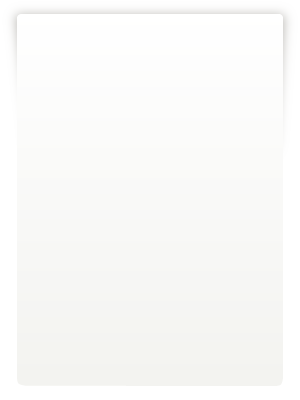
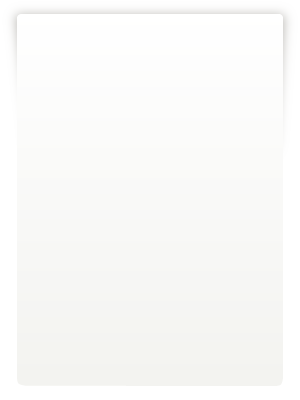
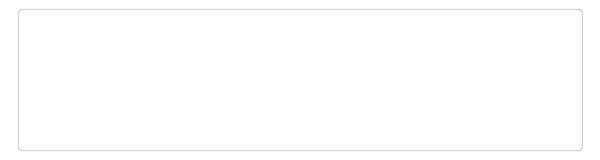
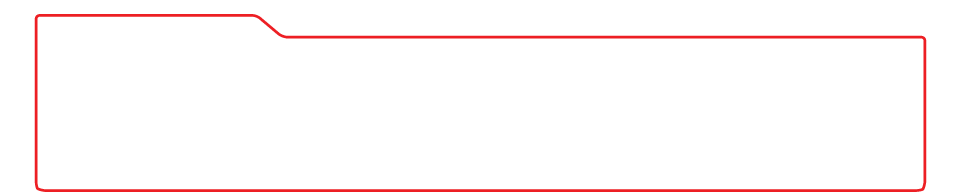
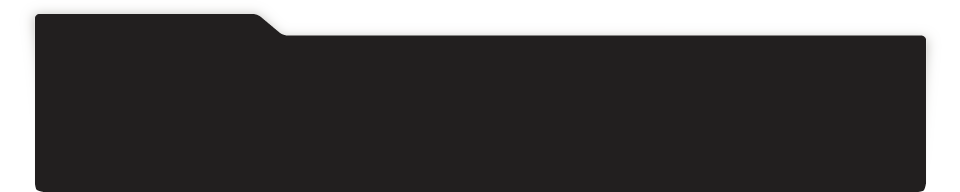
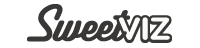
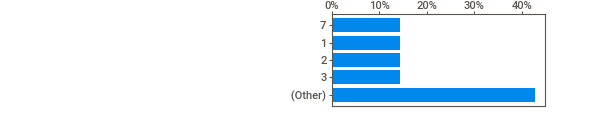
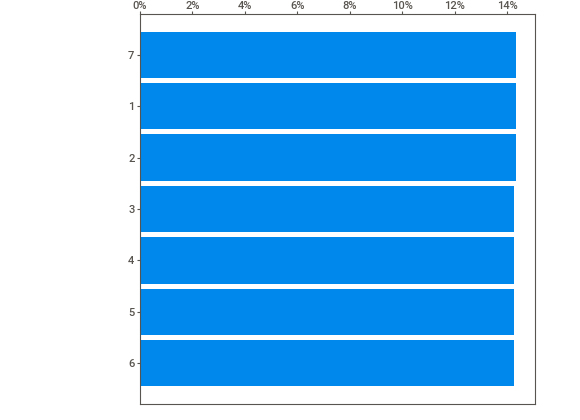
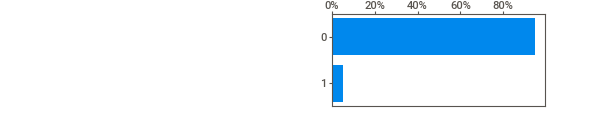
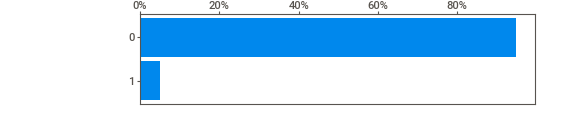
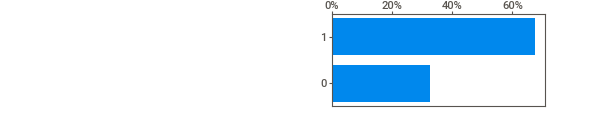
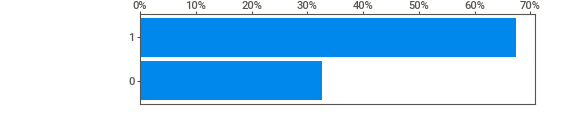
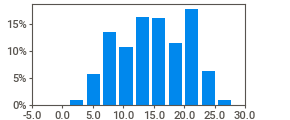
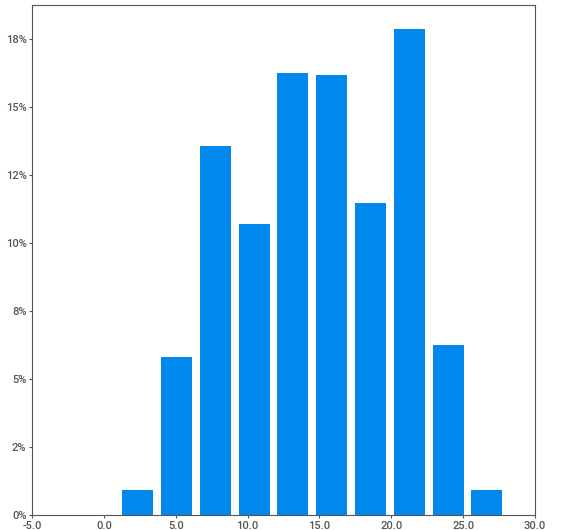
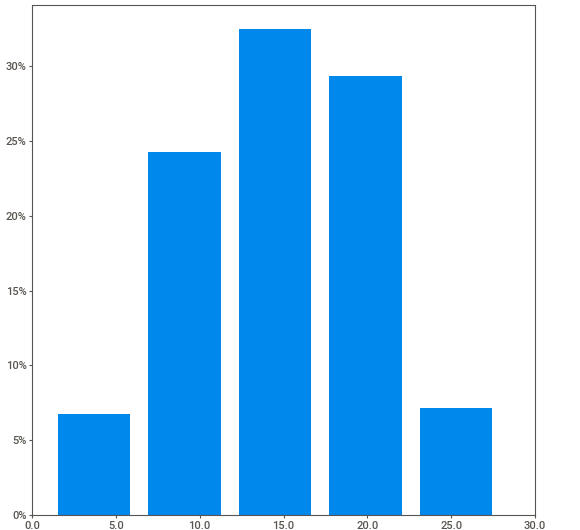
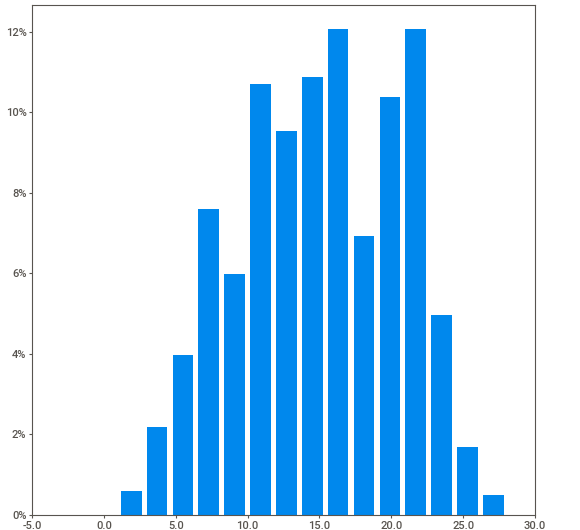
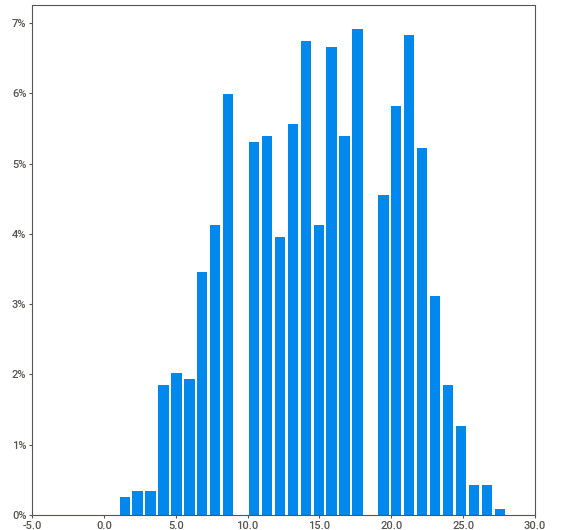
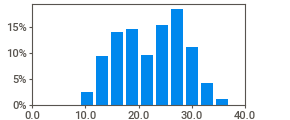
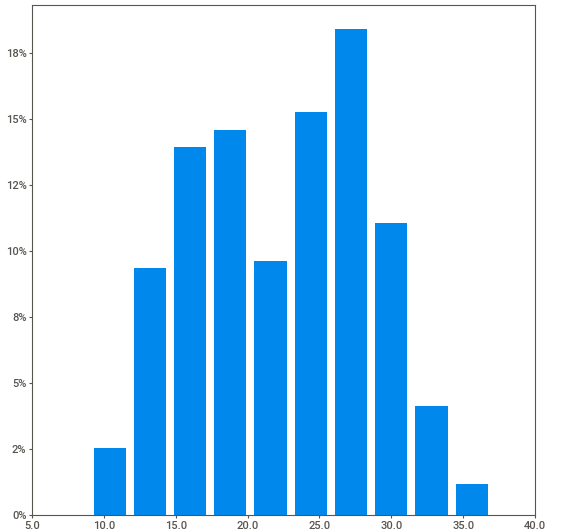
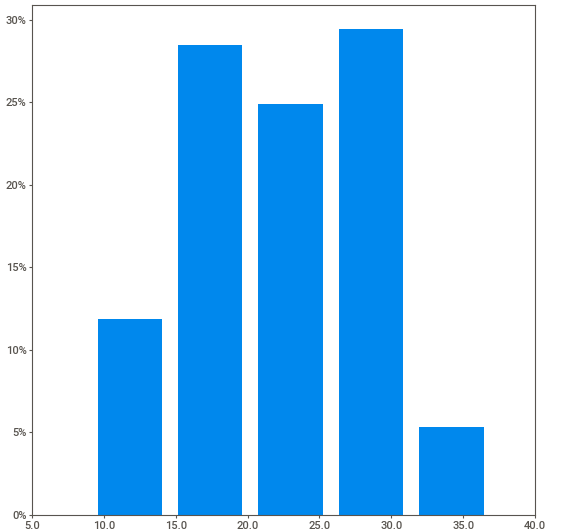
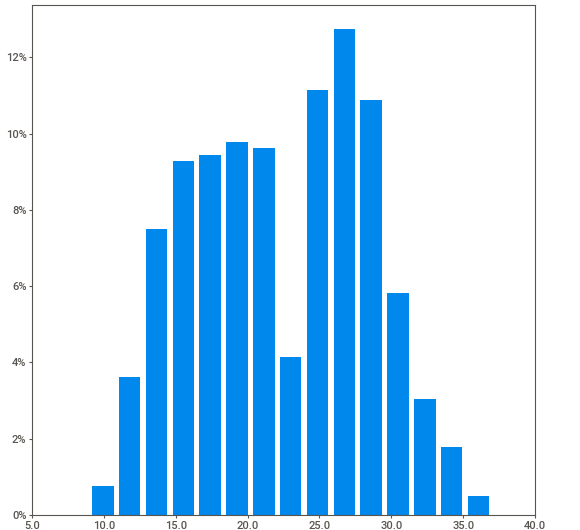
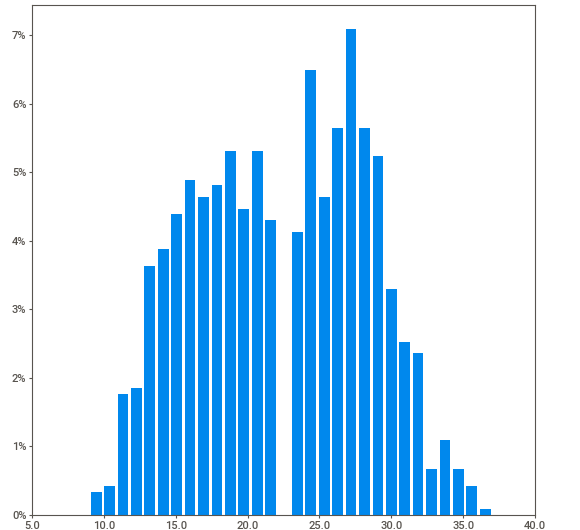
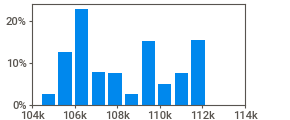
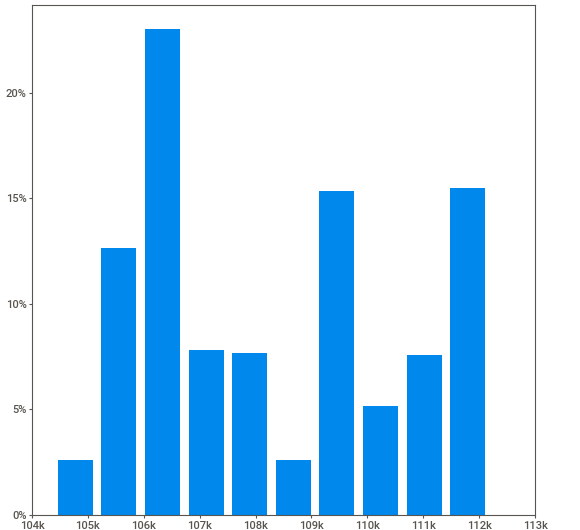
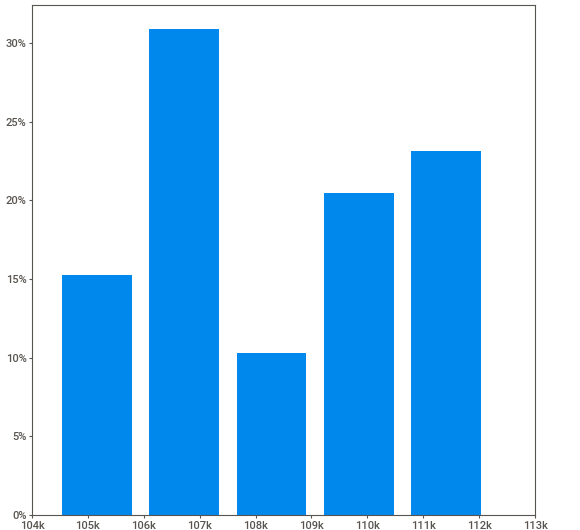
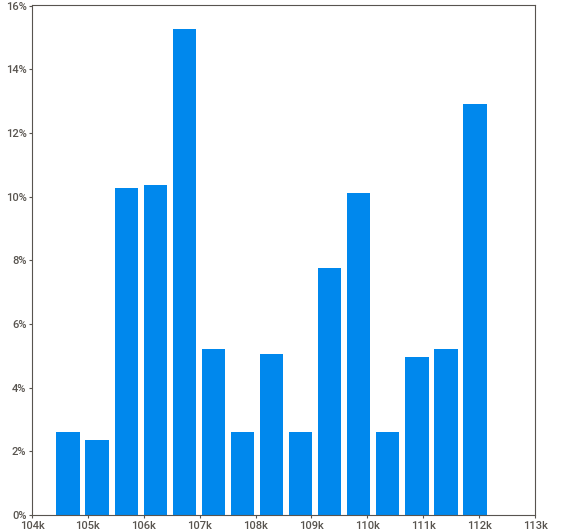
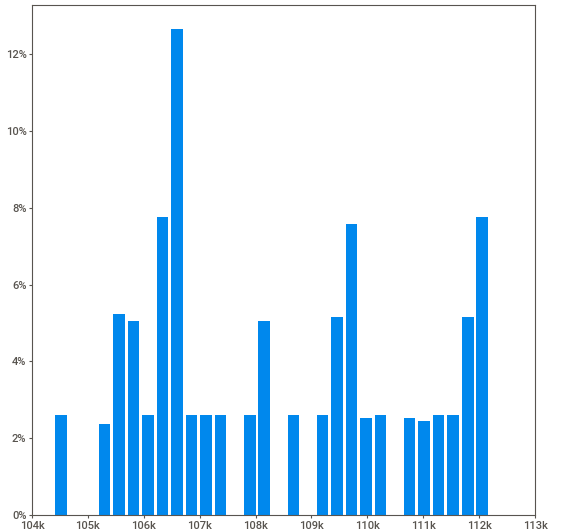
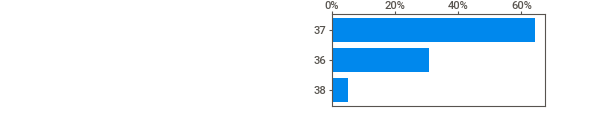
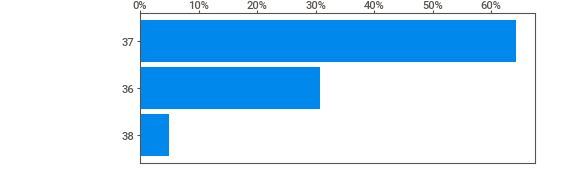
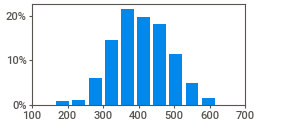
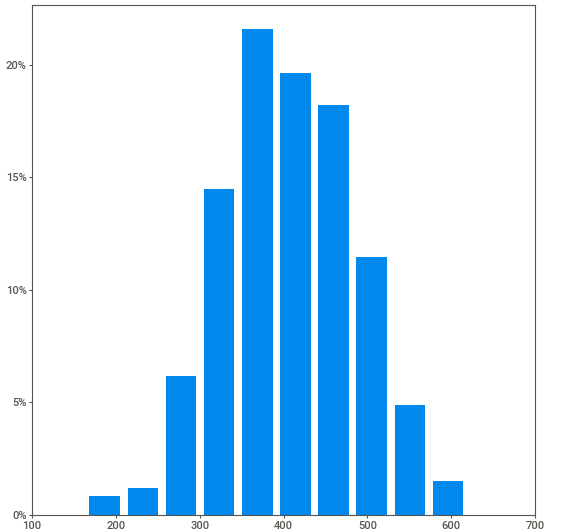
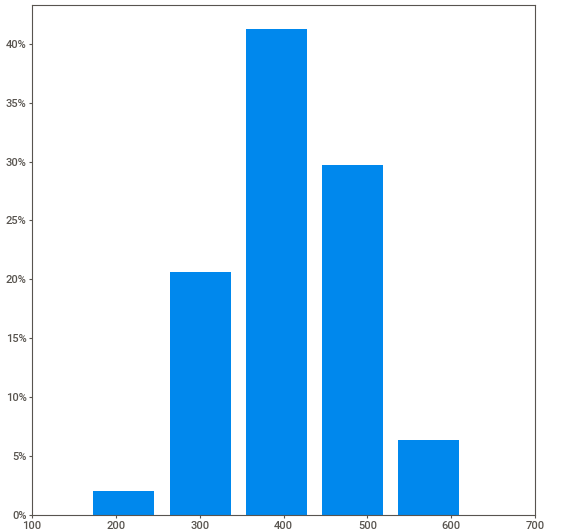
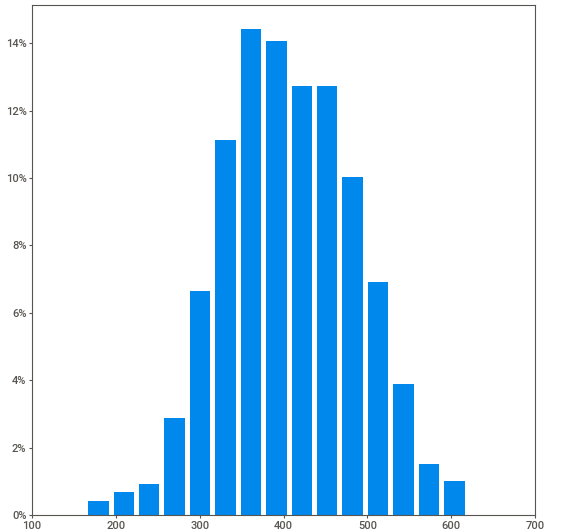
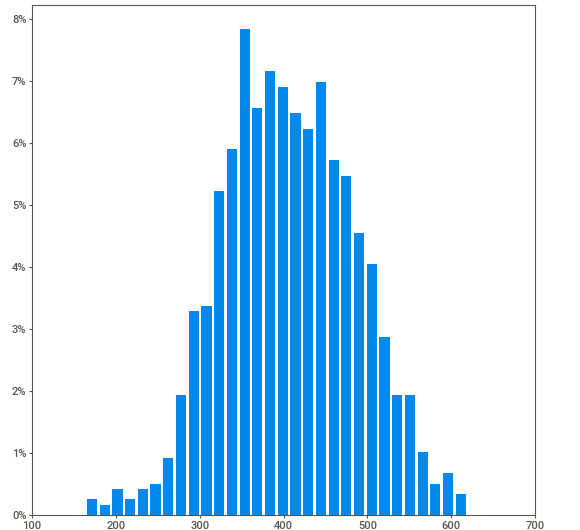
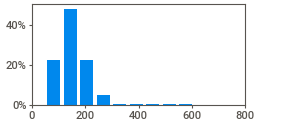
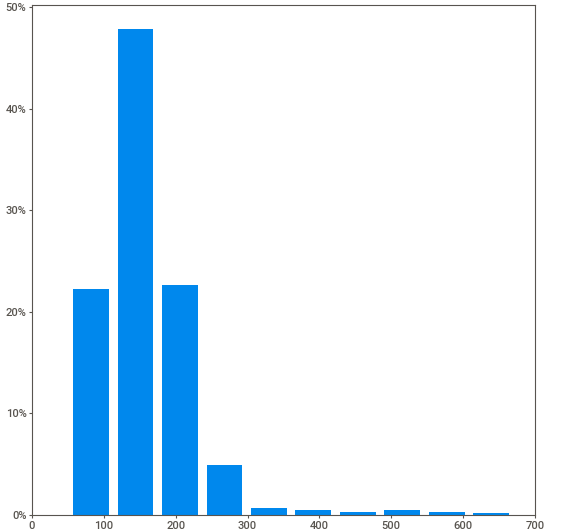
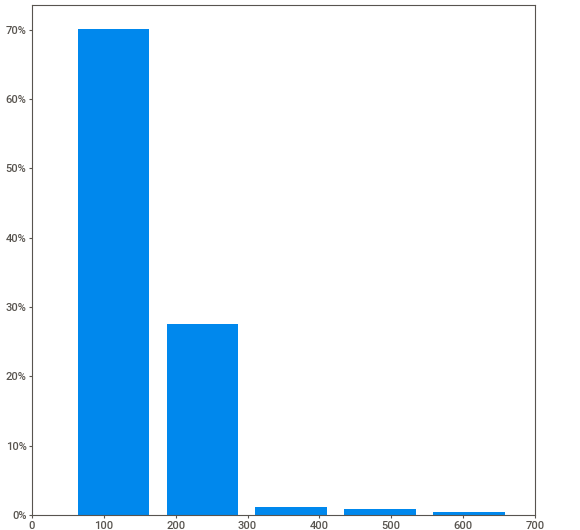
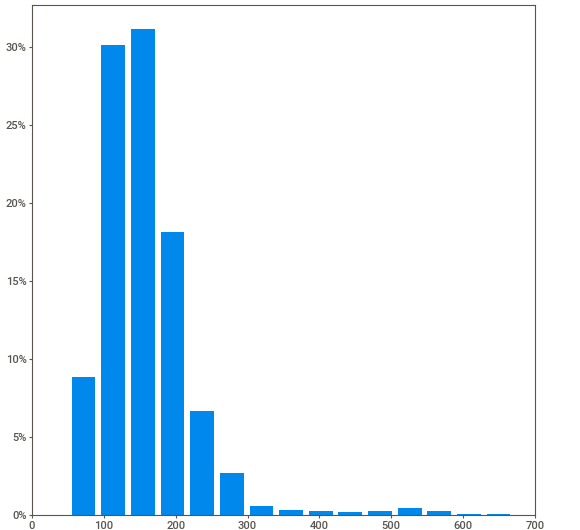
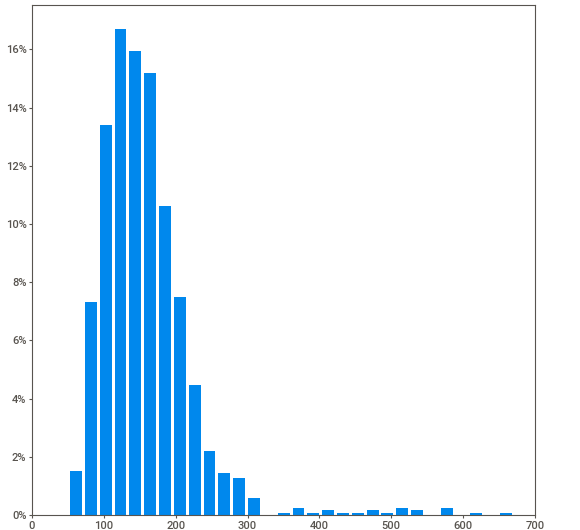
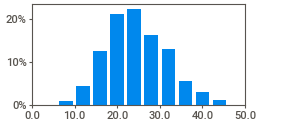
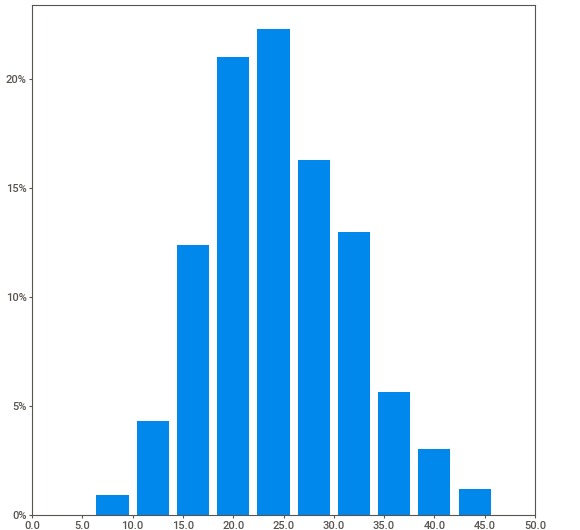
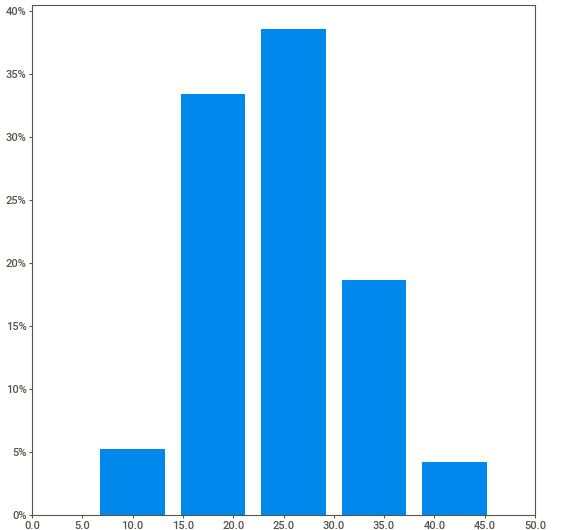
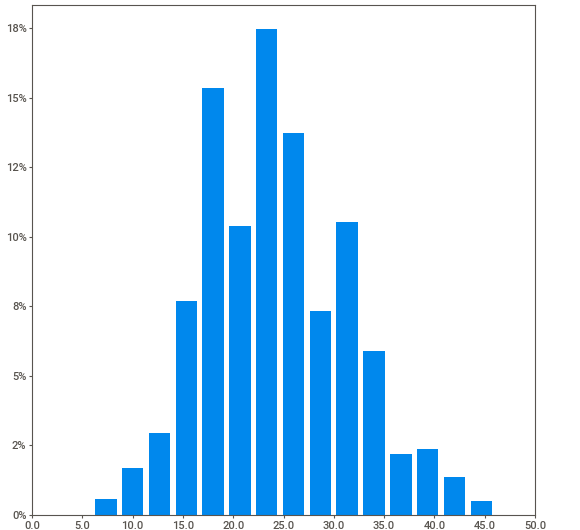
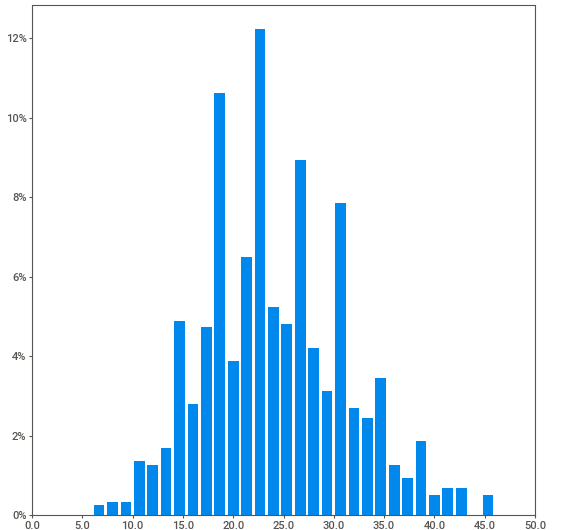
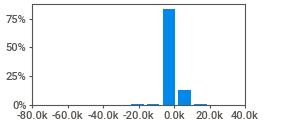
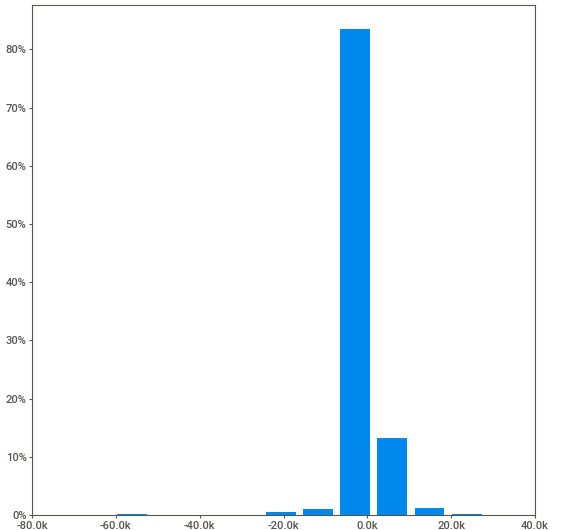
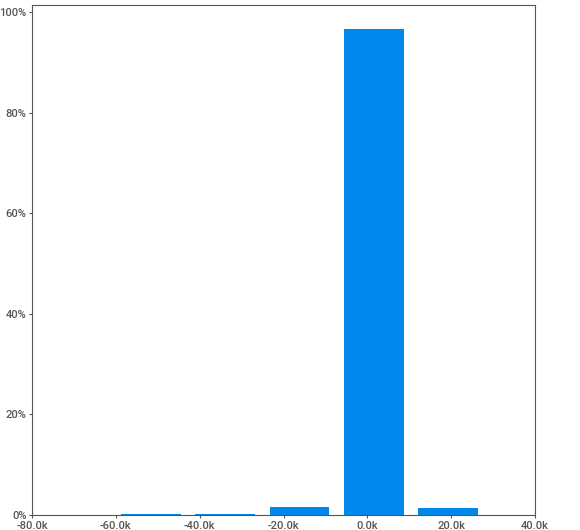
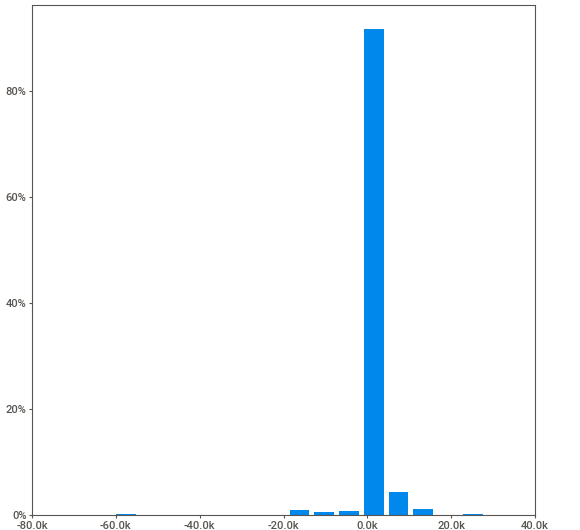
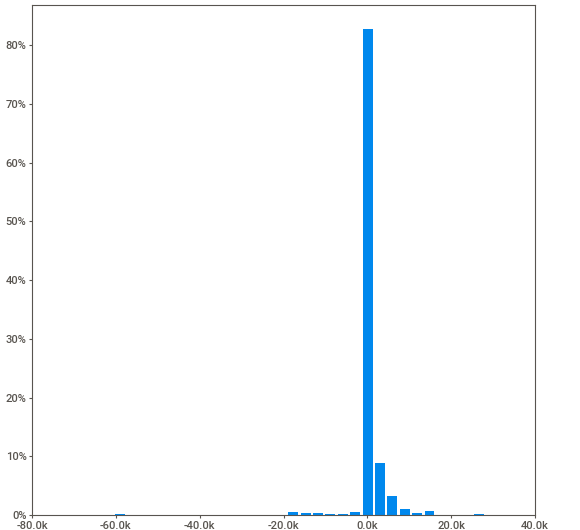
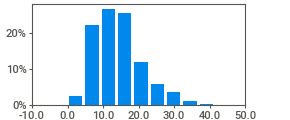
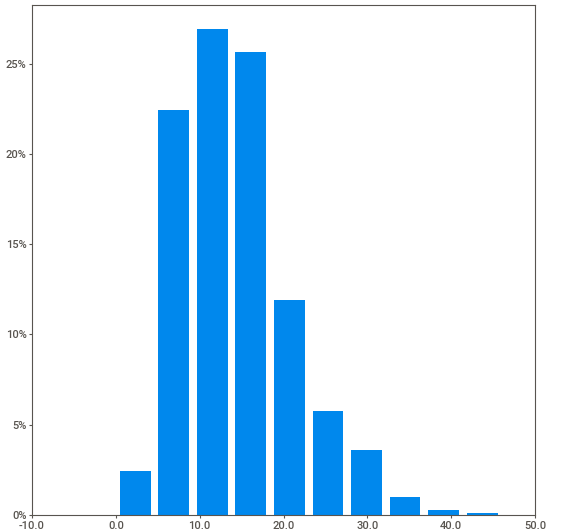
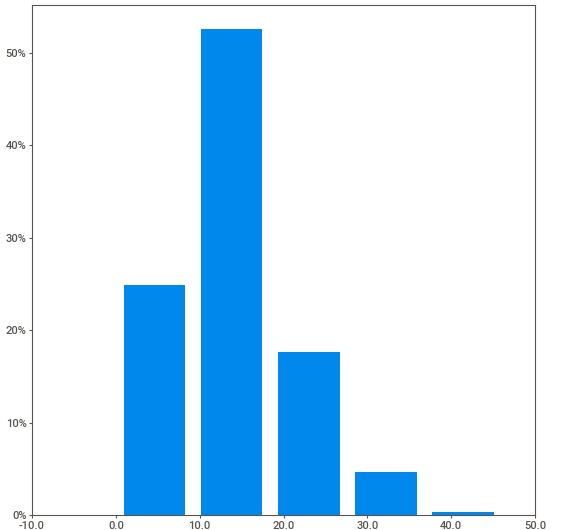
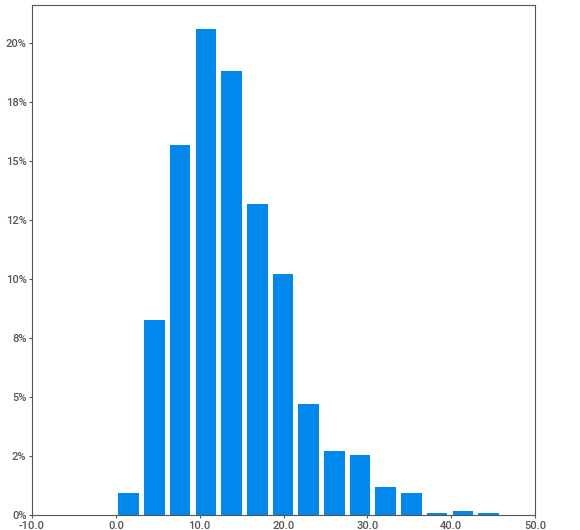
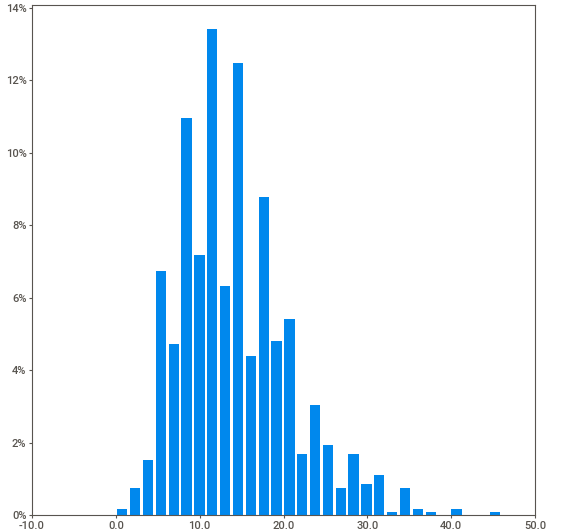
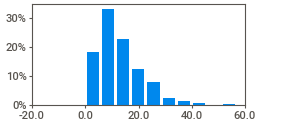
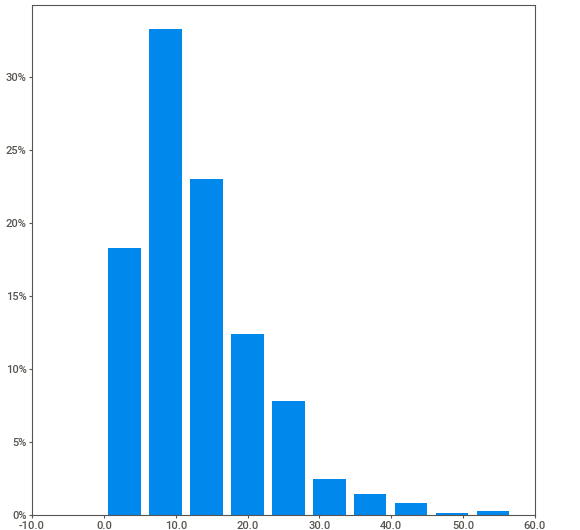
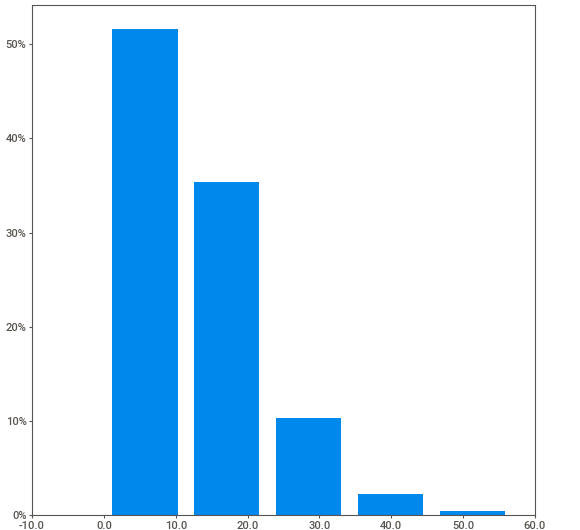
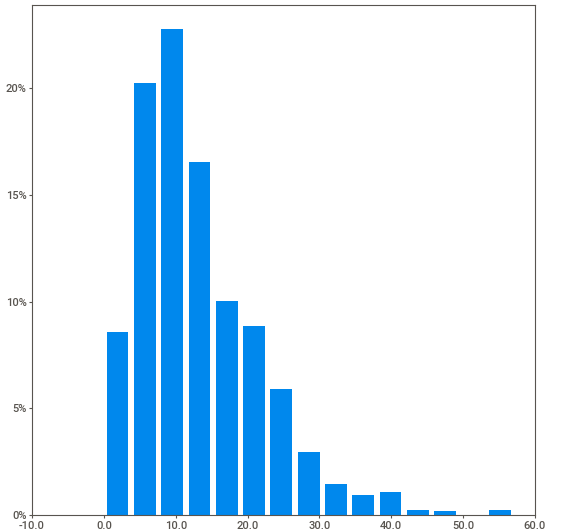
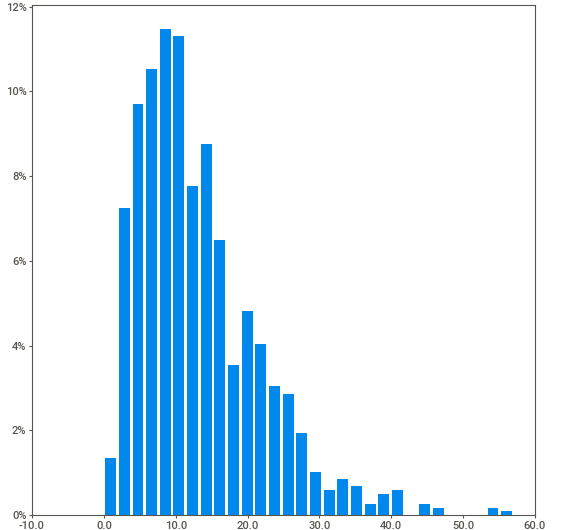
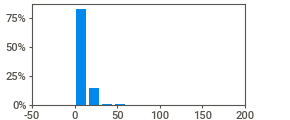
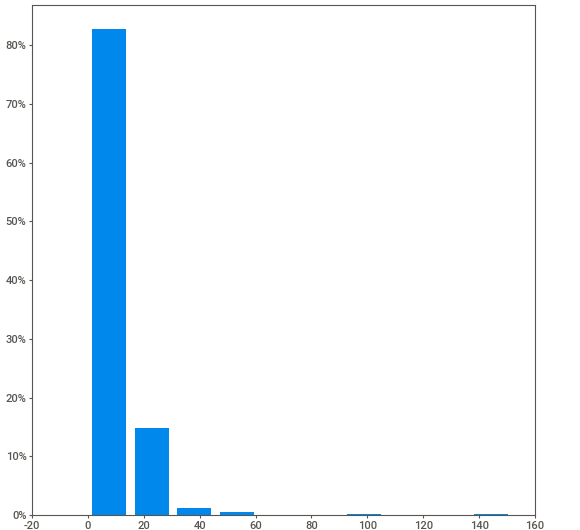
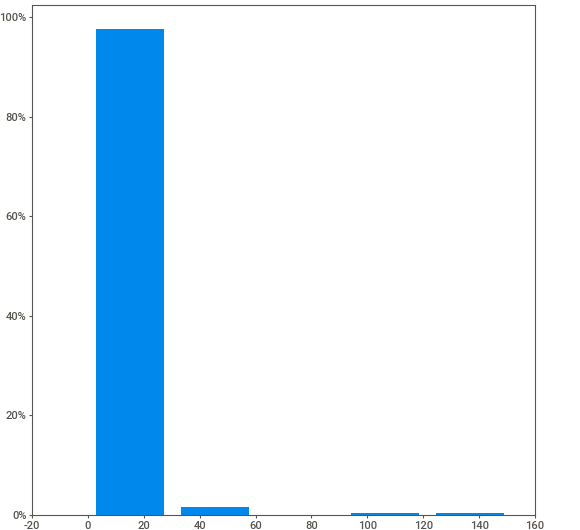
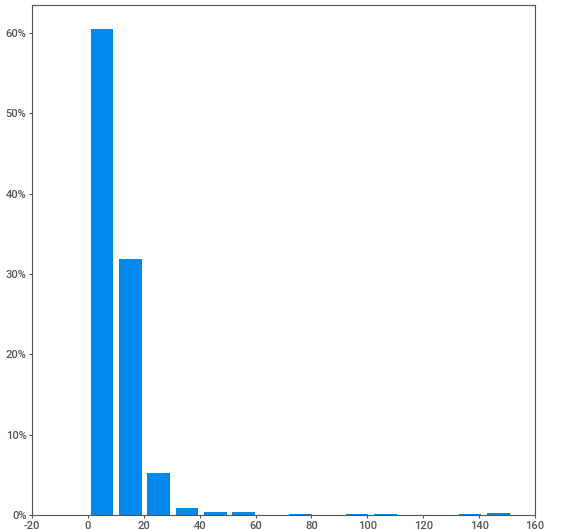
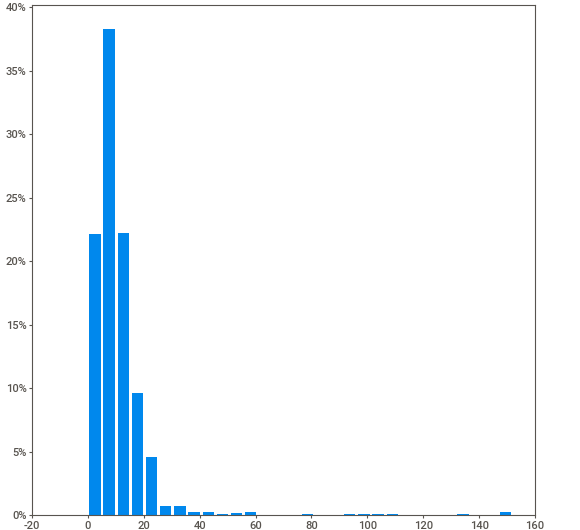
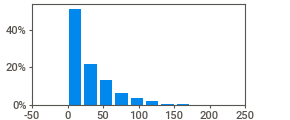
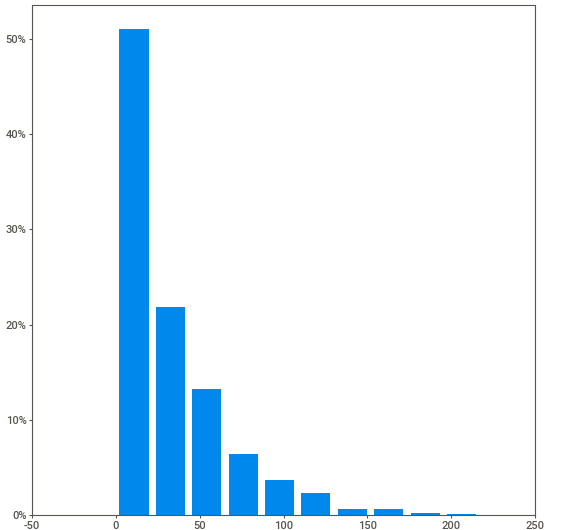
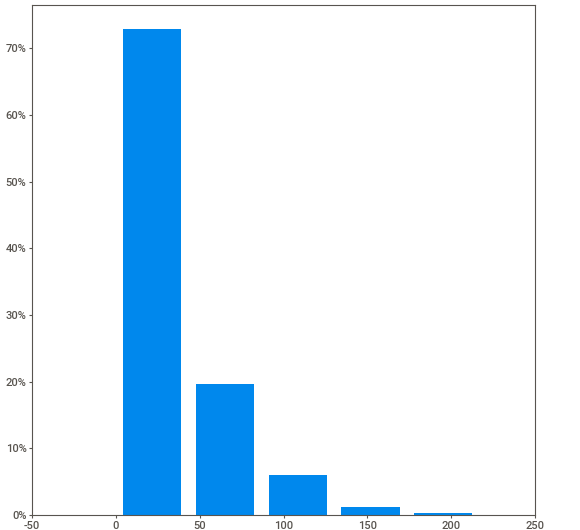
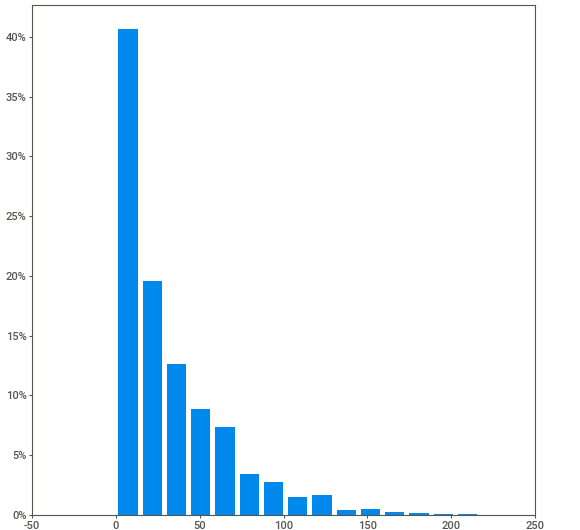
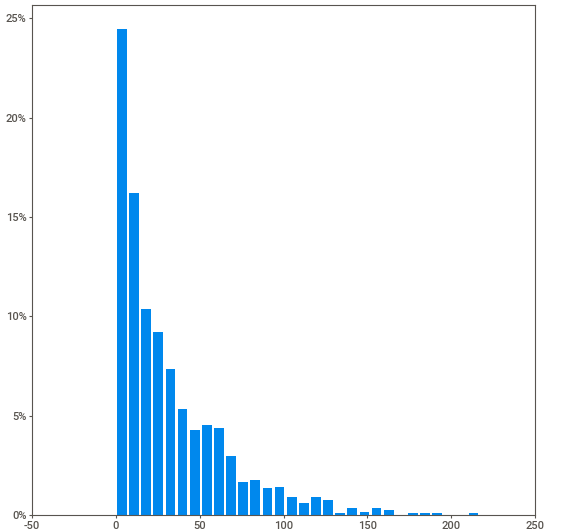
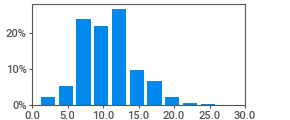
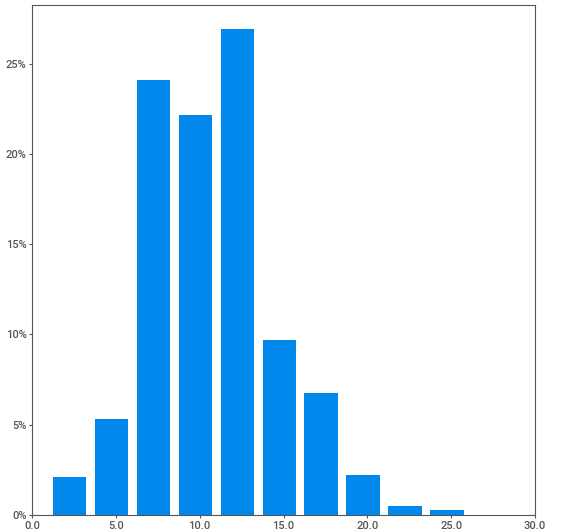
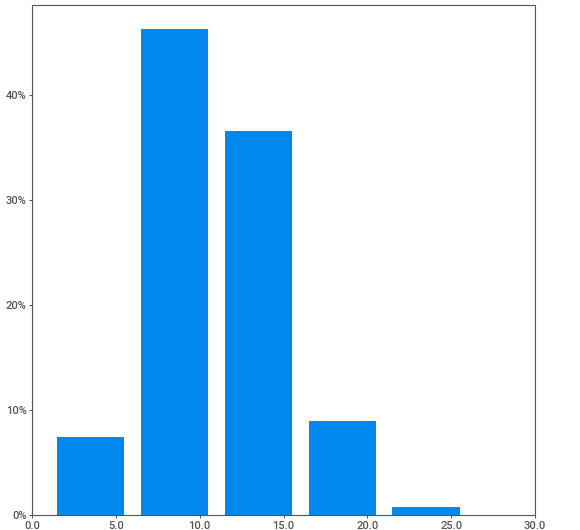
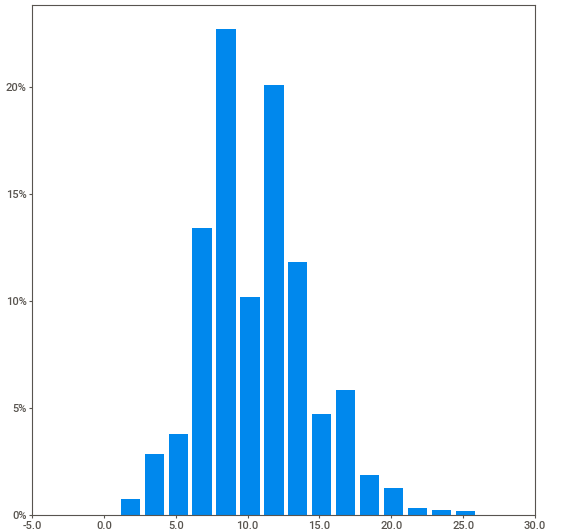
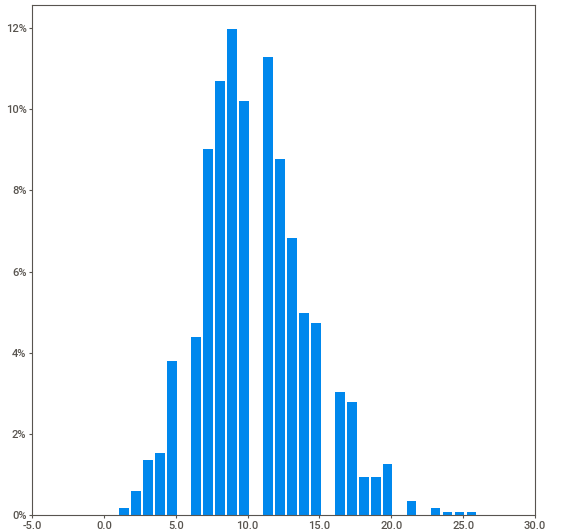
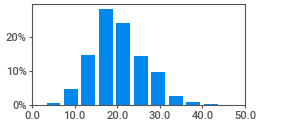
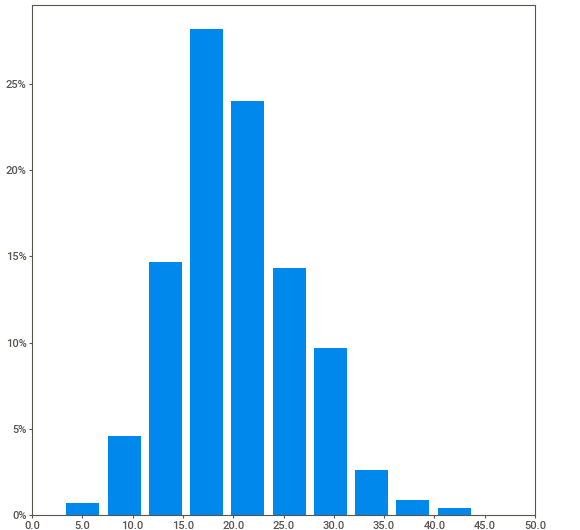
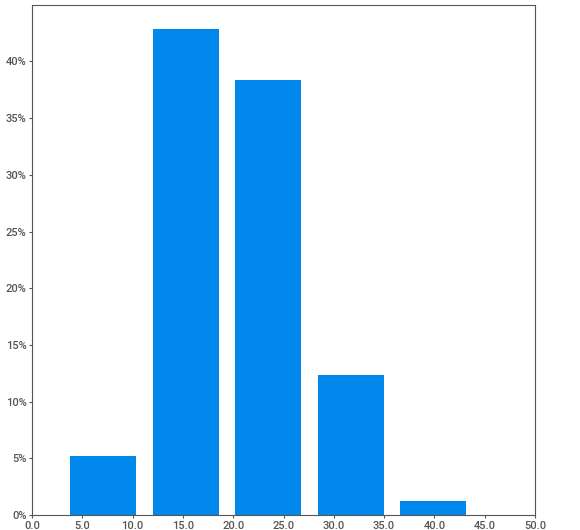
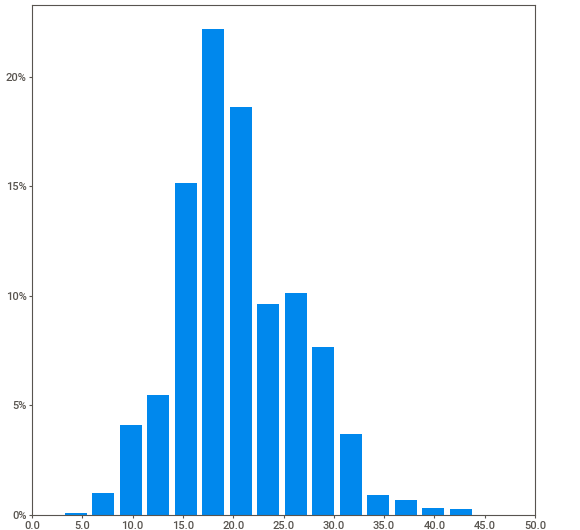
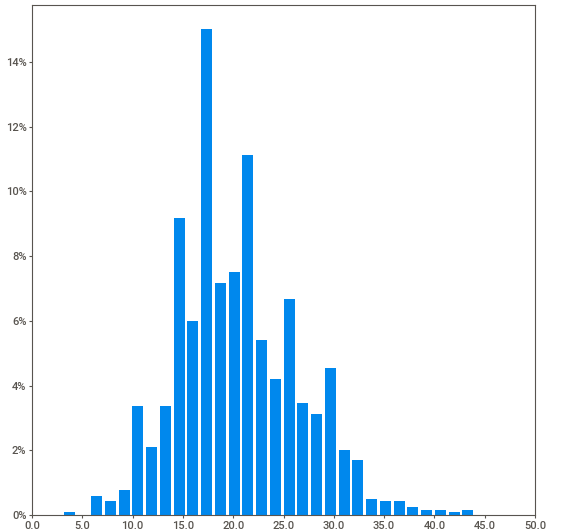
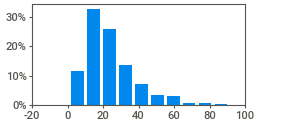
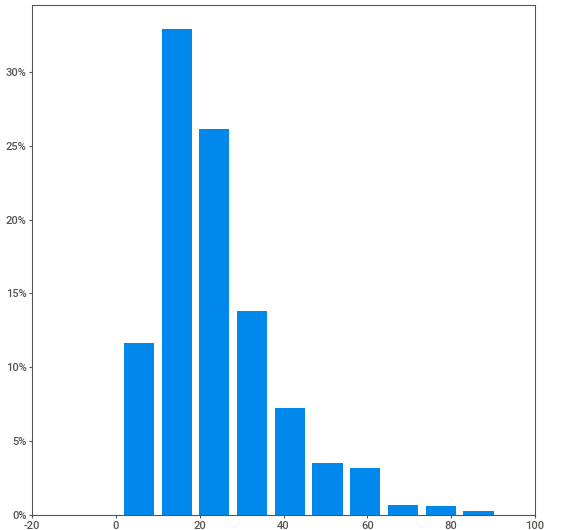
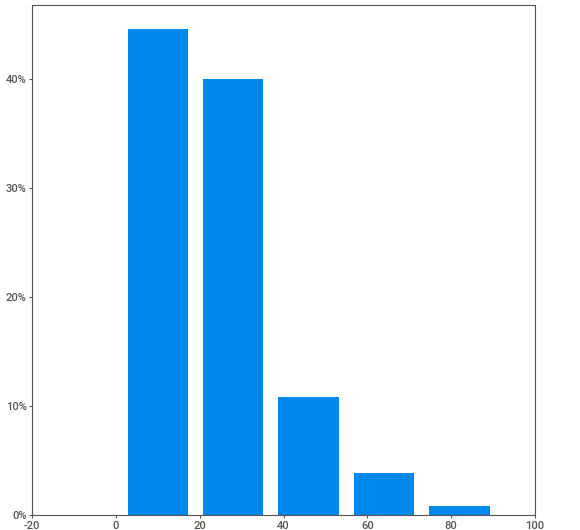
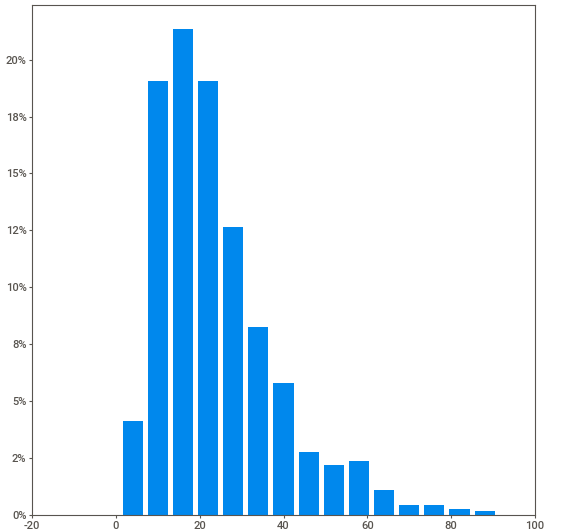
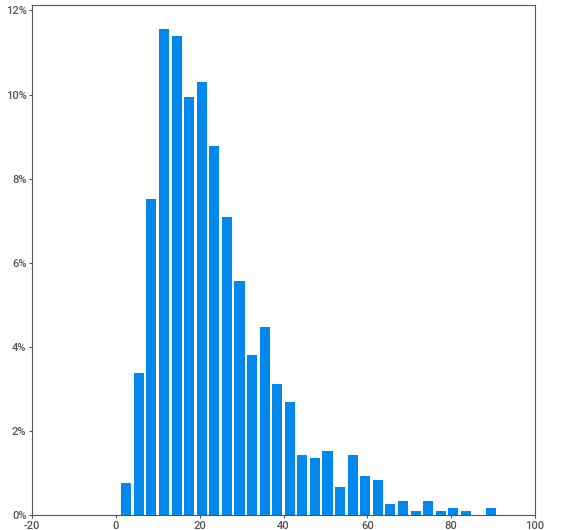
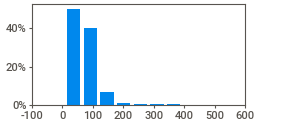
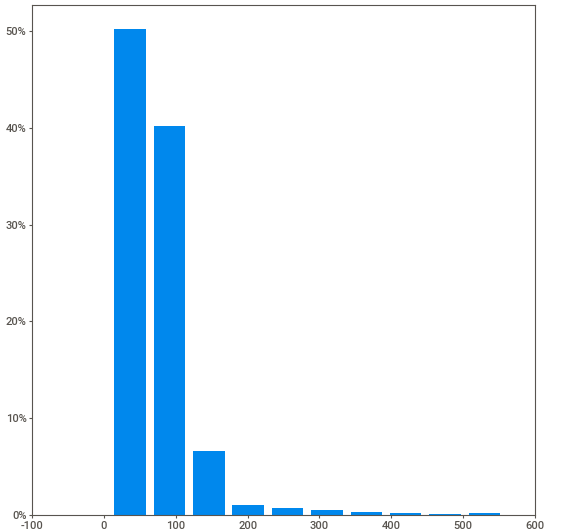
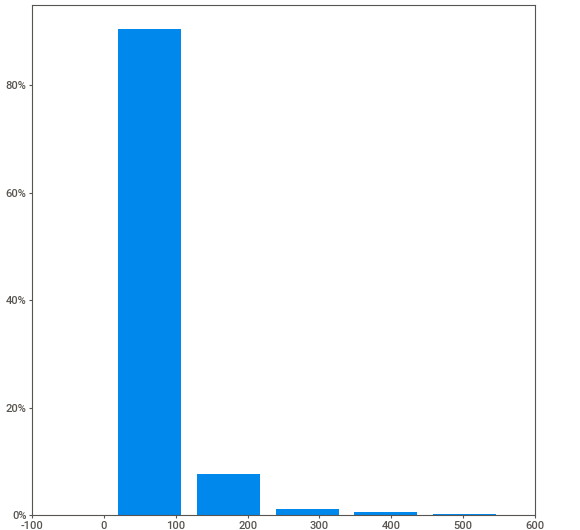
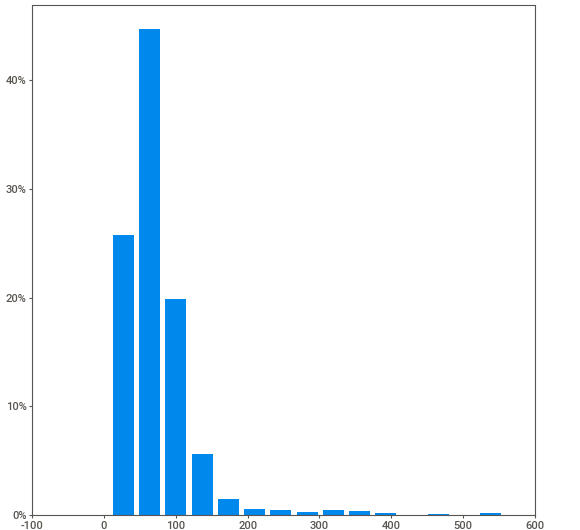
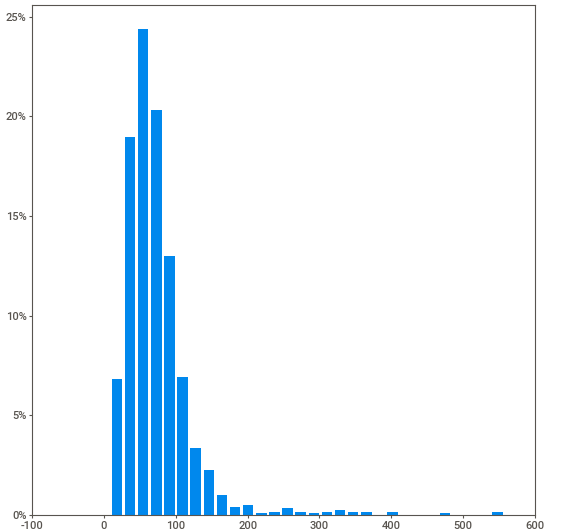
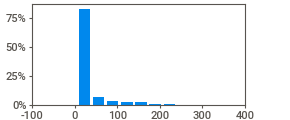
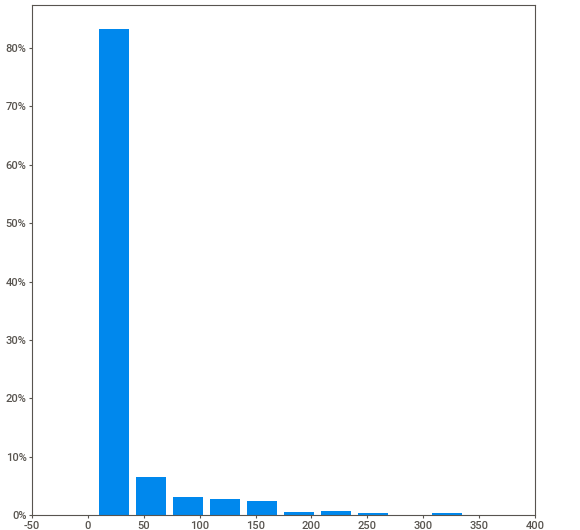
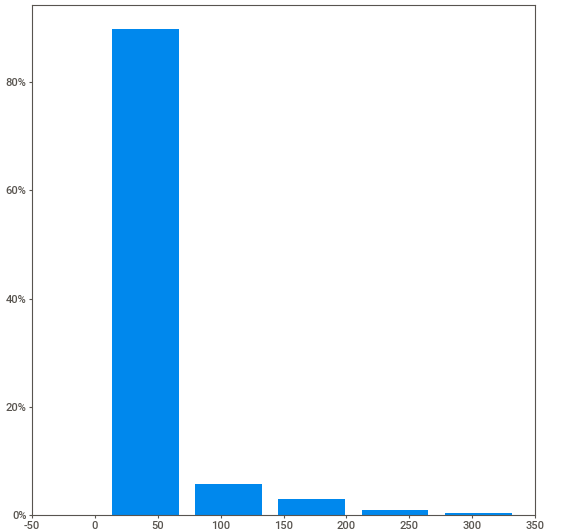
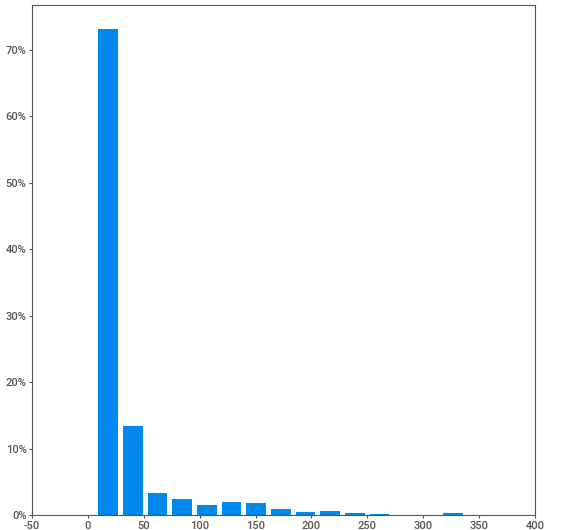
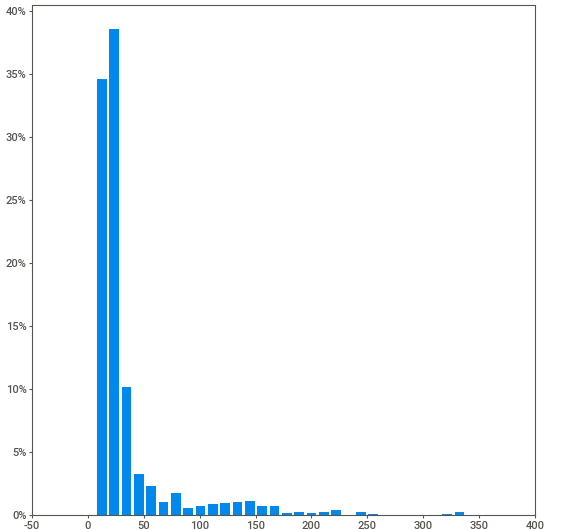
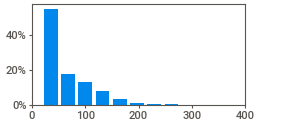
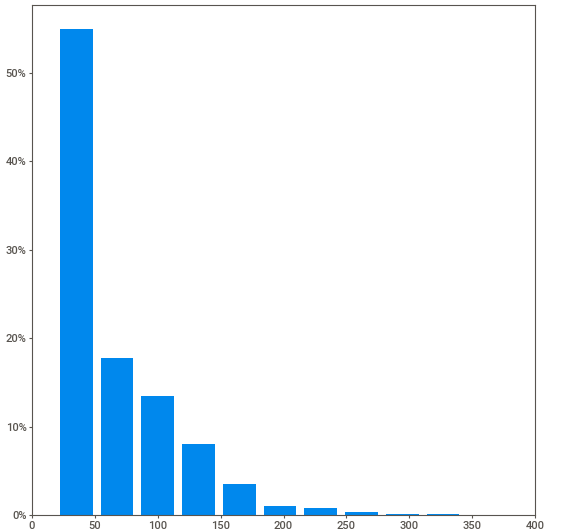
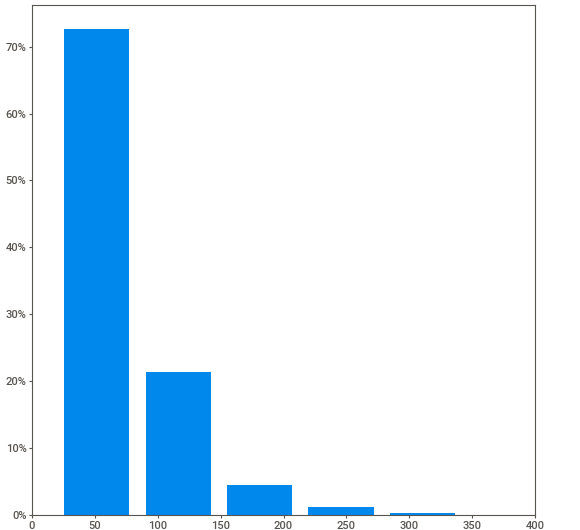
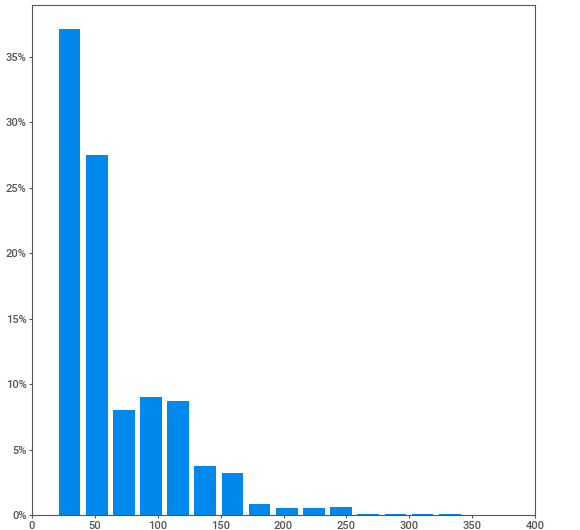
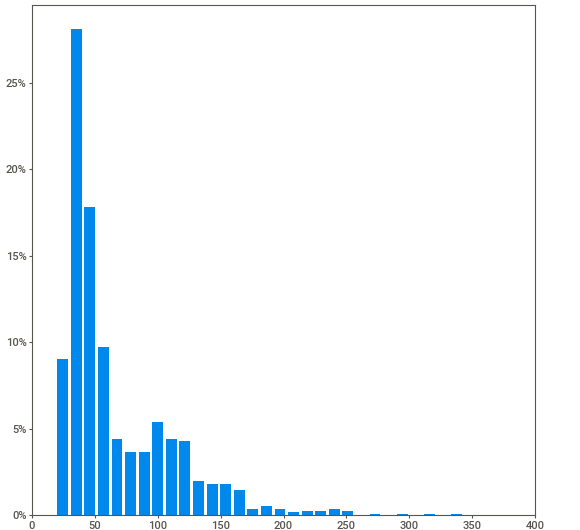
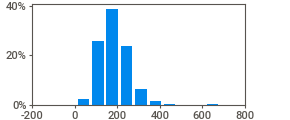
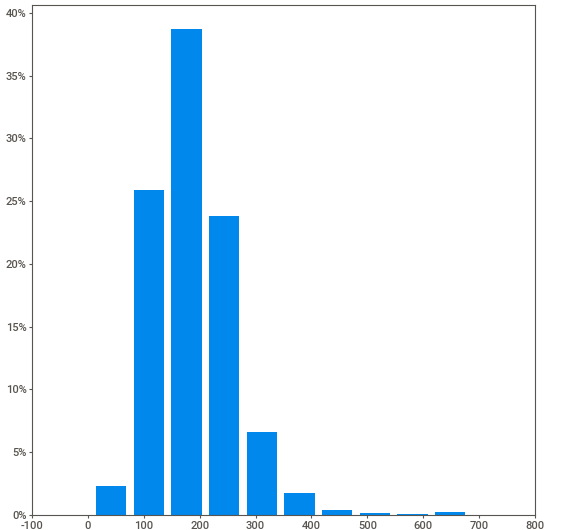
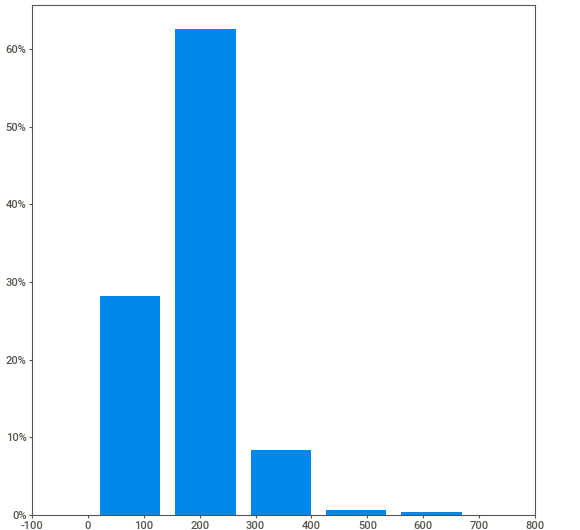
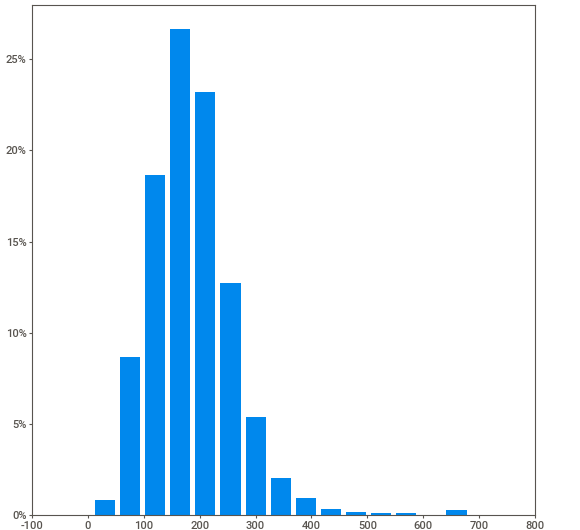
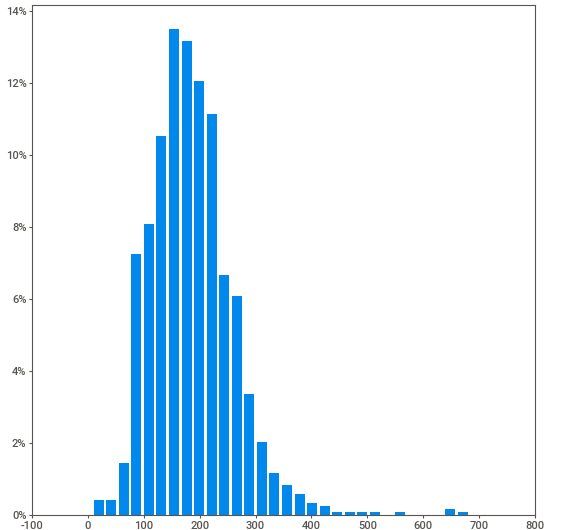
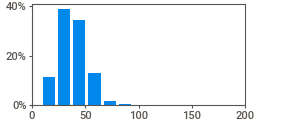
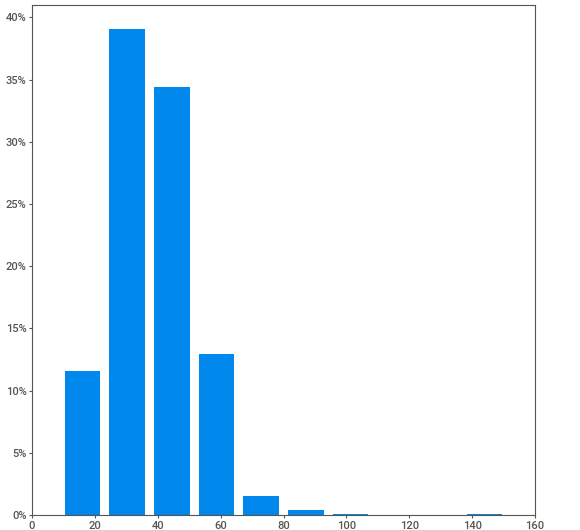
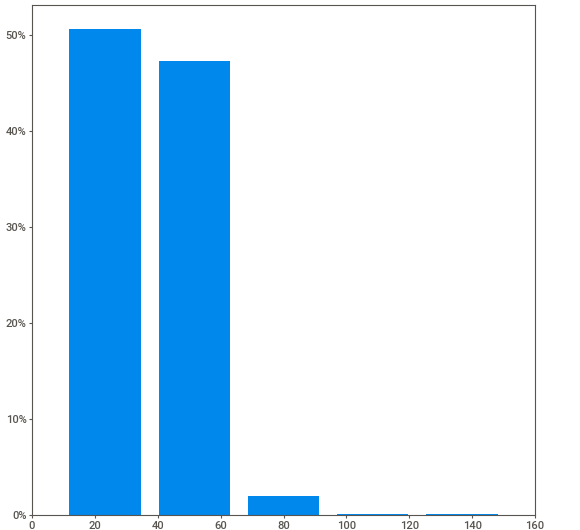
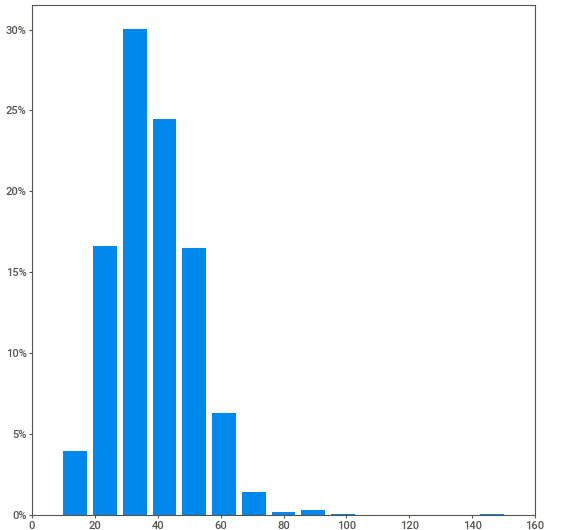
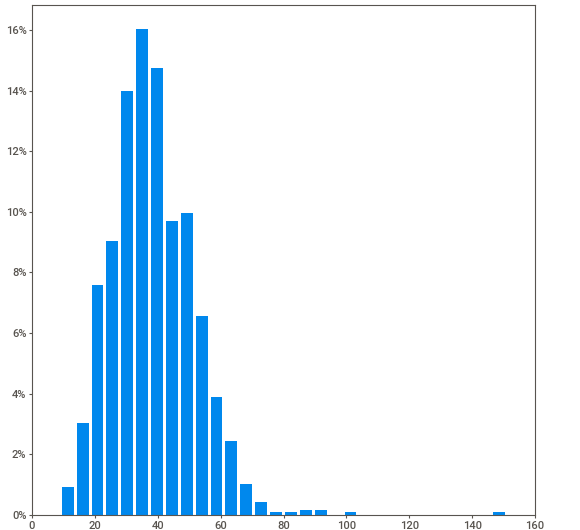
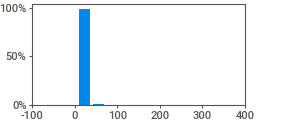
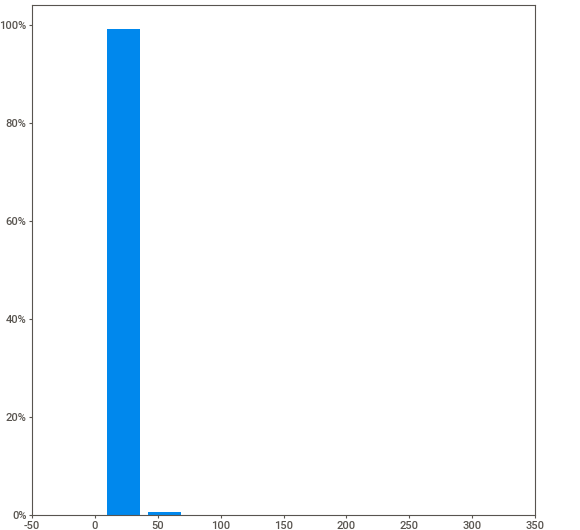
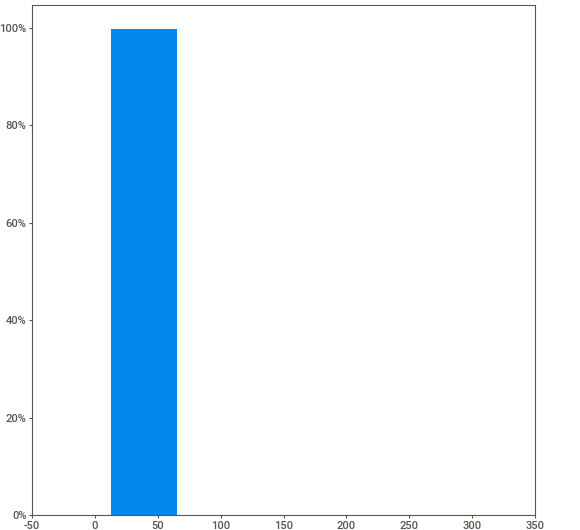
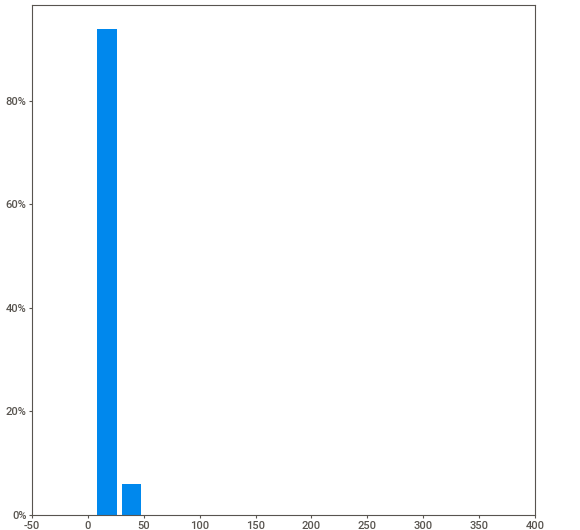
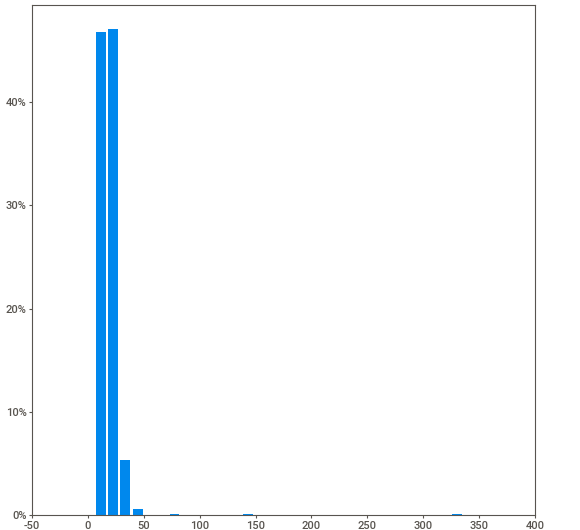
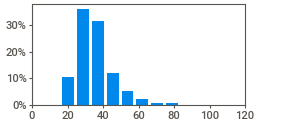
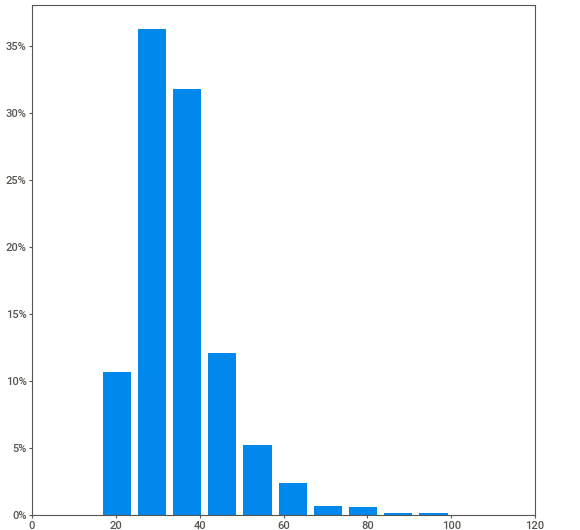
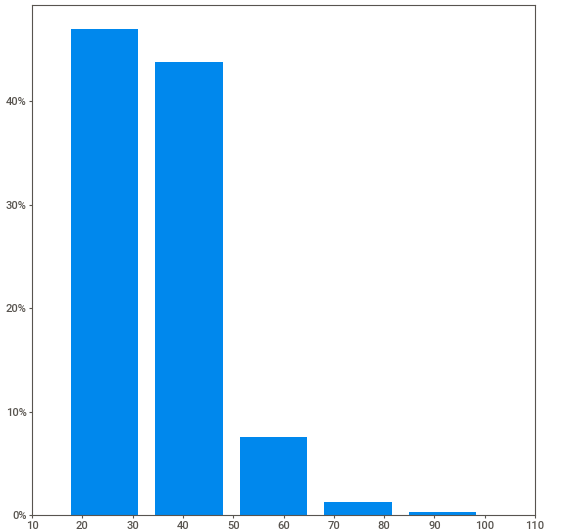
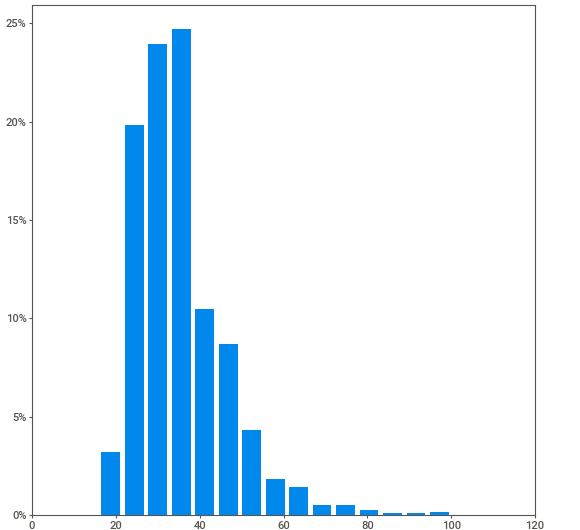
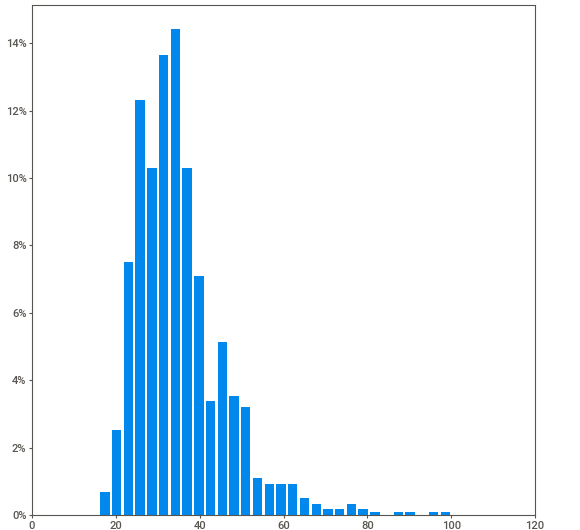
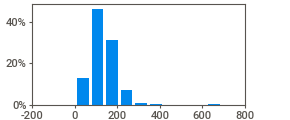
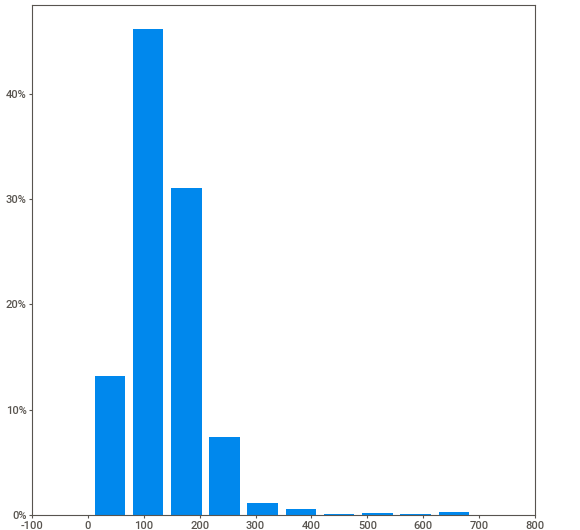
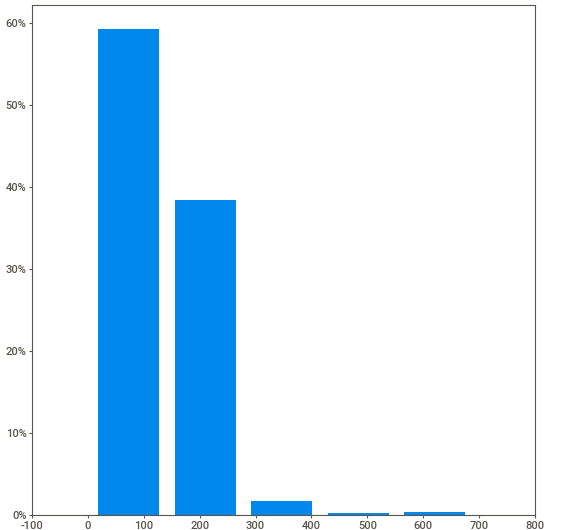
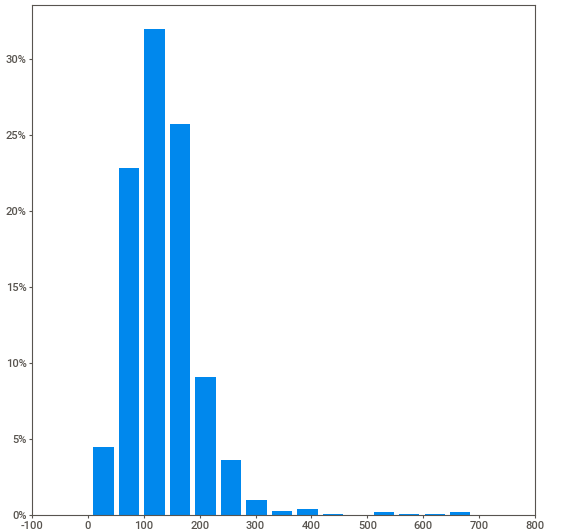
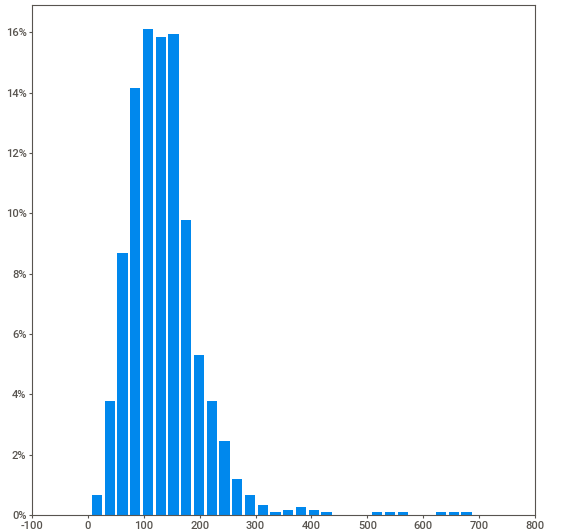
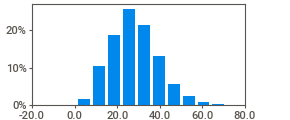
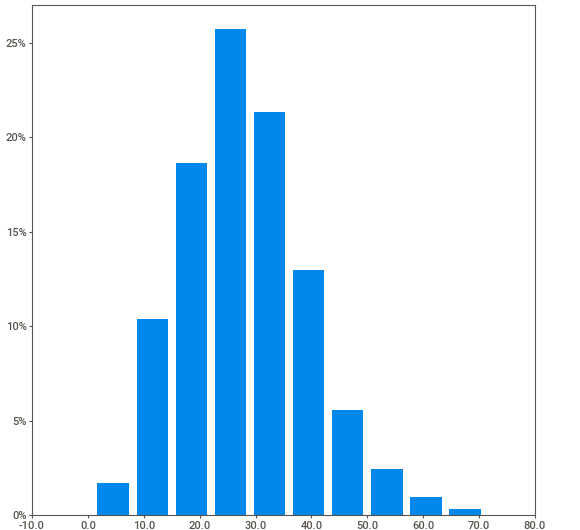
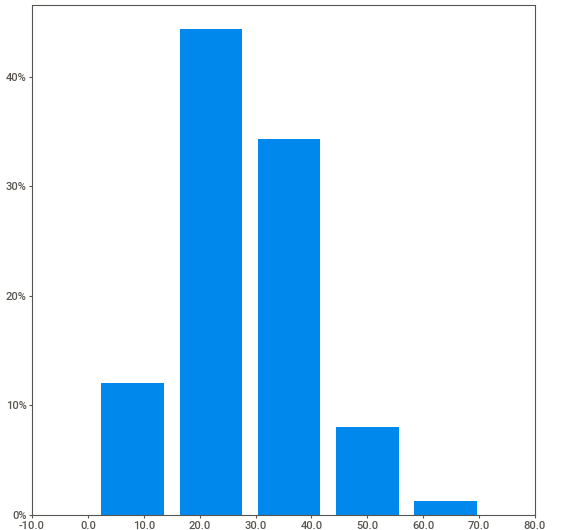
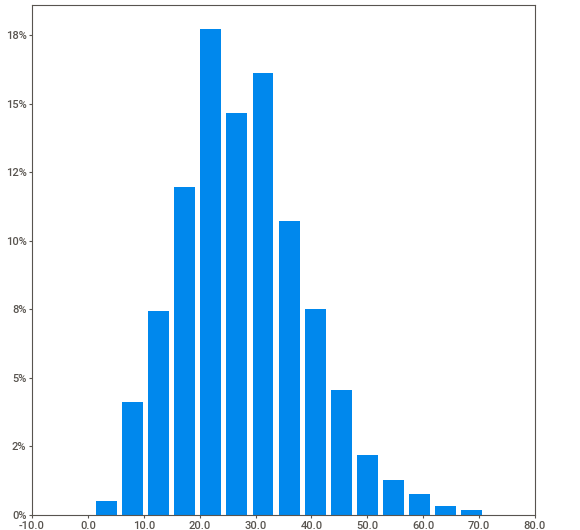
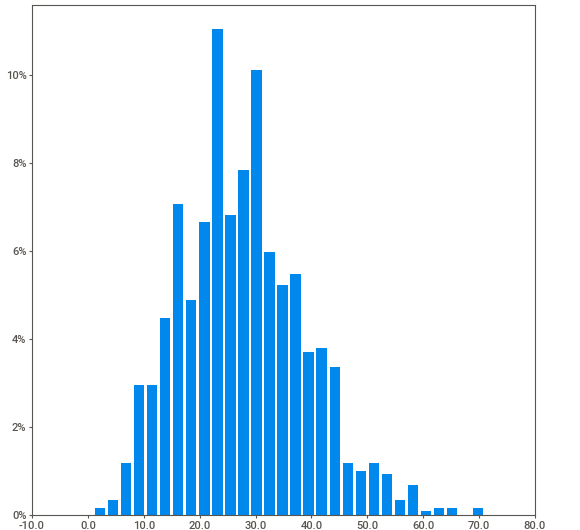
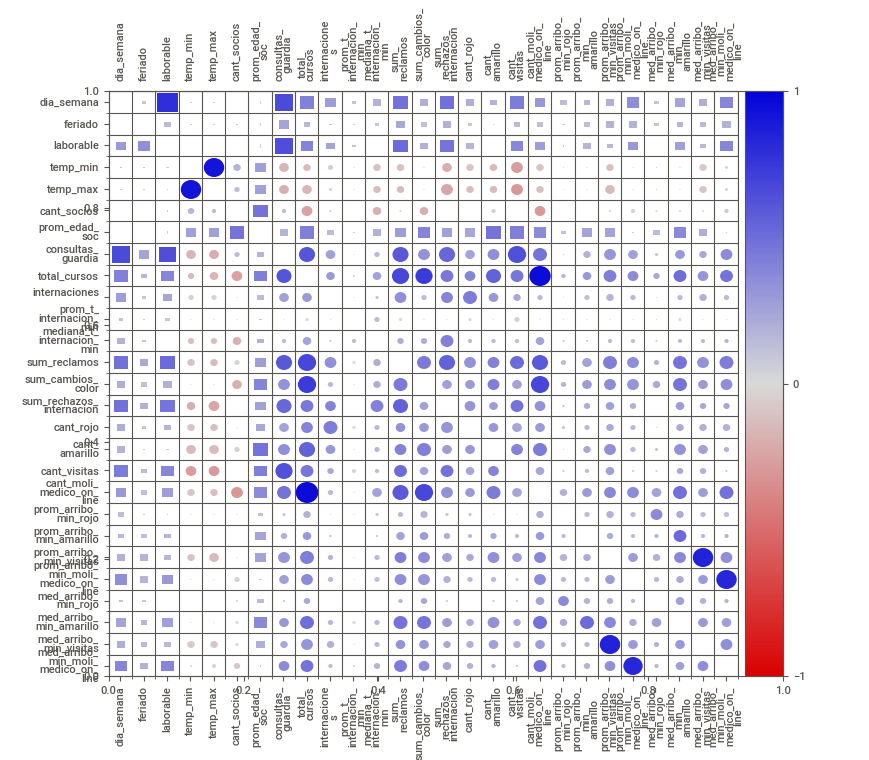
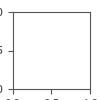

In [ ]:
if not hasattr(np, "VisibleDeprecationWarning"):
    class VisibleDeprecationWarning(Warning):
        pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning
    warnings.simplefilter("ignore", np.VisibleDeprecationWarning)

my_report = sv.analyze(df_pandas)
my_report.show_html()

HTML(filename="SWEETVIZ_REPORT.html")
# Descomentar para usar el resultado en pipeline
# files.download("/content/SWEETVIZ_REPORT.html")

#### AutoViz

[**AutoViz**](https://pypi.org/project/autoviz/) es una librería de Python que automatiza el análisis exploratorio de datos (*EDA*) y la visualización de datasets tabulares. A partir de un archivo o un dataframe, AutoViz genera de manera automática gráficos estadísticos, distribuciones, correlaciones y relaciones entre variables, destacando patrones relevantes y posibles problemas de calidad de datos. Su objetivo es acelerar la comprensión inicial del dataset sin necesidad de escribir múltiples líneas de código para cada gráfico, permitiendo a los analistas y científicos de datos identificar insights, tendencias y anomalías de forma rápida y visual.


In [ ]:
from autoviz.AutoViz_Class import AutoViz_Class

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


In [ ]:
AV = AutoViz_Class()

df_av = AV.AutoViz(
    filename='',
    depVar='consultas_guardia',
    dfte=df_pandas,
    chart_format='png',
    max_rows_analyzed=1500,
    max_cols_analyzed=30,
    verbose=1
)

pdf_path = "/content/reporte_autoviz.pdf"
with PdfPages(pdf_path) as pdf:
    for i in plt.get_fignums():
        fig = plt.figure(i)
        pdf.savefig(fig)

# Descomentar para usar el resultado en pipeline
# files.download(pdf_path)

Shape of your Data Set loaded: (1186, 28)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  24
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  2
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  1
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    27 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Regression problem #####################
To fix these data quality issues 

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
dia,datetime64[ns],0.000000,100,,,Possible date-time colum: transform before modeling step.
dia_semana,int8,0.000000,0,1.000000,7.000000,No issue
feriado,int8,0.000000,0,0.000000,1.000000,No issue
laborable,int8,0.000000,0,0.000000,1.000000,No issue
temp_min,int8,0.000000,2,1.000000,28.000000,No issue
temp_max,int8,0.000000,2,9.000000,37.000000,Column has a high correlation with ['temp_min']. Consider dropping one of them.
cant_socios,int32,0.000000,3,104384.000000,112187.000000,No issue
prom_edad_soc,int8,0.000000,0,36.000000,38.000000,No issue
total_cursos,int16,0.000000,20,51.000000,670.000000,Column has 34 outliers greater than upper bound (286.38) or lower than lower bound(15.38). Cap them or remove them.
internaciones,int8,0.000000,3,6.000000,46.000000,Column has 6 outliers greater than upper bound (44.00) or lower than lower bound(4.00). Cap them or remove them.


Number of All Scatter Plots = 300
All Plots done
Time to run AutoViz = 46 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


#### D-Tale

[**D-Tale**](https://github.com/man-group/dtale) es una librería de Python que proporciona una interfaz web interactiva para explorar y visualizar dataframes de pandas de manera rápida y sencilla. Permite inspeccionar los datos, ordenar, filtrar, buscar, agrupar, editar valores, generar gráficos y estadísticas descriptivas sin necesidad de escribir código adicional para cada operación. Su objetivo es facilitar el análisis exploratorio de datos (EDA) ofreciendo una experiencia visual y dinámica directamente desde notebooks o scripts, acelerando la comprensión y limpieza de los datasets antes de la construcción de modelos de machine learning.

Dado que D-Tale es una herramienta interactiva se genera un link con la interfaz web de la aplicación que no funciona cuando se ejecuta de desde Google Colab.

Probablemente funcione si se ejecutar en un Jupyter lab localmente. Otra para hacerlo funcionar desde Google Clocal es tratar de configurar un proxy tunnel con herramientas como ngrok, como se explica en https://github.com/man-group/dtale?tab=readme-ov-file#kaggle.

In [ ]:
"""
# D-Tale en pop up:
d = dtale.show(df_pandas, ignore_duplicate=True, subprocess=True)
d.open_browser()

# D-Tale en link:
url = d._main_url
print("D-Tale corriendo en:", url)
"""

'\n# D-Tale en pop up:\nd = dtale.show(df_pandas, ignore_duplicate=True, subprocess=True)\nd.open_browser()\n\n# D-Tale en link:\nurl = d._main_url\nprint("D-Tale corriendo en:", url)\n'

#### Dataprep

[**Dataprep**](https://docs.dataprep.ai/user_guide/eda/introduction.html) es una librería de Python diseñada para simplificar y acelerar el proceso de preparación y limpieza de datos para análisis y machine learning. Permite explorar, visualizar y transformar datasets de manera automática y eficiente, identificando valores faltantes, inconsistencias, tipos de datos, distribuciones y relaciones entre variables, así como generando reportes interactivos. Su objetivo es reducir el trabajo manual de *data wrangling* y facilitar la comprensión inicial de los datos, integrándose fácilmente con pandas y otras librerías del ecosistema de ciencia de datos, acelerando la construcción de pipelines de análisis y modelos predictivos.

Al instalar dataprep dejan de funcionar distintas herramientas de la librería pandas y termina no siendo compatible con todo el resto de procesos.

Una opción puede ser configurar un entorno virtual para evitar estos problemas. No se usa porque ya tenemos la salida de otras 3 herramientas de AutoEDA para comparar.

In [ ]:
'''
!pip install dataprep
from dataprep.eda import plot, plot_correlation, plot_missing
plot(df)
plot_correlation(df)
plot_missing(df)
'''

'\n!pip install dataprep\nfrom dataprep.eda import plot, plot_correlation, plot_missing\nplot(df)\nplot_correlation(df)\nplot_missing(df)\n'

## **Auto Feature Engineering - AutoFE**

#### TsFresh

[**TsFresh**](https://tsfresh.readthedocs.io/en/latest/text/introduction.html) es una librería de Python que automatiza la extracción de características de series temporales: a partir de datos secuenciales (sensores, transacciones, señales biomédicas, etc.) genera cientos de descriptores estadísticos, frecuenciales y de correlación (medias, varianzas, autocorrelaciones, FFT, cuantiles, picos, etc.), y luego aplica tests estadísticos para seleccionar solo aquellas características relevantes con respecto a una variable objetivo, facilitando la construcción de modelos de machine learning sin necesidad de diseñar manualmente los *features*.

En el contexto del proyecto, decidimos usarlas porque el dataset es una serie temporal de uso del servicio médico de guardia de la prepaga.

In [ ]:
!pip uninstall -y numpy pandas scipy tsfresh
!pip install -q --no-cache-dir numpy==2.0.2 scipy==1.14.1 pandas==2.2.2 tsfresh==0.21.1

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: tsfresh 0.21.1
Uninstalling tsfresh-0.21.1:
  Successfully uninstalled tsfresh-0.21.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 205.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 209.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 196.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 193.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 201.7 MB/s eta 0:00:00


In [ ]:
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import impute

Las librerías extraerán características del conjunto de datos, por lo que se debe reservar la variable objetivo para no perderla ni correlacionarla artificialmente con la ingeniería de características.

In [ ]:
X = df_pandas.drop('internaciones', axis=1)
y = df_pandas['internaciones']

In [ ]:
X['dia'] = pd.to_datetime(X['dia'])

numeric_cols = X.select_dtypes(include=np.number).columns
X[numeric_cols] = X[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

X = X.reset_index(drop=True)
X['id_diario'] = range(len(X))

df_long = []
numeric_cols_for_tsfresh = [c for c in numeric_cols if c not in ["id_diario"]]
for col in numeric_cols_for_tsfresh:
    tmp = X[['id_diario', 'dia', col]].copy()
    tmp['variable'] = col
    tmp = tmp.rename(
        columns={
            'id_diario': 'id',
            'dia': 'time',
            col: 'value',
            'variable': 'kind',
        }
    )
    df_long.append(tmp)

df_long = pd.concat(df_long)

safe_fc_params = {
    'sum_values': None,
    'mean': None,
    'median': None,
    'standard_deviation': None,
    'variance': None,
    'minimum': None,
    'maximum': None,
    'length': None,
    'absolute_maximum': None,
    'kurtosis': None,
    'skewness': None,
}

In [ ]:
X_tsfresh = extract_features(
    df_long,
    column_id='id',
    column_sort='time',
    column_kind='kind',
    column_value='value',
    default_fc_parameters=safe_fc_params,
    n_jobs=1,
    disable_progressbar=True,
)

X_tsfresh = impute(X_tsfresh)
X_tsfresh.reset_index(inplace=True)
X_tsfresh.rename(columns={'index': 'id_diario'}, inplace=True)
X_tsfresh_final = pd.merge(
    X_tsfresh,
    X[['id_diario', 'dia']],
    on='id_diario',
    how='left',
)

print('\nShape del DataFrame con tsfresh:', X_tsfresh_final.shape)
X_tsfresh_final.head()


Shape del DataFrame con tsfresh: (1186, 288)


,id_diario,cant_amarillo__sum_values,cant_amarillo__mean,cant_amarillo__median,cant_amarillo__standard_deviation,cant_amarillo__variance,cant_amarillo__minimum,cant_amarillo__maximum,cant_amarillo__length,cant_amarillo__absolute_maximum,cant_amarillo__kurtosis,cant_amarillo__skewness,cant_moli_medico_on_line__sum_values,cant_moli_medico_on_line__mean,cant_moli_medico_on_line__median,cant_moli_medico_on_line__standard_deviation,cant_moli_medico_on_line__variance,cant_moli_medico_on_line__minimum,cant_moli_medico_on_line__maximum,cant_moli_medico_on_line__length,cant_moli_medico_on_line__absolute_maximum,cant_moli_medico_on_line__kurtosis,cant_moli_medico_on_line__skewness,cant_rojo__sum_values,cant_rojo__mean,cant_rojo__median,cant_rojo__standard_deviation,cant_rojo__variance,cant_rojo__minimum,cant_rojo__maximum,cant_rojo__length,cant_rojo__absolute_maximum,cant_rojo__kurtosis,cant_rojo__skewness,cant_socios__sum_values,cant_socios__mean,cant_socios__median,cant_socios__standard_deviation,cant_socios__variance,cant_socios__minimum,cant_socios__maximum,cant_socios__length,cant_socios__absolute_maximum,cant_socios__kurtosis,cant_socios__skewness,cant_visitas__sum_values,cant_visitas__mean,cant_visitas__median,cant_visitas__standard_deviation,cant_visitas__variance,cant_visitas__minimum,cant_visitas__maximum,cant_visitas__length,cant_visitas__absolute_maximum,cant_visitas__kurtosis,cant_visitas__skewness,consultas_guardia__sum_values,consultas_guardia__mean,consultas_guardia__median,consultas_guardia__standard_deviation,consultas_guardia__variance,consultas_guardia__minimum,consultas_guardia__maximum,consultas_guardia__length,consultas_guardia__absolute_maximum,consultas_guardia__kurtosis,consultas_guardia__skewness,dia_semana__sum_values,dia_semana__mean,dia_semana__median,dia_semana__standard_deviation,dia_semana__variance,dia_semana__minimum,dia_semana__maximum,dia_semana__length,dia_semana__absolute_maximum,dia_semana__kurtosis,dia_semana__skewness,feriado__sum_values,feriado__mean,feriado__median,feriado__standard_deviation,feriado__variance,feriado__minimum,feriado__maximum,feriado__length,feriado__absolute_maximum,feriado__kurtosis,feriado__skewness,laborable__sum_values,laborable__mean,laborable__median,laborable__standard_deviation,laborable__variance,laborable__minimum,laborable__maximum,laborable__length,laborable__absolute_maximum,laborable__kurtosis,laborable__skewness,med_arribo_min_amarillo__sum_values,med_arribo_min_amarillo__mean,med_arribo_min_amarillo__median,med_arribo_min_amarillo__standard_deviation,med_arribo_min_amarillo__variance,med_arribo_min_amarillo__minimum,med_arribo_min_amarillo__maximum,med_arribo_min_amarillo__length,med_arribo_min_amarillo__absolute_maximum,med_arribo_min_amarillo__kurtosis,med_arribo_min_amarillo__skewness,med_arribo_min_moli_medico_on_line__sum_values,med_arribo_min_moli_medico_on_line__mean,med_arribo_min_moli_medico_on_line__median,med_arribo_min_moli_medico_on_line__standard_deviation,med_arribo_min_moli_medico_on_line__variance,med_arribo_min_moli_medico_on_line__minimum,med_arribo_min_moli_medico_on_line__maximum,med_arribo_min_moli_medico_on_line__length,med_arribo_min_moli_medico_on_line__absolute_maximum,med_arribo_min_moli_medico_on_line__kurtosis,med_arribo_min_moli_medico_on_line__skewness,med_arribo_min_rojo__sum_values,med_arribo_min_rojo__mean,med_arribo_min_rojo__median,med_arribo_min_rojo__standard_deviation,med_arribo_min_rojo__variance,med_arribo_min_rojo__minimum,med_arribo_min_rojo__maximum,med_arribo_min_rojo__length,med_arribo_min_rojo__absolute_maximum,med_arribo_min_rojo__kurtosis,med_arribo_min_rojo__skewness,med_arribo_min_visitas__sum_values,med_arribo_min_visitas__mean,med_arribo_min_visitas__median,med_arribo_min_visitas__standard_deviation,med_arribo_min_visitas__variance,med_arribo_min_visitas__minimum,med_arribo_min_visitas__maximum,med_arribo_min_visitas__length,med_arribo_min_visitas__absolute_maximum,med_arribo_min_visitas__kurtosis,med_arrib

#### Featuretools

[**Featuretools**](https://featuretools.alteryx.com/en/stable/) es una librería de Python especializada en *feature engineering automático* (*automated feature engineering*), cuyo enfoque principal es la técnica de **Deep Feature Synthesis (DFS)**: a partir de uno o varios dataframes relacionados (tablas con claves primarias y foráneas), genera automáticamente nuevas variables combinando y transformando las existentes mediante operaciones matemáticas, agregaciones y transformaciones temporales. Esto permite crear representaciones ricas de los datos (por ejemplo, número promedio de compras por cliente, tiempo desde la última transacción, proporción de ítems repetidos, etc.) de forma sistemática y escalable, acelerando la preparación de conjuntos de datos para machine learning sin depender del trabajo manual del analista.

In [ ]:
!pip install -q --no-cache-dir featuretools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 330.3 MB/s eta 0:00:00


In [ ]:
import featuretools as ft

In [ ]:
df_ft_input = X_tsfresh_final.copy()
df_ft_input.rename(columns={'dia': 'time_index'}, inplace=True)

numeric_cols = df_ft_input.select_dtypes(include=np.number).columns
df_ft_input[numeric_cols] = df_ft_input[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

es = ft.EntitySet(id="mi_proyecto")
es = es.add_dataframe(
    dataframe_name="features_tsfresh",
    dataframe=df_ft_input,
    index="id_diario",
    time_index="time_index"
)

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="features_tsfresh",
    agg_primitives=["sum", "mean", "min", "max", "std"],
    trans_primitives=["cum_mean", "cum_sum"],
    max_depth=1
)

print("\nShape de la matriz de features con featuretools:", feature_matrix.shape)
feature_matrix.head()


Shape de la matriz de features con featuretools: (1186, 858)


,cant_amarillo__sum_values,cant_amarillo__mean,cant_amarillo__median,cant_amarillo__standard_deviation,cant_amarillo__variance,cant_amarillo__minimum,cant_amarillo__maximum,cant_amarillo__length,cant_amarillo__absolute_maximum,cant_amarillo__kurtosis,cant_amarillo__skewness,cant_moli_medico_on_line__sum_values,cant_moli_medico_on_line__mean,cant_moli_medico_on_line__median,cant_moli_medico_on_line__standard_deviation,cant_moli_medico_on_line__variance,cant_moli_medico_on_line__minimum,cant_moli_medico_on_line__maximum,cant_moli_medico_on_line__length,cant_moli_medico_on_line__absolute_maximum,cant_moli_medico_on_line__kurtosis,cant_moli_medico_on_line__skewness,cant_rojo__sum_values,cant_rojo__mean,cant_rojo__median,cant_rojo__standard_deviation,cant_rojo__variance,cant_rojo__minimum,cant_rojo__maximum,cant_rojo__length,cant_rojo__absolute_maximum,cant_rojo__kurtosis,cant_rojo__skewness,cant_socios__sum_values,cant_socios__mean,cant_socios__median,cant_socios__standard_deviation,cant_socios__variance,cant_socios__minimum,cant_socios__maximum,cant_socios__length,cant_socios__absolute_maximum,cant_socios__kurtosis,cant_socios__skewness,cant_visitas__sum_values,cant_visitas__mean,cant_visitas__median,cant_visitas__standard_deviation,cant_visitas__variance,cant_visitas__minimum,cant_visitas__maximum,cant_visitas__length,cant_visitas__absolute_maximum,cant_visitas__kurtosis,cant_visitas__skewness,consultas_guardia__sum_values,consultas_guardia__mean,consultas_guardia__median,consultas_guardia__standard_deviation,consultas_guardia__variance,consultas_guardia__minimum,consultas_guardia__maximum,consultas_guardia__length,consultas_guardia__absolute_maximum,consultas_guardia__kurtosis,consultas_guardia__skewness,dia_semana__sum_values,dia_semana__mean,dia_semana__median,dia_semana__standard_deviation,dia_semana__variance,dia_semana__minimum,dia_semana__maximum,dia_semana__length,dia_semana__absolute_maximum,dia_semana__kurtosis,dia_semana__skewness,feriado__sum_values,feriado__mean,feriado__median,feriado__standard_deviation,feriado__variance,feriado__minimum,feriado__maximum,feriado__length,feriado__absolute_maximum,feriado__kurtosis,feriado__skewness,laborable__sum_values,laborable__mean,laborable__median,laborable__standard_deviation,laborable__variance,laborable__minimum,laborable__maximum,laborable__length,laborable__absolute_maximum,laborable__kurtosis,laborable__skewness,med_arribo_min_amarillo__sum_values,med_arribo_min_amarillo__mean,med_arribo_min_amarillo__median,med_arribo_min_amarillo__standard_deviation,med_arribo_min_amarillo__variance,med_arribo_min_amarillo__minimum,med_arribo_min_amarillo__maximum,med_arribo_min_amarillo__length,med_arribo_min_amarillo__absolute_maximum,med_arribo_min_amarillo__kurtosis,med_arribo_min_amarillo__skewness,med_arribo_min_moli_medico_on_line__sum_values,med_arribo_min_moli_medico_on_line__mean,med_arribo_min_moli_medico_on_line__median,med_arribo_min_moli_medico_on_line__standard_deviation,med_arribo_min_moli_medico_on_line__variance,med_arribo_min_moli_medico_on_line__minimum,med_arribo_min_moli_medico_on_line__maximum,med_arribo_min_moli_medico_on_line__length,med_arribo_min_moli_medico_on_line__absolute_maximum,med_arribo_min_moli_medico_on_line__kurtosis,med_arribo_min_moli_medico_on_line__skewness,med_arribo_min_rojo__sum_values,med_arribo_min_rojo__mean,med_arribo_min_rojo__median,med_arribo_min_rojo__standard_deviation,med_arribo_min_rojo__variance,med_arribo_min_rojo__minimum,med_arribo_min_rojo__maximum,med_arribo_min_rojo__length,med_arribo_min_rojo__absolute_maximum,med_arribo_min_rojo__kurtosis,med_arribo_min_rojo__skewness,med_arribo_min_visitas__sum_values,med_arribo_min_visitas__mean,med_arribo_min_visitas__median,med_arribo_min_visitas__standard_deviation,med_arribo_min_visitas__variance,med_arribo_min_visitas__minimum,med_arribo_min_visitas__maximum,med_arribo_min_visitas__length,med_arribo_min_visitas__absolute_maximum,med_arribo_min_visitas__kurtosis,med_arribo_min_visi

#### AutoFeat

[**AutoFeat**](https://autofeat.readthedocs.io/en/latest/) es una librería de Python para *feature engineering automático* en datasets tabulares. Su objetivo es generar nuevas variables a partir de las existentes aplicando combinaciones matemáticas básicas (suma, resta, multiplicación, división, logaritmos, raíces cuadradas, etc.) y luego seleccionar automáticamente las más relevantes para predecir una variable objetivo. De esta manera, AutoFeat amplía el espacio de features sin intervención manual y permite mejorar modelos de machine learning de manera rápida, especialmente en problemas de regresión o clasificación con datos estructurados.

In [ ]:
!pip uninstall -y numpy pandas
!pip install -q --no-cache-dir numpy==2.0.2 pandas==2.2.2 autofeat

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.5/305.5 kB 76.2 MB/s eta 0:00:00


In [ ]:
from autofeat import FeatureSelector

In [ ]:
X_final = pd.merge(
    X,
    feature_matrix,
    on='id_diario',
    how='left',
    suffixes=('', '_ft')
)

X_final_features = X_final.drop(columns=['consultas_guardia', 'id_diario'], errors='ignore')

fecha_corte = pd.to_datetime('2025-03-01')
idx_train = X_final_features['dia'] < fecha_corte
idx_test = X_final_features['dia'] >= fecha_corte

X_train = X_final_features[idx_train]
X_test = X_final_features[idx_test]
y_train = y[idx_train]
y_test = y[idx_test]

print("\nShape del DataFrame de características final (X_final_features):", X_final_features.shape)
print("------------------------------------")
print(f"\nTamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print("------------------------------------")
print(f"\nTamaño de la variable objetivo de entrenamiento (y_train): {y_train.shape}")
print(f"Tamaño de la variable objetivo de prueba (y_test): {y_test.shape}")


Shape del DataFrame de características final (X_final_features): (1186, 884)
------------------------------------

Tamaño del conjunto de entrenamiento (X_train): (1155, 884)
Tamaño del conjunto de prueba (X_test): (31, 884)
------------------------------------

Tamaño de la variable objetivo de entrenamiento (y_train): (1155,)
Tamaño de la variable objetivo de prueba (y_test): (31,)


In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train_numeric = X_train.drop(columns=['dia'], errors='ignore')
X_test_numeric = X_test.drop(columns=['dia'], errors='ignore')

numeric_cols = X_train_numeric.select_dtypes(include=np.number).columns
X_train_clean = X_train_numeric[numeric_cols].copy()
X_test_clean = X_test_numeric[numeric_cols].copy()
X_train_clean = X_train_clean.replace([np.inf, -np.inf], np.nan)
X_test_clean = X_test_clean.replace([np.inf, -np.inf], np.nan)

print(f"NaNs después de reemplazar infinitos - Train: {X_train_clean.isnull().sum().sum()}")
print("------------------------------------")

variance_threshold = VarianceThreshold(threshold=1e-8)  # Muy pequeño umbral
X_train_variance = variance_threshold.fit_transform(X_train_clean.fillna(0))

feature_mask = variance_threshold.get_support()
selected_columns = X_train_clean.columns[feature_mask]

print(f"\nCaracterísticas eliminadas por baja varianza: {len(X_train_clean.columns) - len(selected_columns)}")
print(f"Características restantes: {len(selected_columns)}")
print("------------------------------------")

X_train_clean = X_train_clean[selected_columns]
X_test_clean = X_test_clean[selected_columns]

# Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_clean)
X_test_imputed = imputer.transform(X_test_clean)

print(f"\nNaNs después de imputación - Train: {np.isnan(X_train_imputed).sum()}")
print(f"NaNs después de imputación - Test: {np.isnan(X_test_imputed).sum()}")
print("------------------------------------")
print(f"\nInfinitos después de imputación - Train: {np.isinf(X_train_imputed).sum()}")
print(f"Infinitos después de imputación - Test: {np.isinf(X_test_imputed).sum()}")
print("------------------------------------")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"\nFinal - Train shape: {X_train_scaled.shape}")
print(f"Final - Test shape: {X_test_scaled.shape}")
print(f"Rango de valores en train: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")

NaNs después de reemplazar infinitos - Train: 0
------------------------------------

Características eliminadas por baja varianza: 364
Características restantes: 519
------------------------------------

NaNs después de imputación - Train: 0
NaNs después de imputación - Test: 0
------------------------------------

Infinitos después de imputación - Train: 0
Infinitos después de imputación - Test: 0
------------------------------------

Final - Train shape: (1155, 519)
Final - Test shape: (31, 519)
Rango de valores en train: [-21.576, 30.565]


In [ ]:
fs = FeatureSelector(
    problem_type='regression',
    featsel_runs=3,  # Reducido para ser más rápido
    verbose=1,
    n_jobs=1
)

try:
    X_train_selected = fs.fit_transform(X_train_scaled, y_train.values)
    X_test_selected = fs.transform(X_test_scaled)
    print("✓ Selección de features completada exitosamente!")
except Exception as e:
    print(f"Error con datos escalados: {e}")
    print("Intentando con datos solo imputados (sin escalar)...")
    try:
        fs = FeatureSelector(
            problem_type='regression',
            featsel_runs=2,
            verbose=1,
            n_jobs=1
        )
        X_train_selected = fs.fit_transform(X_train_imputed, y_train.values)
        X_test_selected = fs.transform(X_test_imputed)
        print("✓ Selección completada con datos imputados!")
    except Exception as e2:
        print(f"Error persistente: {e2}")
        print("Usando selección de features alternativa con SelectKBest...")

        k_features = min(50, X_train_imputed.shape[1])
        selector = SelectKBest(score_func=f_regression, k=k_features)
        X_train_selected = selector.fit_transform(X_train_imputed, y_train.values)
        X_test_selected = selector.transform(X_test_imputed)

        class MockFeatureSelector:
            def __init__(self, selector, selected_columns, k):
                self.selector = selector
                self.good_cols_ = selected_columns[selector.get_support()][:k]
                self.score_ = np.mean(selector.scores_[selector.get_support()][:k])

        fs = MockFeatureSelector(selector, selected_columns, k_features)
        print(f"✓ Selección alternativa completada con {k_features} features!")

print("------------------------------------")
print(f"\nFeatures después de limpieza: {len(selected_columns)}")
print(f"Features seleccionadas por autofeat: {X_train_selected.shape[1]}")
reduction = ((len(selected_columns) - X_train_selected.shape[1]) / len(selected_columns) * 100)
print(f"Reducción adicional: {reduction:.1f}%")

total_reduction = ((X_train_numeric.shape[1] - X_train_selected.shape[1]) / X_train_numeric.shape[1] * 100)
print(f"Reducción total: {total_reduction:.1f}%")
print("------------------------------------")

if hasattr(fs, 'good_cols_') and len(fs.good_cols_) > 0:
    selected_feature_names = [f"feat_{i}_{name}" for i, name in enumerate(fs.good_cols_)]
else:
    selected_feature_names = [f"selected_feature_{i}" for i in range(X_train_selected.shape[1])]

if len(selected_feature_names) > X_train_selected.shape[1]:
    selected_feature_names = selected_feature_names[:X_train_selected.shape[1]]
elif len(selected_feature_names) < X_train_selected.shape[1]:
    additional_names = [f"feature_{i}" for i in range(len(selected_feature_names), X_train_selected.shape[1])]
    selected_feature_names.extend(additional_names)

X_train_selected_df = pd.DataFrame(
    X_train_selected,
    columns=selected_feature_names,
    index=X_train.index
)

X_test_selected_df = pd.DataFrame(
    X_test_selected,
    columns=selected_feature_names,
    index=X_test.index
)

X_train_selected_df['dia'] = X_train['dia'].values
X_test_selected_df['dia'] = X_test['dia'].values

print(f"\nX_train_selected_df shape: {X_train_selected_df.shape}")
print(f"X_test_selected_df shape: {X_test_selected_df.shape}")
print("------------------------------------")

if hasattr(fs, 'score_'):
    print(f"Score del modelo selector: {fs.score_:.4f}")

[featsel] Scaling data...done.
[featsel] Feature selection run 1/3
Error con datos escalados: overflow encountered in divide
Intentando con datos solo imputados (sin escalar)...
[featsel] Scaling data...done.
[featsel] Feature selection run 1/2
Error persistente: overflow encountered in divide
Usando selección de features alternativa con SelectKBest...
✓ Selección alternativa completada con 50 features!
------------------------------------

Features después de limpieza: 519
Features seleccionadas por autofeat: 50
Reducción adicional: 90.4%
Reducción total: 94.3%
------------------------------------

X_train_selected_df shape: (1155, 51)
X_test_selected_df shape: (31, 51)
------------------------------------
Score del modelo selector: 109.0167


In [ ]:
print(f"\nConjunto final:")
print(f"Features numéricas (train): {X_train_selected_df.select_dtypes(include=np.number).shape[1]}")
print(f"Memoria aproximada (MB): {X_train_selected_df.memory_usage(deep=True).sum() / 1024**2:.2f}")
print("------------------------------------")

print("\nFeatures originales seleccionadas en Train y Test:")
original_feature_names = []
try:
    for short_name in fs.good_cols_:
        if short_name.startswith('x') and short_name[1:].isdigit():
            index = int(short_name[1:])
            if index < len(selected_columns):
                original_name = selected_columns[index]
                original_feature_names.append(original_name)
            else:
                original_feature_names.append(f"[índice fuera de rango: {short_name}]")
        else:
            original_feature_names.append(short_name)
except Exception as e:
    print(f"Error recuperando nombres originales: {e}")


n_train_cols = X_train_selected_df.shape[1]
if len(original_feature_names) < n_train_cols:
    for i in range(len(original_feature_names), n_train_cols):
        col_name = X_train_selected_df.columns[i]
        if col_name.lower() == "dia":
            original_feature_names.append("dia")
        else:
            original_feature_names.append(f"[col_extra_{i}]")
elif len(original_feature_names) > n_train_cols:
    original_feature_names = original_feature_names[:n_train_cols]

X_train_selected_df_renamed = X_train_selected_df.copy()
X_train_selected_df_renamed.columns = original_feature_names
X_test_selected_df_renamed = X_test_selected_df.copy()
X_test_selected_df_renamed = X_test_selected_df_renamed.iloc[:, :n_train_cols]
X_test_selected_df_renamed.columns = original_feature_names

X_train = X_train_selected_df_renamed.copy()
X_test  = X_test_selected_df_renamed.copy()

table = []
for i, (train_col, test_col) in enumerate(zip(X_train.columns, X_test.columns), start=1):
    table.append([i, train_col, test_col])
print(tabulate(table, headers=["#", "Train", "Test"], tablefmt="grid"))
print("------------------------------------")

print(f"\nCaracterísticas de los datasets finales:")
print(f"• Registros de entrenamiento: {X_train.shape[0]}")
print(f"• Registros de prueba: {X_test.shape[0]}")
print(f"• Features seleccionadas: {X_train.shape[1] - 1}")
print(f"• Período de entrenamiento: {X_train['dia'].min()} a {X_train['dia'].max()}")
print(f"• Período de prueba: {X_test['dia'].min()} a {X_test['dia'].max()}")

features_info = {
    'selected_features': list(X_train.columns),
    'target_variable': 'consultas_guardia',
    'date_column': 'dia',
    'train_period': f"{X_train['dia'].min()} a {X_train['dia'].max()}",
    'test_period': f"{X_test['dia'].min()} a {X_test['dia'].max()}",
    'reduction_percentage': 99.2
}

print(f"\nInformación guardada en 'features_info' para referencia:")
for key, value in features_info.items():
    print(f"  {key}: {value}")


Conjunto final:
Features numéricas (train): 50
Memoria aproximada (MB): 0.46
------------------------------------

Features originales seleccionadas en Train y Test:
+-----+--------------------------------------------+--------------------------------------------+
|   # | Train                                      | Test                                       |
+=====+============================================+============================================+
|   1 | laborable                                  | laborable                                  |
+-----+--------------------------------------------+--------------------------------------------+
|   2 | total_cursos                               | total_cursos                               |
+-----+--------------------------------------------+--------------------------------------------+
|   3 | sum_reclamos                               | sum_reclamos                               |
+-----+------------------------------------------

In [ ]:
def mostrar_tabla(df, titulo, nombre_columna='Variable'):
    columnas_numericas = df.select_dtypes(include='number').columns
    estilos = [
        {"selector": "caption", "props": [("caption-side", "top"),
                                          ("text-align", "left"),
                                          ("font-size", "14px"),
                                          ("font-family", "Arial"),
                                          ("font-weight", "normal")]},
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-family", "Arial"),
                                     ("font-size", "11pt")]},
        {"selector": "td", "props": [("text-align", "center"),
                                     ("font-family", "Arial"),
                                     ("font-size", "11pt")]}
    ]
    styled = df.style \
        .format("{:,.3f}") \
        .set_table_styles(estilos) \
        .set_caption(titulo) \
        .set_properties(**{"text-align": "center",
                           "font-family": "Arial",
                           "font-size": "11pt"})
    return styled


selected_numeric_cols = X_train.select_dtypes(include="number").columns
desc = X_train[selected_numeric_cols].describe().T.round(3)

titulo = "<b>Tabla 1</b><br><i>Estadísticas descriptivas de las variables numéricas seleccionadas</i>"
styled = mostrar_tabla(desc, titulo)
zebra = [{'selector': 'tbody tr:nth-child(even)',
          'props': [('background-color', '#f6f6f6')]}]
styled = styled.set_table_styles(zebra, overwrite=False)
html = styled.to_html()
out_file = "tabla_desc.html"
with open(out_file, "w", encoding="utf-8") as f:
    f.write(html)

HTML(filename="tabla_desc.html")
# Descomentar para implementar en el pipeline
# files.download(out_file)

,count,mean,std,min,25%,50%,75%,max
laborable,"1,155.000",0.677,0.468,0.000,0.000,1.000,1.000,1.000
total_cursos,"1,155.000",159.164,67.286,51.000,117.000,149.000,185.000,670.000
sum_reclamos,"1,155.000",13.175,8.609,0.000,7.000,11.000,18.000,57.000
sum_rechazos_internacion,"1,155.000",32.505,33.168,0.000,8.000,21.000,48.500,217.000
cant_rojo,"1,155.000",10.501,3.732,1.000,8.000,10.000,13.000,26.000
cant_amarillo,"1,155.000",20.538,6.035,3.000,16.000,20.000,24.000,44.000
cant_amarillo__sum_values,"1,155.000",20.538,6.035,3.000,16.000,20.000,24.000,44.000
cant_amarillo__mean,"1,155.000",20.538,6.035,3.000,16.000,20.000,24.000,44.000
cant_amarillo__median,"1,155.000",20.538,6.035,3.000,16.000,20.000,24.000,44.000
cant_amarillo__minimum,"1,155.000",20.538,6.035,3.000,16.000,20.000,24.000,44.000


In [ ]:
# Fecha de corte para test: 2025-03-01
# Resetear índices para evitar problemas
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Unir X e y de train y test
train_full = pd.concat([X_train, y_train], axis=1)
test_full  = pd.concat([X_test, y_test], axis=1)

# Concatenar todo en un solo dataset
df_master = pd.concat([train_full, test_full], axis=0).reset_index(drop=True)

# Ordenar por la columna 'dia' (si es fecha)
df_master = df_master.sort_values("dia").reset_index(drop=True)

## **Modelado - Auto ML**

#### H2O

[**H2O AutoML**](https://h2o.ai/platform/h2o-automl/) es una plataforma de *AutoML* desarrollada por H2O.ai que automatiza el entrenamiento, ajuste y evaluación de modelos de machine learning en datasets tabulares. A partir de un conjunto de datos y una variable objetivo, H2O AutoML prueba de manera sistemática múltiples algoritmos (como gradient boosting, random forests, GLM, deep learning) y combina modelos en *ensembles* automáticos, optimizando hiperparámetros y seleccionando automáticamente las mejores configuraciones según métricas de desempeño. Su enfoque permite a usuarios acelerar el desarrollo de modelos predictivos sin necesidad de ajustar manualmente cada algoritmo, garantizando resultados competitivos y fácilmente reproducibles.

In [ ]:
!pip install -q h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 MB 3.4 MB/s eta 0:00:00


In [ ]:
import h2o
from h2o.automl import H2OAutoML

In [ ]:
h2o.init()

train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
test_h2o = h2o.H2OFrame(pd.concat([X_test, y_test], axis=1))

target = y_train.name
features = X_train.columns.tolist()

aml = H2OAutoML(max_models=15, seed=42, max_runtime_secs=600)
aml.train(x=features, y=target, training_frame=train_h2o)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.28" 2025-07-15; OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp6v9pdu6k
  JVM stdout: /tmp/tmp6v9pdu6k/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp6v9pdu6k/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,09 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,6 months and 6 days
H2O_cluster_name:,H2O_from_python_unknownUser_71hfe8
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),9/15
# GBM base models (used / total),5/6
# XGBoost base models (used / total),2/5
# GLM base models (used / total),1/1
# DRF base models (used / total),0/2
# DeepLearning base models (used / total),1/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5


In [ ]:
lb = aml.leaderboard
lb_pd = lb.as_data_frame()
print("Ranking de Modelos (Leaderboard):")
print(tabulate(lb_pd, headers='keys', tablefmt='psql'))

best_model = aml.leader
perf_test = best_model.model_performance(test_h2o)
print("\n------------------------------------\n")

metricas_df_h2o = pd.DataFrame({
    'Métrica': [
        'MSE',
        'RMSE',
        'MAE',
        'R² (R-squared)',
        'Desviación Residual Media'
    ],
    'Valor (Test Set)': [
        perf_test.mse(),
        perf_test.rmse(),
        perf_test.mae(),
        perf_test.r2(),
        perf_test.mean_residual_deviance()
    ]
})


def format_metric(row):
    metric = row['Métrica']
    valor = row['Valor (Test Set)']
    if metric == 'R² (R-squared)':
        return f"{valor:,.4f}"
    else:
        return f"{valor:,.2f}"

metricas_df_h2o['Valor (Test Set)'] = metricas_df_h2o.apply(format_metric, axis=1)
tabla_md = metricas_df_h2o.to_markdown(index=False)
display(Markdown(f"**Tabla 3**  \n*Métricas en el Test Set del mejor modelo seleccionado por H2O AutoML*\n\n{tabla_md}"))
print("\n------------------------------------\n")

preds = best_model.predict(test_h2o)
preds_pd = preds.as_data_frame()

Ranking de Modelos (Leaderboard):
+----+---------------------------------------------------------+---------+---------+---------+----------+--------------------------+
|    | model_id                                                |    rmse |     mse |     mae |    rmsle |   mean_residual_deviance |
|----+---------------------------------------------------------+---------+---------+---------+----------+--------------------------|
|  0 | StackedEnsemble_AllModels_1_AutoML_1_20251003_220300    | 6.02613 | 36.3142 | 4.83479 | 0.253478 |                  36.3142 |
|  1 | StackedEnsemble_BestOfFamily_1_AutoML_1_20251003_220300 | 6.05249 | 36.6326 | 4.83345 | 0.254503 |                  36.6326 |
|  2 | GBM_1_AutoML_1_20251003_220300                          | 6.10035 | 37.2143 | 4.87503 | 0.256894 |                  37.2143 |
|  3 | GBM_3_AutoML_1_20251003_220300                          | 6.13803 | 37.6754 | 4.90574 | 0.257818 |                  37.6754 |
|  4 | GLM_1_AutoML_1_20251003_2203

**Tabla 3**  
*Métricas en el Test Set del mejor modelo seleccionado por H2O AutoML*

| Métrica                   |   Valor (Test Set) |
|:--------------------------|-------------------:|
| MSE                       |            40.56   |
| RMSE                      |             6.37   |
| MAE                       |             5.38   |
| R² (R-squared)            |             0.2909 |
| Desviación Residual Media |            40.56   |


------------------------------------

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


#### Pycaret

[**PyCaret**](https://pycaret.gitbook.io/docs/) es una librería de Python de *low-code machine learning* que simplifica el desarrollo de modelos predictivos en datasets tabulares. Permite realizar todo el flujo de trabajo de machine learning —preprocesamiento de datos, comparación de modelos, ajuste de hiperparámetros, creación de ensembles y despliegue— con pocas líneas de código. PyCaret integra múltiples algoritmos de clasificación, regresión y clustering, automatiza tareas repetitivas como manejo de valores faltantes, codificación de variables categóricas y escalado, y ofrece una interfaz amigable para explorar resultados y métricas, acelerando significativamente la construcción de modelos robustos sin requerir programación detallada.

Dado que Colab trabaja con máquina virtuales efímeras, es necesario ejecutar este código para generar un entorno virtual alternativo donde sólo se ejecute el código que usa PyCaret.

Para ejecutar PyCaret generarmos un entorno alternativo con Python 3.10.

In [ ]:
!apt-get update
!apt-get install -q -y python3.10 python3.10-venv python3.10-dev

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,810 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,580 kB]
Get:14 https://r

In [ ]:
!python3.10 -m venv pycaret_env
!source pycaret_env/bin/activate && pip install -q pycaret
!source pycaret_env/bin/activate && pip install -q tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 KB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 KB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 KB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 KB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 KB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 KB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.9/831.9 KB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 KB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 KB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 KB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 KB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

Se verifica la disponbilidad de PyCaret en el
entorno alternativo `pycaret_env`.

In [ ]:
!source pycaret_env/bin/activate && python -c "import pycaret; print(\"Pycaret Version:\"+pycaret.__version__)"

Pycaret Version:3.3.2


Guardo el dataset generado en un archivo CSV

In [ ]:
df_master.to_csv('data.csv', index=False)  # Save DataFrame to CSV

Todo el codigo que va a usar PyCaret lo guardo en el scritp  `run_pycaret.py`

In [ ]:
%%writefile run_pycaret.py
import pandas as pd
from pycaret.regression import *

df = pd.read_csv('data.csv')
reg = setup(df, target='internaciones', session_id=123, verbose=False)
best_model = compare_models()
metrics = pull()
df_best = metrics.head(1)[['Model', 'MSE', 'RMSE', 'MAE', 'R2']]
df_best.to_csv("pycaret_best_model.csv", index=False)

print("\n📌 Mejor modelo:", df_best['Model'].values[0])
print("\nMétricas seleccionadas:\n")
print(df_best.to_string(index=False, float_format="%.3f"))

Overwriting run_pycaret.py


Ejecuto el script `run_pycaret.py` con el entorno python 3.10 que contiene PyCaret

In [ ]:
!source pycaret_env/bin/activate && python run_pycaret.py

                                    Model        MAE           MSE       RMSE  \
huber                     Huber Regressor     5.1627  4.081330e+01     6.3804   
en                            Elastic Net     5.2028  4.136660e+01     6.4228   
llar         Lasso Least Angle Regression     5.4567  4.574770e+01     6.7460   
omp           Orthogonal Matching Pursuit     5.5308  4.702530e+01     6.8432   
lasso                    Lasso Regression     5.5668  4.720400e+01     6.8595   
knn                 K Neighbors Regressor     5.5443  4.710340e+01     6.8567   
lightgbm  Light Gradient Boosting Machine     5.7100  4.943800e+01     7.0200   
dt                Decision Tree Regressor     5.7145  4.957230e+01     7.0296   
gbr           Gradient Boosting Regressor     5.7145  4.957230e+01     7.0296   
rf                Random Forest Regressor     5.7145  4.957230e+01     7.0296   
ridge                    Ridge Regression     5.7148  4.959140e+01     7.0310   
lr                      Line

#### AutoKeras

[**AutoKeras**](https://autokeras.com/tutorial/overview/) es una librería de Python de *AutoML* enfocada en deep learning que automatiza el diseño de modelos de redes neuronales para distintos tipos de datos, como imágenes, texto y datos tabulares. A partir de un dataset y una variable objetivo, AutoKeras realiza búsqueda automática de arquitecturas, ajuste de hiperparámetros y preprocesamiento de datos, seleccionando el modelo que obtiene mejor desempeño según la métrica indicada. Su objetivo es simplificar el desarrollo de modelos de machine learning complejos sin necesidad de conocimientos profundos en redes neuronales, y permite exportar el modelo final como un modelo Keras estándar para entrenamientos adicionales o despliegue.

Por lo tanto, AutoKeras no sirve para HPO. Es como H2O para generar modelos y predecir, esto es AutoML, pero el modelo que provee AutoKeras es un Red Neuronal optimizada.

La recomendación de instalación es usar el propio "entorno limpio",por lo que se genera un entorno como el usado para PyCaret para AutoKeras con Python 3.10

In [ ]:
!python3.10 -m venv autokeras_env
!source autokeras_env/bin/activate && pip install -q --upgrade pip setuptools wheel
!source autokeras_env/bin/activate && pip install -q tensorflow==2.11.0
!source autokeras_env/bin/activate && pip install -q git+https://github.com/keras-team/keras-tuner.git
!source autokeras_env/bin/activate && pip install -q pandas
!source autokeras_env/bin/activate && pip install -q scikit-learn
!source autokeras_env/bin/activate && pip install -q pydot
!source autokeras_env/bin/activate && pip install -q --upgrade autokeras

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autokeras 2.0.0 requires keras>=3.0.0, but you have keras 2.11.0 which is incompatible.
keras-hub 0.22.2 requires keras>=3.8, but you have keras 2.11.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.11.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Se verifica la disponbilidad de AutoKeras en el entorno alternativo `autokeras_env`.

In [ ]:
!source autokeras_env/bin/activate && python -c "import autokeras; print(\"AutoKeras Version:\"+autokeras.__version__)"

2025-10-03 22:59:56.993529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759532397.079191   22970 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759532397.100458   22970 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759532397.175775   22970 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759532397.177949   22970 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759532397.177965   22970 computation_placer.cc:177] computation placer alr

Guardo el dataset generado en un archivo CSV

In [ ]:
df_master.to_csv('data.csv', index=False)  # Save DataFrame to CSV

Todo el codigo que va a usar autokeras lo guardo en el script `run_autokeras.py`

In [ ]:
%%writefile run_autokeras.py
import pandas as pd
import autokeras as ak
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
import tensorflow as tf
import os
import shutil
from datetime import datetime
import pytz

# Check library versions for debugging
print("AutoKeras version:", ak.__version__)
print("TensorFlow version:", tf.__version__)

# Clear all trial data to avoid deserialization issues
for trial_dir in ['auto_model', 'new_auto_model', 'new_auto_model_2']:
    if os.path.exists(trial_dir):
        shutil.rmtree(trial_dir)

# Load dataset
df = pd.read_csv("data.csv")

# Debugging: Check for non-numeric columns
print("Initial Data Types:\n", df.dtypes)
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Non-numeric column {col} values:\n", df[col].unique())

# Preprocess: One-hot encode categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df = pd.get_dummies(df, columns=categorical_cols)

# Force numeric conversion and handle NaNs
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Ensure all columns are float64
for col in df.columns:
    try:
        df[col] = df[col].astype(np.float64)
    except Exception as e:
        print(f"Failed to convert column {col} to float: {e}")

# Verify column existence
if "internaciones" not in df.columns:
    print("Error: 'internaciones' column not found!")
    print("Available columns:", df.columns)
    raise ValueError("Target column missing")

# Split features and target
X = df.drop(columns=["internaciones"])
y = pd.to_numeric(df["internaciones"], errors='coerce').fillna(0).astype(np.float64)

# Debug: Verify dtypes
print("X Data Types:\n", X.dtypes)
print("y Data Type:\n", y.dtype)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to NumPy arrays and ensure float64
X_train_np = X_train.to_numpy().astype(np.float64)
X_test_np = X_test.to_numpy().astype(np.float64)
y_train_np = y_train.to_numpy().astype(np.float64)
y_test_np = y_test.to_numpy().astype(np.float64)

# Debug: Verify NumPy array dtypes and shapes
print("X_train_np dtype:", X_train_np.dtype)
print("X_train_np shape:", X_train_np.shape)
print("y_train_np dtype:", y_train_np.dtype)

# Define Argentina timezone
arg_tz = pytz.timezone("America/Argentina/Buenos_Aires")

# Get current time in that timezone
now_arg = datetime.now(arg_tz)

# Format with explicit offset -0300
automl_name = now_arg.strftime("auto_model_%Y%m%dT%H%M%S%z")

# Define AutoKeras model
reg = ak.AutoModel(
    inputs=ak.Input(shape=(X_train_np.shape[1],)),
    outputs=ak.RegressionHead(loss='mean_absolute_error', metrics=['mean_squared_error']),
    objective='val_loss',
    max_trials=10,
    overwrite=True,
    seed=42,
    directory=automl_name
)

# Train model
reg.fit(X_train_np, y_train_np, epochs=20, validation_split=0.2)

# Export and save the best model to avoid tuner deserialization
best_model = reg.export_model()
model_filename = 'best_model.keras'
best_model.save(model_filename)

# Reload the model to ensure no tuner interaction
best_model = tf.keras.models.load_model(model_filename)

# Evaluate using the reloaded Keras model
metrics = best_model.evaluate(X_test_np, y_test_np, verbose=0)

# Keras returns [loss, <other metrics in order you compiled>]
# If you compiled with loss='mae', metrics=['mse']:
# metrics[0] = MAE (loss)
# metrics[1] = MSE

mae = metrics[0]
mse = metrics[1]
rmse = np.sqrt(mse)

# Predict for R²
y_pred = best_model.predict(X_test_np)
r2 = r2_score(y_test_np, y_pred)

# Put results in a DataFrame
results = pd.DataFrame([{
    "Model": "Custom Best_AutoKeras_Model",
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
}])

print("\n📌 Mejor modelo:", results['Model'].values[0])
print("\nMétricas seleccionadas:\n")
print(results.to_string(index=False, float_format="%.3f"))
results.to_csv("autokeras_best_model.csv", index=False)
print("\n")

# Option 1: Try capturing built-in summary with large line_length
summary_str = ""
try:
    from io import StringIO
    import contextlib
    summary_io = StringIO()
    with contextlib.redirect_stdout(summary_io):
        best_model.summary(line_length=1000)  # Large line_length to bypass width check
    summary_str = summary_io.getvalue()
    print("Built-in summary captured successfully.")
except Exception as e:
    print(f"Built-in summary failed ({e}). Using custom summary instead.")

# Fallback: Option 3 - Custom summary generation (no summary() call)
if not summary_str:
    def get_custom_summary(model):
        lines = []
        lines.append("=" * 80)
        lines.append(f"Model: {model.name}")
        lines.append("=" * 80)
        lines.append(f"{'Layer (type)':<25} {'Output Shape':<20} {'Param #':<10} {'Trainable':<10}")
        lines.append("-" * 80)

        total_params = 0
        trainable_params = 0

        for layer in model.layers:
            # Get layer name and type
            layer_name = layer.name
            layer_type = type(layer).__name__
            name_type = f"{layer_name} ({layer_type})"

            # Get output shape (simplified for tabular data)
            output_shape = str(layer.get_output_shape_at(0)) if hasattr(layer, 'get_output_shape_at') else str(layer.output_shape)

            # Get parameter count
            num_params = layer.count_params()
            is_trainable = "Yes" if layer.trainable else "No"

            total_params += num_params
            if layer.trainable:
                trainable_params += num_params

            lines.append(f"{name_type:<25} {output_shape:<20} {num_params:<10,} {is_trainable:<10}")

        lines.append("-" * 80)
        lines.append(f"Total params: {total_params:,}")
        lines.append(f"Trainable params: {trainable_params:,}")
        lines.append(f"Non-trainable params: {total_params - trainable_params:,}")
        lines.append(f"_________________________________________________________________")
        return "\n".join(lines)

    summary_str = get_custom_summary(best_model)
    print("Custom summary generated.")

# Optional: Generate a model plot and save as PNG
plot_filename = automl_name+'_plot.png'
try:
    tf.keras.utils.plot_model(
        best_model,
        to_file=plot_filename,
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=96
    )
except Exception as e:
    print(f"Failed to generate model plot: {e}")
    plot_filename = None

# Generate HTML file with summary and embedded plot (if available)
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>AutoKeras Model Summary</title>
    <style>
        body {{ font-family: monospace; margin: 20px; background-color: #f9f9f9; }}
        pre {{ background-color: #fff; padding: 15px; border: 1px solid #ddd; overflow-x: auto; white-space: pre; font-size: 12px; line-height: 1.4; }}
        img {{ max-width: 100%; height: auto; border: 1px solid #ddd; margin-top: 20px; }}
        h1, h2 {{ color: #333; }}
        table {{ border-collapse: collapse; width: 100%; margin-top: 10px; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
        th {{ background-color: #f2f2f2; }}
    </style>
</head>
<body>
    <h1>AutoKeras Model Summary</h1>
    <p><strong>Test RMSE:</strong> {rmse:.4f}</p>
    <h2>Model Summary</h2>
    <pre>{summary_str}</pre>
"""
if plot_filename:
    html_content += f"""
    <h2>Model Architecture Diagram</h2>
    <img src="{plot_filename}" alt="Model Plot">
"""
html_content += """
</body>
</html>
"""

# Save to HTML file
html_filename = automl_name+'_summary.html'
with open(html_filename, 'w') as f:
    f.write(html_content)

print(f"Model summary saved to: {html_filename}")
if plot_filename:
    print(f"Model plot saved to: {plot_filename}")
print("Open the HTML file in a browser to view the full summary.")

Overwriting run_autokeras.py


Ejecuto el script `run_autokeras.py` con el entorno Python 3.10 que contiene AutoKeras

In [ ]:
!source autokeras_env/bin/activate && python run_autokeras.py

2025-10-03 23:00:10.736692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759532410.762408   23048 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759532410.770210   23048 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759532410.789604   23048 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759532410.789650   23048 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759532410.789655   23048 computation_placer.cc:177] computation placer alr

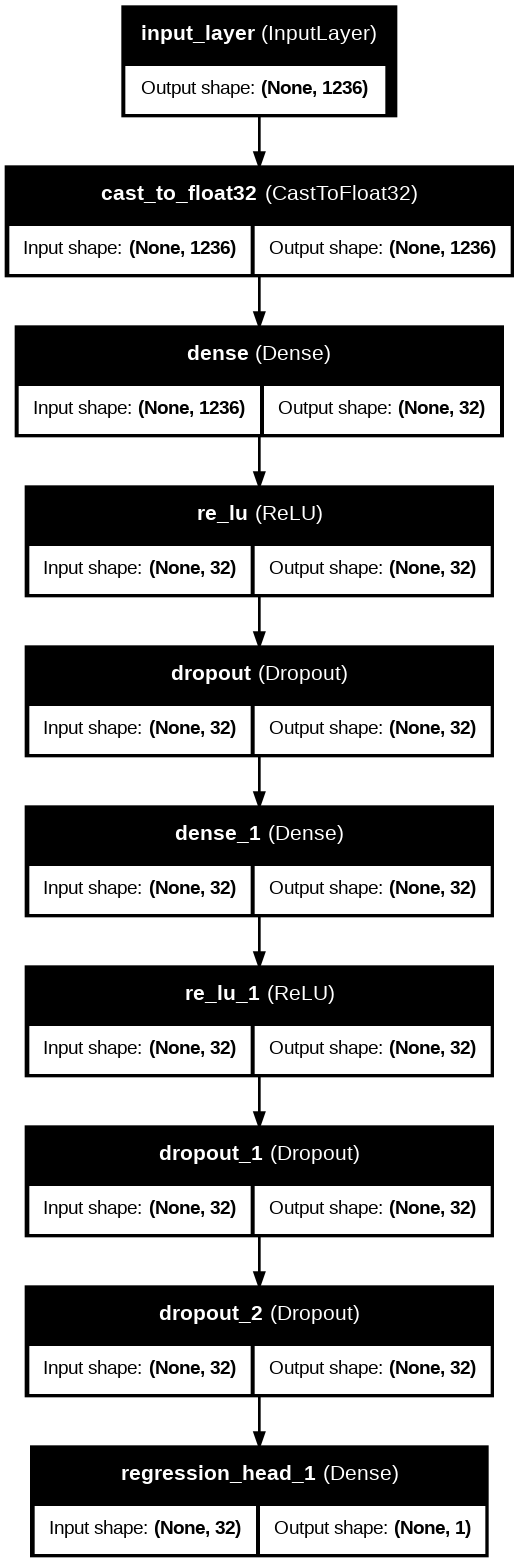

In [ ]:
import glob, os
from IPython.display import Image, display

# Find all matching images
images = glob.glob("auto_model_*_plot.png")

if images:
    # Pick the most recently modified one
    latest_img = max(images, key=os.path.getmtime)
    display(Image(filename=latest_img))
else:
    print("No matching images found.")

In [ ]:
import glob, os
from IPython.display import HTML, display

# Find all matching HTML reports
html_files = glob.glob("auto_model_*_summary.html")

if html_files:
    # Pick the most recently modified one
    latest_html = max(html_files, key=os.path.getmtime)
    display(HTML(filename=latest_html))
else:
    print("No matching HTML files found.")

## **Optimización de Hiperparámetros - AutoHPO**

#### *Grid Search* con H20

El [**Grid Search con H2O**](https://docs.h2o.ai/h2o/latest-stable/h2o-docs/grid-search.html) es una técnica de optimización de hiperparámetros que consiste en explorar de manera exhaustiva todas las combinaciones posibles de un conjunto definido de valores para cada hiperparámetro de un modelo (por ejemplo, número de árboles, profundidad máxima, tasa de aprendizaje en un GBM). H2O permite automatizar este proceso sobre modelos de machine learning como GBM, Random Forest o Deep Learning, entrenando un modelo para cada combinación y evaluando su desempeño según la métrica seleccionada. El resultado es la identificación de la configuración de hiperparámetros que produce el mejor rendimiento en validación, facilitando la construcción de modelos más precisos y robustos de forma sistemática, aunque a costa de un mayor tiempo computacional si el espacio de búsqueda es grande.

##### Recuperación de Auto Modelos generados

Intento recuperar modelos entrenados para el grid search. Si existen los tomo de GitHub para no volver a generarlos todos.

Para regenerarlos, no ejecutar la celda que sigue

In [ ]:
import os
import requests
import json

def download_github_directory(repo_owner, repo_name, dir_path, local_dir):
    """
    Download all files from a GitHub repository directory (and subdirectories) to a local directory.
    """
    api_url = f"https://api.github.com/repos/{repo_owner}/{repo_name}/contents/{dir_path}"

    try:
        response = requests.get(api_url)
        response.raise_for_status()
        contents = response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching directory contents: {e}")
        return

    os.makedirs(local_dir, exist_ok=True)

    for item in contents:
        item_path = item['path']
        item_name = item['name']
        item_type = item['type']

        if item_type == 'file':
            download_url = item['download_url']
            local_file_path = os.path.join(local_dir, item_name)

            print(f"Downloading {item_name}...")
            try:
                file_response = requests.get(download_url)
                file_response.raise_for_status()

                with open(local_file_path, 'wb') as f:
                    f.write(file_response.content)

                print(f"Successfully downloaded: {item_name}")
            except requests.exceptions.RequestException as e:
                print(f"Failed to download {item_name}: {e}")

        elif item_type == 'dir':
            sub_local_dir = os.path.join(local_dir, item_name)
            print(f"Entering subdirectory: {item_name}")
            download_github_directory(repo_owner, repo_name, item_path, sub_local_dir)

# Usage: Download from the specified GitHub repo directory to local 'h20_grids' folder
repo_owner = 'georgsmeinung'
repo_name = 'mlops-pipeline'
github_dir = 'h2o_grids'
local_dir = 'h2o_grids'

download_github_directory(repo_owner, repo_name, github_dir, local_dir)
print(f"All files from {github_dir} have been downloaded to {local_dir}/")

Successfully downloaded: Ensemble_Optimized
Successfully downloaded: drf_grid_opt
Successfully downloaded: drf_grid_opt_model_1
Successfully downloaded: drf_grid_opt_model_10
Successfully downloaded: drf_grid_opt_model_11
Successfully downloaded: drf_grid_opt_model_12
Successfully downloaded: drf_grid_opt_model_13
Successfully downloaded: drf_grid_opt_model_14
Successfully downloaded: drf_grid_opt_model_15
Successfully downloaded: drf_grid_opt_model_16
Successfully downloaded: drf_grid_opt_model_17
Successfully downloaded: drf_grid_opt_model_18
Successfully downloaded: drf_grid_opt_model_19
Successfully downloaded: drf_grid_opt_model_2
Successfully downloaded: drf_grid_opt_model_20
Successfully downloaded: drf_grid_opt_model_21
Successfully downloaded: drf_grid_opt_model_22
Successfully downloaded: drf_grid_opt_model_23
Successfully downloaded: drf_grid_opt_model_24
Successfully downloaded: drf_grid_opt_model_25
Successfully downloaded: drf_grid_opt_model_26
Successfully downloaded: dr

##### Grid Search

In [ ]:
import os
import logging
import h2o
from IPython.display import display, Markdown

from h2o.grid.grid_search import H2OGridSearch
from h2o.estimators.gbm import H2OGradientBoostingEstimator
from h2o.estimators.random_forest import H2ORandomForestEstimator
from h2o.estimators.xgboost import H2OXGBoostEstimator
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator

logging.getLogger("dtale").propagate = False
logging.getLogger("dtale").setLevel(logging.CRITICAL)

In [ ]:
if not h2o.connection():
    h2o.init()

output_dir = "h2o_grids"
os.makedirs(output_dir, exist_ok=True)
search_criteria = {"strategy": "RandomDiscrete", "max_models": 30, "seed": 42}

num_features = len(features)

gbm_params = {
    'ntrees': [100, 200],
    'max_depth': [3, 5],
    'learn_rate': [0.05, 0.1],
    'sample_rate': [0.8, 1.0],
    'col_sample_rate': [0.8, 1.0]
}

drf_params = {
    'ntrees': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'sample_rate': [0.7, 0.8, 0.9],
    'mtries': [-1, max(1, num_features // 2), num_features]
}

xgb_params = {
    'ntrees': [200, 500],
    'max_depth': [3, 6, 9],
    'learn_rate': [0.05, 0.1],
    'sample_rate': [0.8, 1.0],
    'col_sample_rate': [0.8, 1.0]
}

def train_or_load_grid(grid_id, algo, params):
    """Entrena o carga un grid de H2O (guarda en output_dir)."""
    grid_path = os.path.join(output_dir, grid_id)
    if os.path.exists(grid_path):
        print(f"⚡ Cargando grid {grid_id} desde disco...")
        return h2o.load_grid(grid_path)
    print(f"🚀 Entrenando grid {grid_id}...")
    grid = H2OGridSearch(model=algo, hyper_params=params,
                         search_criteria=search_criteria, grid_id=grid_id)
    grid.train(x=features, y=target, training_frame=train_h2o, nfolds=5, seed=42)
    h2o.save_grid(grid_directory=output_dir, grid_id=grid_id,
                  export_cross_validation_predictions=True)
    return grid

def retrain_best_from_grid(grid, algo_cls, name=None):
    """
    Extrae mejores params del grid, limpia keys conflictivas y reentrena
    un modelo 'limpio' con nfolds y keep_cross_validation_predictions=True.
    Devuelve el modelo entrenado.
    """
    best_model_from_grid = grid.get_grid(sort_by='rmse', decreasing=False).models[0]
    best_params = best_model_from_grid.get_params()
    # eliminar claves que no queremos duplicar o que no son constructor args
    for k in ["nfolds", "seed", "keep_cross_validation_predictions"]:
        best_params.pop(k, None)
    model = algo_cls(**best_params, nfolds=5, seed=42, keep_cross_validation_predictions=True)
    print(f"🔁 Reentrenando {name or algo_cls.__name__} con mejores hiperparámetros...")
    model.train(x=features, y=target, training_frame=train_h2o)
    return model

gbm_grid = train_or_load_grid("gbm_grid_opt", H2OGradientBoostingEstimator, gbm_params)
drf_grid = train_or_load_grid("drf_grid_opt", H2ORandomForestEstimator, drf_params)
xgb_grid = train_or_load_grid("xgb_grid_opt", H2OXGBoostEstimator, xgb_params)

print("\n------------------------------------\n")

gbm_final = retrain_best_from_grid(gbm_grid, H2OGradientBoostingEstimator, name="GBM Optimizado")
drf_final = retrain_best_from_grid(drf_grid, H2ORandomForestEstimator, name="DRF Optimizado")
xgb_final = retrain_best_from_grid(xgb_grid, H2OXGBoostEstimator, name="XGB Optimizado")

print("\n------------------------------------\n")

ensemble_dir = os.path.join(output_dir, "Ensemble_Optimized")
ensemble_model_id = "Ensemble_Optimized"
if os.path.exists(os.path.join(ensemble_dir, ensemble_model_id)):
    print("⚡ Cargando ensemble desde disco...")
    ensemble = h2o.load_model(os.path.join(ensemble_dir, ensemble_model_id))
else:
    print("🚀 Entrenando ensemble optimizado (base_models: GBM, DRF, XGB)...")
    ensemble = H2OStackedEnsembleEstimator(
        model_id=ensemble_model_id,
        base_models=[gbm_final.model_id, drf_final.model_id, xgb_final.model_id]
    )
    ensemble.train(x=features, y=target, training_frame=train_h2o)
    h2o.save_model(model=ensemble, path=output_dir, force=True)

print("\n------------------------------------\n")

perf = gbm_final.model_performance(test_h2o)
mse_gbm_gs = perf.mse(); rmse_gbm_gs = perf.rmse(); mae_gbm_gs = perf.mae(); r2_gbm_gs = perf.r2()
preds_gbm_gs = gbm_final.predict(test_h2o).as_data_frame()

perf = drf_final.model_performance(test_h2o)
mse_drf_gs = perf.mse(); rmse_drf_gs = perf.rmse(); mae_drf_gs = perf.mae(); r2_drf_gs = perf.r2()
preds_drf_gs = drf_final.predict(test_h2o).as_data_frame()

perf = xgb_final.model_performance(test_h2o)
mse_xgb_gs = perf.mse(); rmse_xgb_gs = perf.rmse(); mae_xgb_gs = perf.mae(); r2_xgb_gs = perf.r2()
preds_xgb_gs = xgb_final.predict(test_h2o).as_data_frame()

perf = ensemble.model_performance(test_h2o)
mse_ens_gs = perf.mse(); rmse_ens_gs = perf.rmse(); mae_ens_gs = perf.mae(); r2_ens_gs = perf.r2()
preds_ensemble_gs = ensemble.predict(test_h2o).as_data_frame()

⚡ Cargando grid gbm_grid_opt desde disco...
⚡ Cargando grid drf_grid_opt desde disco...
⚡ Cargando grid xgb_grid_opt desde disco...

------------------------------------

🔁 Reentrenando GBM Optimizado con mejores hiperparámetros...
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
🔁 Reentrenando DRF Optimizado con mejores hiperparámetros...
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
🔁 Reentrenando XGB Optimizado con mejores hiperparámetros...
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%

------------------------------------

🚀 Entrenando ensemble optimizado (base_models: GBM, DRF, XGB)...
stackedensemble Model Build progress: |██████████████████████████████████████████| (done) 100%

------------------------------------

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |██

##### Resultados del *Grid Search*

In [ ]:
table_md = (
    "**Tabla 6**  \n"
    "*Métricas en Test Set — Modelos optimizados con Grid Search*  \n\n"
    "| Modelo | MSE | RMSE | MAE | R² |\n"
    "|---|---:|---:|---:|---:|\n"
    f"| GBM GS      | {mse_gbm_gs:,.2f} | {rmse_gbm_gs:,.2f} | {mae_gbm_gs:,.2f} | {r2_gbm_gs:.4f} |\n"
    f"| DRF GS      | {mse_drf_gs:,.2f} | {rmse_drf_gs:,.2f} | {mae_drf_gs:,.2f} | {r2_drf_gs:.4f} |\n"
    f"| XGB GS      | {mse_xgb_gs:,.2f} | {rmse_xgb_gs:,.2f} | {mae_xgb_gs:,.2f} | {r2_xgb_gs:.4f} |\n"
    f"| Ensemble GS | {mse_ens_gs:,.2f} | {rmse_ens_gs:,.2f} | {mae_ens_gs:,.2f} | {r2_ens_gs:.4f} |\n"
)

display(Markdown(table_md))

**Tabla 6**  
*Métricas en Test Set — Modelos optimizados con Grid Search*  

| Modelo | MSE | RMSE | MAE | R² |
|---|---:|---:|---:|---:|
| GBM GS      | 40.31 | 6.35 | 5.43 | 0.2954 |
| DRF GS      | 51.01 | 7.14 | 5.89 | 0.1084 |
| XGB GS      | 39.32 | 6.27 | 4.82 | 0.3126 |
| Ensemble GS | 40.38 | 6.35 | 5.42 | 0.2941 |


#### Optimización Bayesianda con Optuna

[**Optuna**](https://optuna.org/) es una librería de Python para *optimización automática de hiperparámetros* que permite buscar de manera eficiente los valores óptimos de parámetros en modelos de machine learning y deep learning. Utiliza técnicas de *bayesian optimization*, *tree-structured Parzen estimators* y algoritmos de búsqueda secuencial para explorar espacios de hiperparámetros complejos de forma inteligente, priorizando configuraciones prometedoras. Su diseño es flexible y escalable, permitiendo definir fácilmente estudios de optimización, registrar resultados, ejecutar búsquedas en paralelo y aplicar *pruning* de ensayos poco prometedores, lo que acelera significativamente la identificación de configuraciones de modelos que maximizan el desempeño.

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 6.7 MB/s eta 0:00:00


##### Generación de Modelos

In [ ]:
import optuna
from h2o.estimators import H2OGradientBoostingEstimator, H2ORandomForestEstimator
from h2o.estimators import H2OXGBoostEstimator, H2OStackedEnsembleEstimator

In [ ]:
def objective(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 15),
        "learn_rate": trial.suggest_float("learn_rate", 0.001, 0.3, log=True),
        "sample_rate": trial.suggest_float("sample_rate", 0.6, 1.0),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.6, 1.0),
        "seed": 42
    }
    model = H2OGradientBoostingEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o, validation_frame=test_h2o)
    perf = model.model_performance(valid=True)
    return perf.rmse()   # o perf.mse(), o -perf.r2()

def objective_drf(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "sample_rate": trial.suggest_float("sample_rate", 0.6, 1.0),
        "col_sample_rate_per_tree": trial.suggest_float("col_sample_rate_per_tree", 0.6, 1.0),
        "min_rows": trial.suggest_int("min_rows", 1, 10),
        "seed": 42
    }
    model = H2ORandomForestEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o, validation_frame=test_h2o)
    perf = model.model_performance(valid=True)
    return perf.rmse()

def objective_xgb(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learn_rate": trial.suggest_float("learn_rate", 0.001, 0.3, log=True),
        "sample_rate": trial.suggest_float("sample_rate", 0.6, 1.0),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.6, 1.0),
        "min_rows": trial.suggest_int("min_rows", 1, 10),
        "seed": 42
    }
    model = H2OXGBoostEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o, validation_frame=test_h2o)
    perf = model.model_performance(valid=True)
    return perf.rmse()

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)

study_gbm = optuna.create_study(direction="minimize")
study_gbm.optimize(objective, n_trials=30)

study_drf = optuna.create_study(direction="minimize")
study_drf.optimize(objective_drf, n_trials=30)

[I 2025-10-03 22:15:22,706] A new study created in memory with name: no-name-12746d62-b102-40fd-a054-cf3483a69096


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:15:34,637] Trial 0 finished with value: 6.092942402711029 and parameters: {'ntrees': 290, 'max_depth': 3, 'learn_rate': 0.027488388479577908, 'sample_rate': 0.9000698749850871, 'col_sample_rate': 0.9850162320622408, 'min_rows': 4}. Best is trial 0 with value: 6.092942402711029.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:15:45,318] Trial 1 finished with value: 6.057423256234462 and parameters: {'ntrees': 177, 'max_depth': 6, 'learn_rate': 0.03923805512289784, 'sample_rate': 0.9546196260129685, 'col_sample_rate': 0.9684902691519024, 'min_rows': 10}. Best is trial 1 with value: 6.057423256234462.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:16:03,631] Trial 2 finished with value: 6.19809249164326 and parameters: {'ntrees': 248, 'max_depth': 13, 'learn_rate': 0.1024839287636995, 'sample_rate': 0.8784373984597498, 'col_sample_rate': 0.7908660131695159, 'min_rows': 7}. Best is trial 1 with value: 6.057423256234462.


xgboost Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:16:13,482] Trial 3 finished with value: 14.653573060626044 and parameters: {'ntrees': 95, 'max_depth': 15, 'learn_rate': 0.008306064358846316, 'sample_rate': 0.8010787415983378, 'col_sample_rate': 0.8544289380772727, 'min_rows': 1}. Best is trial 1 with value: 6.057423256234462.


█| (done) 100%
xgboost Model Build progress: |████████████████████████████████████████████████

[I 2025-10-03 22:16:26,491] Trial 4 finished with value: 6.145260483300627 and parameters: {'ntrees': 249, 'max_depth': 11, 'learn_rate': 0.04839295017932455, 'sample_rate': 0.7320456107924957, 'col_sample_rate': 0.7111801522547385, 'min_rows': 10}. Best is trial 1 with value: 6.057423256234462.


██| (done) 100%
xgboost Model Build progress: |████████████████

[I 2025-10-03 22:16:33,239] Trial 5 finished with value: 5.894561658291863 and parameters: {'ntrees': 169, 'max_depth': 8, 'learn_rate': 0.21722886448944276, 'sample_rate': 0.8774426999090978, 'col_sample_rate': 0.9757580719635369, 'min_rows': 5}. Best is trial 5 with value: 5.894561658291863.


██████████████████████████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:16:39,953] Trial 6 finished with value: 5.805988280115606 and parameters: {'ntrees': 111, 'max_depth': 13, 'learn_rate': 0.14799223409070783, 'sample_rate': 0.6804291307437096, 'col_sample_rate': 0.6630429629204125, 'min_rows': 6}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:16:52,952] Trial 7 finished with value: 6.0125145784630964 and parameters: {'ntrees': 358, 'max_depth': 15, 'learn_rate': 0.11270084996268115, 'sample_rate': 0.6846172088585472, 'col_sample_rate': 0.9382518321818831, 'min_rows': 10}. Best is trial 6 with value: 5.805988280115606.


█| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:17:00,515] Trial 8 finished with value: 6.383087115584654 and parameters: {'ntrees': 404, 'max_depth': 7, 'learn_rate': 0.12232687600336213, 'sample_rate': 0.6286369933106933, 'col_sample_rate': 0.8342761344922599, 'min_rows': 2}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:17:07,317] Trial 9 finished with value: 18.329899733158754 and parameters: {'ntrees': 416, 'max_depth': 14, 'learn_rate': 0.0010140489915440823, 'sample_rate': 0.704845406180888, 'col_sample_rate': 0.7949974140909298, 'min_rows': 9}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:17:09,258] Trial 10 finished with value: 16.420994267395606 and parameters: {'ntrees': 74, 'max_depth': 11, 'learn_rate': 0.007772598517865511, 'sample_rate': 0.6000236117630037, 'col_sample_rate': 0.6167425444889696, 'min_rows': 7}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |████████████████████████████████████████

[I 2025-10-03 22:17:13,958] Trial 11 finished with value: 6.201471351648201 and parameters: {'ntrees': 157, 'max_depth': 9, 'learn_rate': 0.2667404728076297, 'sample_rate': 0.7973624642266512, 'col_sample_rate': 0.6127617059410849, 'min_rows': 5}. Best is trial 6 with value: 5.805988280115606.


██████████| (done) 100%
xgboost Model Build progress: |████████████████████████████████████████████

[I 2025-10-03 22:17:20,407] Trial 12 finished with value: 6.565324725699742 and parameters: {'ntrees': 153, 'max_depth': 8, 'learn_rate': 0.29550199061396054, 'sample_rate': 0.8190509615856613, 'col_sample_rate': 0.8971887535542954, 'min_rows': 4}. Best is trial 6 with value: 5.805988280115606.


██████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:17:21,996] Trial 13 finished with value: 15.102647222928328 and parameters: {'ntrees': 67, 'max_depth': 11, 'learn_rate': 0.010412730066956583, 'sample_rate': 0.9699225312303177, 'col_sample_rate': 0.7076621189436718, 'min_rows': 7}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |████████████████████████████████████████████████

[I 2025-10-03 22:17:26,759] Trial 14 finished with value: 18.453912615725685 and parameters: {'ntrees': 194, 'max_depth': 4, 'learn_rate': 0.002130964134404196, 'sample_rate': 0.8872766616353635, 'col_sample_rate': 0.6856695208838757, 'min_rows': 6}. Best is trial 6 with value: 5.805988280115606.


██| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:17:33,624] Trial 15 finished with value: 6.393687129461047 and parameters: {'ntrees': 122, 'max_depth': 9, 'learn_rate': 0.06946143637317455, 'sample_rate': 0.7594075627057247, 'col_sample_rate': 0.7527381902792158, 'min_rows': 3}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:17:47,253] Trial 16 finished with value: 6.0760431411865286 and parameters: {'ntrees': 493, 'max_depth': 12, 'learn_rate': 0.1877793496580123, 'sample_rate': 0.6636455923650394, 'col_sample_rate': 0.6577725653481867, 'min_rows': 5}. Best is trial 6 with value: 5.805988280115606.


█| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████

[I 2025-10-03 22:17:52,745] Trial 17 finished with value: 6.24382676100445 and parameters: {'ntrees': 207, 'max_depth': 7, 'learn_rate': 0.01998786781622615, 'sample_rate': 0.8369146835656152, 'col_sample_rate': 0.884903616887124, 'min_rows': 8}. Best is trial 6 with value: 5.805988280115606.


████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:18:00,551] Trial 18 finished with value: 5.946355613558816 and parameters: {'ntrees': 306, 'max_depth': 5, 'learn_rate': 0.15711596190658805, 'sample_rate': 0.7526665264054135, 'col_sample_rate': 0.7506580237720871, 'min_rows': 6}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:18:06,230] Trial 19 finished with value: 6.294436801868433 and parameters: {'ntrees': 121, 'max_depth': 10, 'learn_rate': 0.0677032651964186, 'sample_rate': 0.9289593113481941, 'col_sample_rate': 0.9444400662222898, 'min_rows': 3}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |███████████████████████████████████████████████

[I 2025-10-03 22:18:15,986] Trial 20 finished with value: 6.202805763595989 and parameters: {'ntrees': 223, 'max_depth': 13, 'learn_rate': 0.07437432609571305, 'sample_rate': 0.8545720940858603, 'col_sample_rate': 0.656239769316853, 'min_rows': 4}. Best is trial 6 with value: 5.805988280115606.


███| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:18:22,512] Trial 21 finished with value: 5.877546926521085 and parameters: {'ntrees': 310, 'max_depth': 5, 'learn_rate': 0.16454951243509827, 'sample_rate': 0.7539517413093586, 'col_sample_rate': 0.7384218257869665, 'min_rows': 6}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:18:29,372] Trial 22 finished with value: 5.916848281288887 and parameters: {'ntrees': 343, 'max_depth': 5, 'learn_rate': 0.19702781864580723, 'sample_rate': 0.7717402547458623, 'col_sample_rate': 0.7394078317652162, 'min_rows': 6}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |████████████████████████████████████████████████

[I 2025-10-03 22:18:34,127] Trial 23 finished with value: 6.402371563414376 and parameters: {'ntrees': 119, 'max_depth': 7, 'learn_rate': 0.295429903880422, 'sample_rate': 0.6529612983378115, 'col_sample_rate': 0.6642730607171723, 'min_rows': 8}. Best is trial 6 with value: 5.805988280115606.


██| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:18:43,750] Trial 24 finished with value: 6.008898110785195 and parameters: {'ntrees': 323, 'max_depth': 8, 'learn_rate': 0.03924130310977775, 'sample_rate': 0.7036006794436438, 'col_sample_rate': 0.7819787684664322, 'min_rows': 5}. Best is trial 6 with value: 5.805988280115606.


xgboost Model Build progress: |████████████████████████████████████████

[I 2025-10-03 22:18:49,390] Trial 25 finished with value: 5.810460560121474 and parameters: {'ntrees': 253, 'max_depth': 5, 'learn_rate': 0.1589333287608946, 'sample_rate': 0.997555580501376, 'col_sample_rate': 0.8307427512310828, 'min_rows': 8}. Best is trial 6 with value: 5.805988280115606.


██████████| (done) 100%
xgboost Model Build progress: |██████████████████

[I 2025-10-03 22:18:56,411] Trial 26 finished with value: 9.50036015102562 and parameters: {'ntrees': 400, 'max_depth': 3, 'learn_rate': 0.00400643010166981, 'sample_rate': 0.694641116008502, 'col_sample_rate': 0.8265548701919948, 'min_rows': 8}. Best is trial 6 with value: 5.805988280115606.


████████████████████████████████| (done) 100%
xgboost Model Build progress: |█████████████████████████████████████████

[I 2025-10-03 22:19:02,120] Trial 27 finished with value: 5.572142369737229 and parameters: {'ntrees': 259, 'max_depth': 5, 'learn_rate': 0.10711130847340733, 'sample_rate': 0.7197820018772447, 'col_sample_rate': 0.7210048681700473, 'min_rows': 9}. Best is trial 27 with value: 5.572142369737229.


█████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:19:08,696] Trial 28 finished with value: 5.975050560951254 and parameters: {'ntrees': 262, 'max_depth': 4, 'learn_rate': 0.0914015499670957, 'sample_rate': 0.9993264889529162, 'col_sample_rate': 0.6356967820709005, 'min_rows': 9}. Best is trial 27 with value: 5.572142369737229.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:19:14,035] Trial 29 finished with value: 6.151813009108068 and parameters: {'ntrees': 272, 'max_depth': 3, 'learn_rate': 0.02934286586610992, 'sample_rate': 0.7294963984232401, 'col_sample_rate': 0.6922827831070755, 'min_rows': 9}. Best is trial 27 with value: 5.572142369737229.
[I 2025-10-03 22:19:14,039] A new study created in memory with name: no-name-c3a7f8fe-7ec0-4b54-a633-7c90ef0d2329


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:19:21,222] Trial 0 finished with value: 7.0623959799344265 and parameters: {'ntrees': 293, 'max_depth': 8, 'learn_rate': 0.0016917517316476186, 'sample_rate': 0.925740887650823, 'col_sample_rate': 0.7003700196840904}. Best is trial 0 with value: 7.0623959799344265.


gbm Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:19:25,220] Trial 1 finished with value: 6.728953682968406 and parameters: {'ntrees': 104, 'max_depth': 14, 'learn_rate': 0.15759768506924113, 'sample_rate': 0.8700713947065264, 'col_sample_rate': 0.8702148292274049}. Best is trial 1 with value: 6.728953682968406.


███| (done) 100%
gbm Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:19:28,472] Trial 2 finished with value: 7.090296143474394 and parameters: {'ntrees': 104, 'max_depth': 15, 'learn_rate': 0.005036254122992324, 'sample_rate': 0.7381601742647287, 'col_sample_rate': 0.9208149327565117}. Best is trial 1 with value: 6.728953682968406.


███| (done) 100%
gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:19:31,156] Trial 3 finished with value: 6.366354322753831 and parameters: {'ntrees': 266, 'max_depth': 3, 'learn_rate': 0.025068586206170737, 'sample_rate': 0.7212297582769163, 'col_sample_rate': 0.690692185503725}. Best is trial 3 with value: 6.366354322753831.


██| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:19:40,248] Trial 4 finished with value: 6.4601739827282785 and parameters: {'ntrees': 409, 'max_depth': 8, 'learn_rate': 0.28850710478853325, 'sample_rate': 0.6408172472927811, 'col_sample_rate': 0.7987313745441702}. Best is trial 3 with value: 6.366354322753831.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:19:47,491] Trial 5 finished with value: 6.914862336975259 and parameters: {'ntrees': 334, 'max_depth': 8, 'learn_rate': 0.0025689827386793326, 'sample_rate': 0.6820071809953413, 'col_sample_rate': 0.9491599685112571}. Best is trial 3 with value: 6.366354322753831.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:19:51,516] Trial 6 finished with value: 6.337511094018918 and parameters: {'ntrees': 97, 'max_depth': 14, 'learn_rate': 0.08611447959995583, 'sample_rate': 0.7930891288492916, 'col_sample_rate': 0.9924321118124102}. Best is trial 6 with value: 6.337511094018918.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:19:59,087] Trial 7 finished with value: 5.66626243164585 and parameters: {'ntrees': 260, 'max_depth': 15, 'learn_rate': 0.20490490065627903, 'sample_rate': 0.8044114300221394, 'col_sample_rate': 0.8226383795963769}. Best is trial 7 with value: 5.66626243164585.


gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:20:08,565] Trial 8 finished with value: 7.106396900852368 and parameters: {'ntrees': 372, 'max_depth': 13, 'learn_rate': 0.001427808919944318, 'sample_rate': 0.6842062467733991, 'col_sample_rate': 0.7439075043507455}. Best is trial 7 with value: 5.66626243164585.


██| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:20:11,805] Trial 9 finished with value: 5.637843378629978 and parameters: {'ntrees': 167, 'max_depth': 9, 'learn_rate': 0.19366356480480384, 'sample_rate': 0.8589691920767426, 'col_sample_rate': 0.68146958071573}. Best is trial 9 with value: 5.637843378629978.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:20:13,665] Trial 10 finished with value: 6.265242203203697 and parameters: {'ntrees': 187, 'max_depth': 3, 'learn_rate': 0.04021005977600512, 'sample_rate': 0.978901510900181, 'col_sample_rate': 0.624323255357989}. Best is trial 9 with value: 5.637843378629978.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:20:20,947] Trial 11 finished with value: 6.250208656081177 and parameters: {'ntrees': 216, 'max_depth': 11, 'learn_rate': 0.07121818557648447, 'sample_rate': 0.8417367104141864, 'col_sample_rate': 0.8361215671111818}. Best is trial 9 with value: 5.637843378629978.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:20:25,627] Trial 12 finished with value: 6.629001636449519 and parameters: {'ntrees': 194, 'max_depth': 11, 'learn_rate': 0.010508371210355654, 'sample_rate': 0.7999880982693837, 'col_sample_rate': 0.6022963510677175}. Best is trial 9 with value: 5.637843378629978.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:20:32,881] Trial 13 finished with value: 6.433337794007536 and parameters: {'ntrees': 473, 'max_depth': 5, 'learn_rate': 0.26876681460799096, 'sample_rate': 0.8700334146241613, 'col_sample_rate': 0.7767570739412011}. Best is trial 9 with value: 5.637843378629978.


█| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:20:38,760] Trial 14 finished with value: 6.121141799451668 and parameters: {'ntrees': 159, 'max_depth': 11, 'learn_rate': 0.10790605865964711, 'sample_rate': 0.9327404130403661, 'col_sample_rate': 0.6899562932463918}. Best is trial 9 with value: 5.637843378629978.


█████| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:20:43,275] Trial 15 finished with value: 6.111123621723785 and parameters: {'ntrees': 241, 'max_depth': 6, 'learn_rate': 0.04045247880562858, 'sample_rate': 0.7711742144052042, 'col_sample_rate': 0.874636684622318}. Best is trial 9 with value: 5.637843378629978.


█| (done) 100%
gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:20:48,718] Trial 16 finished with value: 6.736384567595388 and parameters: {'ntrees': 150, 'max_depth': 10, 'learn_rate': 0.008988290443305532, 'sample_rate': 0.8358885237395028, 'col_sample_rate': 0.7353105469930086}. Best is trial 9 with value: 5.637843378629978.


██| (done) 100%
gbm Model Build progress: |███

[I 2025-10-03 22:20:49,385] Trial 17 finished with value: 6.095911724717746 and parameters: {'ntrees': 51, 'max_depth': 6, 'learn_rate': 0.14310437704140527, 'sample_rate': 0.9046058589297551, 'col_sample_rate': 0.6503488075806891}. Best is trial 9 with value: 5.637843378629978.


███████████████████████████████████████████████████| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:20:56,921] Trial 18 finished with value: 6.593799069993678 and parameters: {'ntrees': 305, 'max_depth': 13, 'learn_rate': 0.0504477382790292, 'sample_rate': 0.9987605385652547, 'col_sample_rate': 0.8419090448001754}. Best is trial 9 with value: 5.637843378629978.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:21:08,246] Trial 19 finished with value: 6.381088991418262 and parameters: {'ntrees': 243, 'max_depth': 10, 'learn_rate': 0.024239700143298144, 'sample_rate': 0.6111402192522053, 'col_sample_rate': 0.7601999532190988}. Best is trial 9 with value: 5.637843378629978.


gbm Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:21:13,724] Trial 20 finished with value: 6.018487734843759 and parameters: {'ntrees': 364, 'max_depth': 5, 'learn_rate': 0.201817189077076, 'sample_rate': 0.7521844633050877, 'col_sample_rate': 0.8181784023870705}. Best is trial 9 with value: 5.637843378629978.


███| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:21:20,350] Trial 21 finished with value: 5.942789990608395 and parameters: {'ntrees': 423, 'max_depth': 5, 'learn_rate': 0.1918402174398412, 'sample_rate': 0.7583797891055918, 'col_sample_rate': 0.8319229339032121}. Best is trial 9 with value: 5.637843378629978.


gbm Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:21:27,620] Trial 22 finished with value: 5.4215659112655645 and parameters: {'ntrees': 460, 'max_depth': 6, 'learn_rate': 0.1237999452807511, 'sample_rate': 0.8273551472403889, 'col_sample_rate': 0.8884616088266679}. Best is trial 22 with value: 5.4215659112655645.


███| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:21:33,231] Trial 23 finished with value: 6.017596910708268 and parameters: {'ntrees': 471, 'max_depth': 2, 'learn_rate': 0.10438292638485974, 'sample_rate': 0.8462139910118768, 'col_sample_rate': 0.9041098762931594}. Best is trial 22 with value: 5.4215659112655645.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:21:39,516] Trial 24 finished with value: 5.925543545714728 and parameters: {'ntrees': 324, 'max_depth': 7, 'learn_rate': 0.05983514166236424, 'sample_rate': 0.8074718352007915, 'col_sample_rate': 0.8759425380382148}. Best is trial 22 with value: 5.4215659112655645.


█| (done) 100%
gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:21:52,056] Trial 25 finished with value: 6.110794119014566 and parameters: {'ntrees': 495, 'max_depth': 9, 'learn_rate': 0.28896349812797084, 'sample_rate': 0.894256980165207, 'col_sample_rate': 0.9563065274424558}. Best is trial 22 with value: 5.4215659112655645.


██| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:21:55,961] Trial 26 finished with value: 6.675051020311232 and parameters: {'ntrees': 146, 'max_depth': 12, 'learn_rate': 0.1283985136491744, 'sample_rate': 0.8218552341352112, 'col_sample_rate': 0.7868659959917528}. Best is trial 22 with value: 5.4215659112655645.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:22:00,878] Trial 27 finished with value: 5.961429643739077 and parameters: {'ntrees': 267, 'max_depth': 4, 'learn_rate': 0.18009909646019587, 'sample_rate': 0.9539568964775047, 'col_sample_rate': 0.7228362401764049}. Best is trial 22 with value: 5.4215659112655645.


█| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:22:09,051] Trial 28 finished with value: 6.09794081603945 and parameters: {'ntrees': 426, 'max_depth': 7, 'learn_rate': 0.02671530419815029, 'sample_rate': 0.8637932662406007, 'col_sample_rate': 0.9079649263850726}. Best is trial 22 with value: 5.4215659112655645.


█| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:22:16,453] Trial 29 finished with value: 6.147651118466341 and parameters: {'ntrees': 291, 'max_depth': 9, 'learn_rate': 0.09623787499189361, 'sample_rate': 0.9049950882224881, 'col_sample_rate': 0.6512302441226949}. Best is trial 22 with value: 5.4215659112655645.
[I 2025-10-03 22:22:16,455] A new study created in memory with name: no-name-73cdb176-cfd4-4fee-a87a-95b57cd63a9c


█| (done) 100%
drf Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:22:21,603] Trial 0 finished with value: 7.2595547460796865 and parameters: {'ntrees': 157, 'max_depth': 8, 'sample_rate': 0.6171036818036849, 'col_sample_rate_per_tree': 0.6110227978379646, 'min_rows': 10}. Best is trial 0 with value: 7.2595547460796865.


███| (done) 100%
drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:22:27,981] Trial 1 finished with value: 7.329991381099466 and parameters: {'ntrees': 238, 'max_depth': 14, 'sample_rate': 0.7615686637337131, 'col_sample_rate_per_tree': 0.8588503400630776, 'min_rows': 7}. Best is trial 0 with value: 7.2595547460796865.


██| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:22:37,387] Trial 2 finished with value: 7.264695933676578 and parameters: {'ntrees': 342, 'max_depth': 13, 'sample_rate': 0.6219673738865873, 'col_sample_rate_per_tree': 0.6293980946277549, 'min_rows': 4}. Best is trial 0 with value: 7.2595547460796865.


drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:22:59,237] Trial 3 finished with value: 7.501768634720138 and parameters: {'ntrees': 476, 'max_depth': 27, 'sample_rate': 0.9397083607899315, 'col_sample_rate_per_tree': 0.8019114452518341, 'min_rows': 3}. Best is trial 0 with value: 7.2595547460796865.


█| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:23:13,579] Trial 4 finished with value: 7.320812310954046 and parameters: {'ntrees': 473, 'max_depth': 22, 'sample_rate': 0.94017379284947, 'col_sample_rate_per_tree': 0.8370370752814121, 'min_rows': 6}. Best is trial 0 with value: 7.2595547460796865.


█| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:23:18,229] Trial 5 finished with value: 7.295933412937255 and parameters: {'ntrees': 163, 'max_depth': 24, 'sample_rate': 0.9241409929372083, 'col_sample_rate_per_tree': 0.8082366442892073, 'min_rows': 6}. Best is trial 0 with value: 7.2595547460796865.


█| (done) 100%
drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:23:29,084] Trial 6 finished with value: 7.327763096634987 and parameters: {'ntrees': 412, 'max_depth': 16, 'sample_rate': 0.8313193972374231, 'col_sample_rate_per_tree': 0.8205122866077601, 'min_rows': 6}. Best is trial 0 with value: 7.2595547460796865.


██| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:23:40,598] Trial 7 finished with value: 7.304406582523632 and parameters: {'ntrees': 495, 'max_depth': 11, 'sample_rate': 0.8432236533074335, 'col_sample_rate_per_tree': 0.8339623654865859, 'min_rows': 10}. Best is trial 0 with value: 7.2595547460796865.


█| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:23:52,370] Trial 8 finished with value: 7.351013732274795 and parameters: {'ntrees': 488, 'max_depth': 9, 'sample_rate': 0.7818897658546583, 'col_sample_rate_per_tree': 0.7058115612928503, 'min_rows': 1}. Best is trial 0 with value: 7.2595547460796865.


█| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:23:58,687] Trial 9 finished with value: 7.201055319561825 and parameters: {'ntrees': 275, 'max_depth': 9, 'sample_rate': 0.9800582893990814, 'col_sample_rate_per_tree': 0.7295079125438994, 'min_rows': 7}. Best is trial 9 with value: 7.201055319561825.


█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:23:59,822] Trial 10 finished with value: 7.215544906770719 and parameters: {'ntrees': 76, 'max_depth': 5, 'sample_rate': 0.9979980655639649, 'col_sample_rate_per_tree': 0.9780557574424709, 'min_rows': 8}. Best is trial 9 with value: 7.201055319561825.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:24:01,215] Trial 11 finished with value: 7.212349797196344 and parameters: {'ntrees': 76, 'max_depth': 5, 'sample_rate': 0.9966669434247618, 'col_sample_rate_per_tree': 0.9689000952262895, 'min_rows': 8}. Best is trial 9 with value: 7.201055319561825.


drf Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:24:06,952] Trial 12 finished with value: 7.067864519461576 and parameters: {'ntrees': 288, 'max_depth': 6, 'sample_rate': 0.9938010454072256, 'col_sample_rate_per_tree': 0.9750308971154276, 'min_rows': 8}. Best is trial 12 with value: 7.067864519461576.


█████| (done) 100%
drf Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:24:13,553] Trial 13 finished with value: 7.234991368708079 and parameters: {'ntrees': 289, 'max_depth': 20, 'sample_rate': 0.8763947914702547, 'col_sample_rate_per_tree': 0.7221940409296788, 'min_rows': 8}. Best is trial 12 with value: 7.067864519461576.


███| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:24:22,187] Trial 14 finished with value: 7.340152305386107 and parameters: {'ntrees': 333, 'max_depth': 9, 'sample_rate': 0.7102132884413244, 'col_sample_rate_per_tree': 0.9294079444803418, 'min_rows': 4}. Best is trial 12 with value: 7.067864519461576.


drf Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:24:28,460] Trial 15 finished with value: 7.204245936602403 and parameters: {'ntrees': 228, 'max_depth': 17, 'sample_rate': 0.8963332013286534, 'col_sample_rate_per_tree': 0.7305273668541583, 'min_rows': 9}. Best is trial 12 with value: 7.067864519461576.


███| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:24:34,075] Trial 16 finished with value: 7.23476301580448 and parameters: {'ntrees': 369, 'max_depth': 5, 'sample_rate': 0.9690855395260253, 'col_sample_rate_per_tree': 0.6757190201960094, 'min_rows': 7}. Best is trial 12 with value: 7.067864519461576.


drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:24:42,476] Trial 17 finished with value: 7.322024057621853 and parameters: {'ntrees': 289, 'max_depth': 30, 'sample_rate': 0.8907868189179768, 'col_sample_rate_per_tree': 0.9005750214373605, 'min_rows': 5}. Best is trial 12 with value: 7.067864519461576.


██| (done) 100%
drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:24:48,079] Trial 18 finished with value: 7.304147297434142 and parameters: {'ntrees': 194, 'max_depth': 11, 'sample_rate': 0.7052686377444768, 'col_sample_rate_per_tree': 0.7480837786520573, 'min_rows': 9}. Best is trial 12 with value: 7.067864519461576.


██| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:24:55,226] Trial 19 finished with value: 7.206467691845026 and parameters: {'ntrees': 402, 'max_depth': 8, 'sample_rate': 0.9619958098800885, 'col_sample_rate_per_tree': 0.7691752643552843, 'min_rows': 7}. Best is trial 12 with value: 7.067864519461576.


█| (done) 100%
drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:25:08,095] Trial 20 finished with value: 7.397803898084767 and parameters: {'ntrees': 250, 'max_depth': 13, 'sample_rate': 0.8489153258030331, 'col_sample_rate_per_tree': 0.6670245011649556, 'min_rows': 1}. Best is trial 12 with value: 7.067864519461576.


██| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:25:13,540] Trial 21 finished with value: 7.260040161214574 and parameters: {'ntrees': 212, 'max_depth': 18, 'sample_rate': 0.8861410711967477, 'col_sample_rate_per_tree': 0.7671605536252509, 'min_rows': 9}. Best is trial 12 with value: 7.067864519461576.


█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████

[I 2025-10-03 22:25:21,101] Trial 22 finished with value: 7.254902165028387 and parameters: {'ntrees': 307, 'max_depth': 18, 'sample_rate': 0.9281659885358934, 'col_sample_rate_per_tree': 0.7089790658198946, 'min_rows': 9}. Best is trial 12 with value: 7.067864519461576.


████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████

[I 2025-10-03 22:25:27,619] Trial 23 finished with value: 7.204855222949919 and parameters: {'ntrees': 253, 'max_depth': 15, 'sample_rate': 0.9681989389292199, 'col_sample_rate_per_tree': 0.8893534719237518, 'min_rows': 8}. Best is trial 12 with value: 7.067864519461576.


████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:25:31,733] Trial 24 finished with value: 7.12794816176204 and parameters: {'ntrees': 130, 'max_depth': 11, 'sample_rate': 0.9066302030333501, 'col_sample_rate_per_tree': 0.66293466903572, 'min_rows': 10}. Best is trial 12 with value: 7.067864519461576.


drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:25:35,103] Trial 25 finished with value: 6.939840884239426 and parameters: {'ntrees': 131, 'max_depth': 11, 'sample_rate': 0.9982833454650363, 'col_sample_rate_per_tree': 0.6770858665077368, 'min_rows': 10}. Best is trial 25 with value: 6.939840884239426.


██| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:25:37,841] Trial 26 finished with value: 7.130978962824373 and parameters: {'ntrees': 125, 'max_depth': 11, 'sample_rate': 0.9152145592175105, 'col_sample_rate_per_tree': 0.6568685308295472, 'min_rows': 10}. Best is trial 25 with value: 6.939840884239426.


drf Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:25:41,171] Trial 27 finished with value: 7.1454933747731255 and parameters: {'ntrees': 118, 'max_depth': 12, 'sample_rate': 0.9578270639547113, 'col_sample_rate_per_tree': 0.6011774781203213, 'min_rows': 10}. Best is trial 25 with value: 6.939840884239426.


█████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:25:43,463] Trial 28 finished with value: 7.046818241391418 and parameters: {'ntrees': 108, 'max_depth': 7, 'sample_rate': 0.9942918456533548, 'col_sample_rate_per_tree': 0.6386775541903105, 'min_rows': 9}. Best is trial 25 with value: 6.939840884239426.


drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:25:47,559] Trial 29 finished with value: 7.122985588871855 and parameters: {'ntrees': 175, 'max_depth': 6, 'sample_rate': 0.9952413464295031, 'col_sample_rate_per_tree': 0.6439723422614578, 'min_rows': 9}. Best is trial 25 with value: 6.939840884239426.


██| (done) 100%


In [ ]:
print("Best GBM params:", study_gbm.best_trial.params)
print("Best DRF params:", study_drf.best_trial.params)
print("Best XGB params:", study_xgb.best_trial.params)

Best GBM params: {'ntrees': 460, 'max_depth': 6, 'learn_rate': 0.1237999452807511, 'sample_rate': 0.8273551472403889, 'col_sample_rate': 0.8884616088266679}
Best DRF params: {'ntrees': 131, 'max_depth': 11, 'sample_rate': 0.9982833454650363, 'col_sample_rate_per_tree': 0.6770858665077368, 'min_rows': 10}
Best XGB params: {'ntrees': 259, 'max_depth': 5, 'learn_rate': 0.10711130847340733, 'sample_rate': 0.7197820018772447, 'col_sample_rate': 0.7210048681700473, 'min_rows': 9}


##### *Ensemble* de modelos con optimización bayesiana

In [ ]:
gbm_opt = H2OGradientBoostingEstimator(
    **study_gbm.best_trial.params,
    nfolds=5,
    keep_cross_validation_predictions=True,
    seed=1234
)
gbm_opt.train(x=features, y=target, training_frame=train_h2o)

drf_opt = H2ORandomForestEstimator(
    **study_drf.best_trial.params,
    nfolds=5,
    keep_cross_validation_predictions=True,
    seed=1234
)
drf_opt.train(x=features, y=target, training_frame=train_h2o)

xgb_opt = H2OXGBoostEstimator(
    **study_xgb.best_trial.params,
    nfolds=5,
    keep_cross_validation_predictions=True,
    seed=1234
)
xgb_opt.train(x=features, y=target, training_frame=train_h2o)

ensemble_opt = H2OStackedEnsembleEstimator(
    base_models=[gbm_opt.model_id, drf_opt.model_id, xgb_opt.model_id]
)
ensemble_opt.train(x=features, y=target, training_frame=train_h2o)

modelos = {
    "GBM BO": gbm_opt,
    "DRF BO": drf_opt,
    "XGB BO": xgb_opt,
    "Ensemble BO": ensemble_opt
}

metricas = []
for nombre, modelo in modelos.items():
    perf = modelo.model_performance(test_h2o)
    metricas.append({
        "Modelo": nombre,
        "MSE": perf.mse(),
        "RMSE": perf.rmse(),
        "MAE": perf.mae(),
        "R²": perf.r2()
    })

gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%
stackedensemble Model Build progress: |██████████████████████████████████████████| (done) 100%


##### Resultados

In [ ]:
df_metricas_bo = pd.DataFrame(metricas)

table_md = "**Tabla 7**  \n"
table_md += "*Métricas en Test Set — Modelos optimizados con Optimización Bayesiana*  \n\n"
table_md += df_metricas_bo.to_markdown(
    index=False,
    floatfmt=("", ".2f", ".2f", ".2f", ".4f")
)

display(Markdown(table_md))

**Tabla 7**  
*Métricas en Test Set — Modelos optimizados con Optimización Bayesiana*  

| Modelo      |   MSE |   RMSE |   MAE |     R² |
|:------------|------:|-------:|------:|-------:|
| GBM BO      | 32.59 |   5.71 |  4.71 | 0.4304 |
| DRF BO      | 48.69 |   6.98 |  5.75 | 0.1489 |
| XGB BO      | 38.19 |   6.18 |  5.12 | 0.3324 |
| Ensemble BO | 36.18 |   6.01 |  5.05 | 0.3676 |

#### *Hyperband Random Search* con Optuna

La [**Hyperband Random Search con Optuna**](https://tech.preferred.jp/en/blog/how-we-implement-hyperband-in-optuna/) es una estrategia de optimización de hiperparámetros que combina la exploración aleatoria con un esquema de *early stopping* para asignar recursos de manera eficiente. Optuna genera configuraciones de hiperparámetros de forma aleatoria y entrena modelos parcialmente, evaluando su desempeño tras un número limitado de iteraciones o recursos. Las configuraciones menos prometedoras se descartan temprano (*pruning*), mientras que las más prometedoras reciben más recursos para continuar el entrenamiento. Este enfoque permite explorar un gran espacio de hiperparámetros de manera más rápida y eficiente que un Grid Search exhaustivo, reduciendo el tiempo computacional sin sacrificar la probabilidad de encontrar configuraciones óptimas.


In [ ]:
import optuna
from optuna.pruners import HyperbandPruner
import numpy as np
import h2o
from h2o.estimators import H2OGradientBoostingEstimator, H2ORandomForestEstimator
from h2o.estimators import H2OXGBoostEstimator, H2OStackedEnsembleEstimator

np.seterr(all="ignore")

{'divide': 'raise', 'over': 'raise', 'under': 'raise', 'invalid': 'raise'}

In [ ]:
def objective_gbm(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learn_rate": trial.suggest_float("learn_rate", 1e-2, 0.3, log=True),
        "sample_rate": trial.suggest_float("sample_rate", 0.6, 1.0),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.6, 1.0),
        "min_rows": trial.suggest_int("min_rows", 2, 20),
        "seed": 42
    }
    model = H2OGradientBoostingEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o, validation_frame=test_h2o)
    return model.model_performance(test_h2o).rmse()

def objective_drf(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 50),
        "sample_rate": trial.suggest_float("sample_rate", 0.6, 1.0),
        "col_sample_rate_per_tree": trial.suggest_float("col_sample_rate_per_tree", 0.6, 1.0),
        "min_rows": trial.suggest_int("min_rows", 2, 20),
        "seed": 42
    }
    model = H2ORandomForestEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o, validation_frame=test_h2o)
    return model.model_performance(test_h2o).rmse()

def objective_xgb(trial):
    params = {
        "ntrees": trial.suggest_int("ntrees", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learn_rate": trial.suggest_float("learn_rate", 1e-2, 0.3, log=True),
        "sample_rate": trial.suggest_float("sample_rate", 0.6, 1.0),
        "col_sample_rate": trial.suggest_float("col_sample_rate", 0.6, 1.0),
        "min_rows": trial.suggest_int("min_rows", 2, 20),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "seed": 42
    }
    model = H2OXGBoostEstimator(**params)
    model.train(x=features, y=target, training_frame=train_h2o, validation_frame=test_h2o)
    return model.model_performance(test_h2o).rmse()

pruner = HyperbandPruner(min_resource=10, max_resource=100, reduction_factor=3)
sampler = optuna.samplers.TPESampler(n_startup_trials=10, seed=42, multivariate=True)

studies = {}
for name, obj_func in [("GBM", objective_gbm), ("DRF", objective_drf), ("XGB", objective_xgb)]:
    print(f"\n🔎 Optimizando {name} con Hyperband + TPE...")
    study = optuna.create_study(direction="minimize", pruner=pruner, sampler=sampler)
    study.optimize(obj_func, n_trials=50, timeout=600)
    studies[name] = study
    print(f"  ✅ Mejor RMSE {name}: {study.best_trial.value:.4f}")
    print(f"  Parámetros: {study.best_trial.params}")

study_gbm = studies["GBM"]
study_drf = studies["DRF"]
study_xgb = studies["XGB"]

[I 2025-10-03 22:27:49,280] A new study created in memory with name: no-name-48c73696-a635-4c54-a077-c0c75b8dbd80



🔎 Optimizando GBM con Hyperband + TPE...
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:27:58,108] Trial 0 finished with value: 5.919428510215325 and parameters: {'ntrees': 218, 'max_depth': 15, 'learn_rate': 0.1205712628744377, 'sample_rate': 0.8394633936788146, 'col_sample_rate': 0.6624074561769746, 'min_rows': 4}. Best is trial 0 with value: 5.919428510215325.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:00,437] Trial 1 finished with value: 6.3650176610120965 and parameters: {'ntrees': 76, 'max_depth': 14, 'learn_rate': 0.07725378389307355, 'sample_rate': 0.8832290311184181, 'col_sample_rate': 0.608233797718321, 'min_rows': 20}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:07,143] Trial 2 finished with value: 6.184536232088522 and parameters: {'ntrees': 425, 'max_depth': 5, 'learn_rate': 0.01855998084649059, 'sample_rate': 0.6733618039413735, 'col_sample_rate': 0.7216968971838151, 'min_rows': 11}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:12,022] Trial 3 finished with value: 6.261618557804194 and parameters: {'ntrees': 244, 'max_depth': 6, 'learn_rate': 0.08012737503998542, 'sample_rate': 0.6557975442608167, 'col_sample_rate': 0.7168578594140873, 'min_rows': 8}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:29,032] Trial 4 finished with value: 6.303722534334825 and parameters: {'ntrees': 255, 'max_depth': 13, 'learn_rate': 0.019721610970574007, 'sample_rate': 0.8056937753654446, 'col_sample_rate': 0.836965827544817, 'min_rows': 2}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:35,696] Trial 5 finished with value: 6.261282428013688 and parameters: {'ntrees': 324, 'max_depth': 5, 'learn_rate': 0.012476394272569451, 'sample_rate': 0.9795542149013333, 'col_sample_rate': 0.9862528132298237, 'min_rows': 17}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:37,617] Trial 6 finished with value: 5.999301936881102 and parameters: {'ntrees': 187, 'max_depth': 4, 'learn_rate': 0.1024932221692416, 'sample_rate': 0.7760609974958406, 'col_sample_rate': 0.6488152939379115, 'min_rows': 11}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:39,984] Trial 7 finished with value: 6.788142794263047 and parameters: {'ntrees': 65, 'max_depth': 14, 'learn_rate': 0.024112898115291985, 'sample_rate': 0.8650089137415928, 'col_sample_rate': 0.7246844304357644, 'min_rows': 11}. Best is trial 0 with value: 5.919428510215325.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:28:45,358] Trial 8 finished with value: 5.7094648832863895 and parameters: {'ntrees': 296, 'max_depth': 5, 'learn_rate': 0.27051668818999286, 'sample_rate': 0.9100531293444458, 'col_sample_rate': 0.9757995766256756, 'min_rows': 19}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:28:54,277] Trial 9 finished with value: 6.52381804165676 and parameters: {'ntrees': 319, 'max_depth': 14, 'learn_rate': 0.01351182947645082, 'sample_rate': 0.6783931449676581, 'col_sample_rate': 0.6180909155642152, 'min_rows': 8}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:29:07,372] Trial 10 finished with value: 6.040791318684614 and parameters: {'ntrees': 479, 'max_depth': 8, 'learn_rate': 0.2218846055789999, 'sample_rate': 0.8785135072617791, 'col_sample_rate': 0.9826080198108781, 'min_rows': 19}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:29:10,637] Trial 11 finished with value: 5.9694444424013575 and parameters: {'ntrees': 244, 'max_depth': 3, 'learn_rate': 0.21628161609292515, 'sample_rate': 0.9402031850848486, 'col_sample_rate': 0.9535919259821428, 'min_rows': 12}. Best is trial 8 with value: 5.7094648832863895.


██| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:29:24,408] Trial 12 finished with value: 6.708478022896439 and parameters: {'ntrees': 346, 'max_depth': 14, 'learn_rate': 0.2457620516085079, 'sample_rate': 0.8621348676230737, 'col_sample_rate': 0.604019940747212, 'min_rows': 5}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:29:33,046] Trial 13 finished with value: 6.251760371801657 and parameters: {'ntrees': 192, 'max_depth': 15, 'learn_rate': 0.11606021086038801, 'sample_rate': 0.8333422786860829, 'col_sample_rate': 0.790806461684803, 'min_rows': 4}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:29:36,409] Trial 14 finished with value: 6.290715239995637 and parameters: {'ntrees': 111, 'max_depth': 12, 'learn_rate': 0.18881484432971601, 'sample_rate': 0.7454899321805459, 'col_sample_rate': 0.6796147483603393, 'min_rows': 11}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:29:44,816] Trial 15 finished with value: 5.8083768310209845 and parameters: {'ntrees': 253, 'max_depth': 11, 'learn_rate': 0.13942926204636227, 'sample_rate': 0.9536022782286906, 'col_sample_rate': 0.9917900447955922, 'min_rows': 17}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:29:50,664] Trial 16 finished with value: 6.029756208545966 and parameters: {'ntrees': 258, 'max_depth': 8, 'learn_rate': 0.2282170212378126, 'sample_rate': 0.927509395546102, 'col_sample_rate': 0.8664380448063341, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:29:54,676] Trial 17 finished with value: 6.127191956712503 and parameters: {'ntrees': 131, 'max_depth': 9, 'learn_rate': 0.045384723836119606, 'sample_rate': 0.9337055235928239, 'col_sample_rate': 0.9914122349919825, 'min_rows': 14}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:30:05,562] Trial 18 finished with value: 6.423031263823481 and parameters: {'ntrees': 333, 'max_depth': 14, 'learn_rate': 0.10944747935496908, 'sample_rate': 0.908312498413164, 'col_sample_rate': 0.9105784931936243, 'min_rows': 16}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:30:11,325] Trial 19 finished with value: 5.998708553121135 and parameters: {'ntrees': 304, 'max_depth': 3, 'learn_rate': 0.19144688251670527, 'sample_rate': 0.997625019472506, 'col_sample_rate': 0.9943373341368315, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:30:15,235] Trial 20 finished with value: 6.058281656287837 and parameters: {'ntrees': 117, 'max_depth': 12, 'learn_rate': 0.18412095700433617, 'sample_rate': 0.986754572397637, 'col_sample_rate': 0.9978152242992487, 'min_rows': 11}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:30:21,627] Trial 21 finished with value: 6.19184874141902 and parameters: {'ntrees': 212, 'max_depth': 14, 'learn_rate': 0.0808040929854795, 'sample_rate': 0.8274729243674643, 'col_sample_rate': 0.6019658031040188, 'min_rows': 6}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:30:31,429] Trial 22 finished with value: 5.968307431767892 and parameters: {'ntrees': 263, 'max_depth': 11, 'learn_rate': 0.0951822797143575, 'sample_rate': 0.9964795525344456, 'col_sample_rate': 0.9696421877013226, 'min_rows': 17}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:30:39,052] Trial 23 finished with value: 5.97990401286762 and parameters: {'ntrees': 297, 'max_depth': 8, 'learn_rate': 0.08491877543420688, 'sample_rate': 0.8073470808779151, 'col_sample_rate': 0.9656886032459827, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


██| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:30:54,360] Trial 24 finished with value: 6.451851303556798 and parameters: {'ntrees': 294, 'max_depth': 15, 'learn_rate': 0.06774364168251822, 'sample_rate': 0.9604035508660617, 'col_sample_rate': 0.6734386449721697, 'min_rows': 3}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:30:59,628] Trial 25 finished with value: 5.743901662443045 and parameters: {'ntrees': 364, 'max_depth': 4, 'learn_rate': 0.16256439573402184, 'sample_rate': 0.8155843530957294, 'col_sample_rate': 0.8426792369751696, 'min_rows': 19}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:05,107] Trial 26 finished with value: 5.817496508934571 and parameters: {'ntrees': 417, 'max_depth': 4, 'learn_rate': 0.07183007247332572, 'sample_rate': 0.789037041371142, 'col_sample_rate': 0.6847639927354721, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:09,160] Trial 27 finished with value: 5.966261436313243 and parameters: {'ntrees': 277, 'max_depth': 3, 'learn_rate': 0.09347237905208686, 'sample_rate': 0.7178906569885176, 'col_sample_rate': 0.8747709166685682, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:31:18,484] Trial 28 finished with value: 6.130489154113453 and parameters: {'ntrees': 392, 'max_depth': 5, 'learn_rate': 0.23539560690181638, 'sample_rate': 0.7641386544377119, 'col_sample_rate': 0.8370139710707136, 'min_rows': 17}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:24,707] Trial 29 finished with value: 5.924109151423644 and parameters: {'ntrees': 321, 'max_depth': 5, 'learn_rate': 0.10894837919332502, 'sample_rate': 0.8565418479922731, 'col_sample_rate': 0.8067076208032533, 'min_rows': 11}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:28,063] Trial 30 finished with value: 5.879688010807349 and parameters: {'ntrees': 115, 'max_depth': 14, 'learn_rate': 0.13768142134607886, 'sample_rate': 0.8205906406833625, 'col_sample_rate': 0.9889132456515964, 'min_rows': 17}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:31:34,485] Trial 31 finished with value: 5.924205031514176 and parameters: {'ntrees': 422, 'max_depth': 5, 'learn_rate': 0.06674327209993478, 'sample_rate': 0.8410865652271532, 'col_sample_rate': 0.6161872240897371, 'min_rows': 15}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:40,323] Trial 32 finished with value: 6.053950158789995 and parameters: {'ntrees': 459, 'max_depth': 3, 'learn_rate': 0.04465822396365994, 'sample_rate': 0.6635900954595678, 'col_sample_rate': 0.7578661039596448, 'min_rows': 19}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:45,584] Trial 33 finished with value: 5.952368262385172 and parameters: {'ntrees': 394, 'max_depth': 4, 'learn_rate': 0.06109575853474511, 'sample_rate': 0.7702094366791501, 'col_sample_rate': 0.6994819444699789, 'min_rows': 19}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:31:52,318] Trial 34 finished with value: 5.719968139081092 and parameters: {'ntrees': 244, 'max_depth': 9, 'learn_rate': 0.21740367984544107, 'sample_rate': 0.8724897198323105, 'col_sample_rate': 0.9873539688981805, 'min_rows': 16}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:31:57,880] Trial 35 finished with value: 6.173856337518607 and parameters: {'ntrees': 315, 'max_depth': 5, 'learn_rate': 0.22420429819075338, 'sample_rate': 0.7979498611580053, 'col_sample_rate': 0.9634533101098522, 'min_rows': 14}. Best is trial 8 with value: 5.7094648832863895.


███| (done) 100%
gbm Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:32:05,338] Trial 36 finished with value: 5.838521965489459 and parameters: {'ntrees': 298, 'max_depth': 7, 'learn_rate': 0.2526444410474966, 'sample_rate': 0.890137932290565, 'col_sample_rate': 0.9644277108191018, 'min_rows': 17}. Best is trial 8 with value: 5.7094648832863895.


██| (done) 100%
gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:32:10,001] Trial 37 finished with value: 5.896950832135089 and parameters: {'ntrees': 341, 'max_depth': 3, 'learn_rate': 0.11505894540325107, 'sample_rate': 0.8671565257881729, 'col_sample_rate': 0.846119840647261, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:18,352] Trial 38 finished with value: 6.113606700622598 and parameters: {'ntrees': 283, 'max_depth': 10, 'learn_rate': 0.12673148295116524, 'sample_rate': 0.867859038100798, 'col_sample_rate': 0.9512478555275375, 'min_rows': 14}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:32:24,862] Trial 39 finished with value: 6.3151680965824255 and parameters: {'ntrees': 187, 'max_depth': 15, 'learn_rate': 0.21406154598583535, 'sample_rate': 0.9612646728844968, 'col_sample_rate': 0.9769379330882034, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


█| (done) 100%
gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:28,878] Trial 40 finished with value: 5.715156519623797 and parameters: {'ntrees': 137, 'max_depth': 8, 'learn_rate': 0.1833561381983385, 'sample_rate': 0.9399186223276249, 'col_sample_rate': 0.9564470813578235, 'min_rows': 18}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:33,058] Trial 41 finished with value: 5.808305232021706 and parameters: {'ntrees': 116, 'max_depth': 9, 'learn_rate': 0.23398884949547483, 'sample_rate': 0.9955223102756776, 'col_sample_rate': 0.9544942165787129, 'min_rows': 20}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:34,179] Trial 42 finished with value: 5.7787124816165525 and parameters: {'ntrees': 64, 'max_depth': 8, 'learn_rate': 0.2044265685448373, 'sample_rate': 0.8096414869049885, 'col_sample_rate': 0.9848338264466518, 'min_rows': 18}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:35,809] Trial 43 finished with value: 6.284411132293739 and parameters: {'ntrees': 53, 'max_depth': 7, 'learn_rate': 0.20121477951436686, 'sample_rate': 0.7723944564071784, 'col_sample_rate': 0.940650612716249, 'min_rows': 18}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:39,889] Trial 44 finished with value: 5.785070263058138 and parameters: {'ntrees': 134, 'max_depth': 7, 'learn_rate': 0.2376982237213247, 'sample_rate': 0.8554317185230356, 'col_sample_rate': 0.9976850657587522, 'min_rows': 18}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:44,184] Trial 45 finished with value: 5.718737873097452 and parameters: {'ntrees': 92, 'max_depth': 9, 'learn_rate': 0.2552608733645753, 'sample_rate': 0.8857218979694264, 'col_sample_rate': 0.9496416855219065, 'min_rows': 14}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:46,549] Trial 46 finished with value: 6.112141434440034 and parameters: {'ntrees': 58, 'max_depth': 5, 'learn_rate': 0.08724331380335812, 'sample_rate': 0.9308501561678457, 'col_sample_rate': 0.8729424479367816, 'min_rows': 16}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:51,430] Trial 47 finished with value: 6.310574075609599 and parameters: {'ntrees': 178, 'max_depth': 9, 'learn_rate': 0.17557924728718846, 'sample_rate': 0.8641886611419145, 'col_sample_rate': 0.8781429924120304, 'min_rows': 14}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:32:58,544] Trial 48 finished with value: 5.811420332604345 and parameters: {'ntrees': 500, 'max_depth': 4, 'learn_rate': 0.030373910563769795, 'sample_rate': 0.777745415847026, 'col_sample_rate': 0.8349077672415649, 'min_rows': 3}. Best is trial 8 with value: 5.7094648832863895.


gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:06,075] Trial 49 finished with value: 5.931760741860328 and parameters: {'ntrees': 438, 'max_depth': 5, 'learn_rate': 0.23741259550610325, 'sample_rate': 0.9145136956561541, 'col_sample_rate': 0.8368472753299847, 'min_rows': 15}. Best is trial 8 with value: 5.7094648832863895.
[I 2025-10-03 22:33:06,076] A new study created in memory with name: no-name-7f5eedb6-923f-4bd7-a305-18f177a119e6


  ✅ Mejor RMSE GBM: 5.7095
  Parámetros: {'ntrees': 296, 'max_depth': 5, 'learn_rate': 0.27051668818999286, 'sample_rate': 0.9100531293444458, 'col_sample_rate': 0.9757995766256756, 'min_rows': 19}

🔎 Optimizando DRF con Hyperband + TPE...
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:12,786] Trial 0 finished with value: 7.404506012010014 and parameters: {'ntrees': 225, 'max_depth': 17, 'sample_rate': 0.9314950036607718, 'col_sample_rate_per_tree': 0.7427013306774357, 'min_rows': 7}. Best is trial 0 with value: 7.404506012010014.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:20,491] Trial 1 finished with value: 7.282253397371406 and parameters: {'ntrees': 294, 'max_depth': 11, 'sample_rate': 0.9208787923016158, 'col_sample_rate_per_tree': 0.6298202574719083, 'min_rows': 20}. Best is trial 1 with value: 7.282253397371406.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:27,269] Trial 2 finished with value: 7.327323428062485 and parameters: {'ntrees': 398, 'max_depth': 14, 'sample_rate': 0.602208846849441, 'col_sample_rate_per_tree': 0.9261845713819337, 'min_rows': 15}. Best is trial 1 with value: 7.282253397371406.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:39,074] Trial 3 finished with value: 7.376103677779661 and parameters: {'ntrees': 378, 'max_depth': 40, 'sample_rate': 0.6296178606936361, 'col_sample_rate_per_tree': 0.7433862914177091, 'min_rows': 4}. Best is trial 1 with value: 7.282253397371406.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:49,911] Trial 4 finished with value: 7.3814219938621894 and parameters: {'ntrees': 439, 'max_depth': 33, 'sample_rate': 0.7323592099410596, 'col_sample_rate_per_tree': 0.6254233401144095, 'min_rows': 7}. Best is trial 1 with value: 7.282253397371406.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:55,557] Trial 5 finished with value: 7.276066855492933 and parameters: {'ntrees': 196, 'max_depth': 38, 'sample_rate': 0.8550229885420852, 'col_sample_rate_per_tree': 0.9548850970305306, 'min_rows': 10}. Best is trial 5 with value: 7.276066855492933.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:33:57,493] Trial 6 finished with value: 7.194300237956351 and parameters: {'ntrees': 103, 'max_depth': 37, 'sample_rate': 0.9043140194467589, 'col_sample_rate_per_tree': 0.8245108790277985, 'min_rows': 16}. Best is trial 6 with value: 7.194300237956351.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:06,264] Trial 7 finished with value: 7.351288529046637 and parameters: {'ntrees': 272, 'max_depth': 29, 'sample_rate': 0.7710164073434198, 'col_sample_rate_per_tree': 0.610167650697638, 'min_rows': 4}. Best is trial 6 with value: 7.194300237956351.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:07,667] Trial 8 finished with value: 7.291195052690855 and parameters: {'ntrees': 64, 'max_depth': 34, 'sample_rate': 0.7257423924305306, 'col_sample_rate_per_tree': 0.8034282764658811, 'min_rows': 19}. Best is trial 6 with value: 7.194300237956351.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:16,472] Trial 9 finished with value: 7.48610463236423 and parameters: {'ntrees': 162, 'max_depth': 23, 'sample_rate': 0.9022204554172195, 'col_sample_rate_per_tree': 0.6915192661966489, 'min_rows': 3}. Best is trial 6 with value: 7.194300237956351.
[W 2025-10-03 22:34:16,486] The parameter `max_depth` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:16,493] The parameter `col_sample_rate_per_tree` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mult

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:17,853] Trial 10 finished with value: 7.277545298626376 and parameters: {'ntrees': 63, 'max_depth': 49, 'sample_rate': 0.8567170857978873, 'col_sample_rate_per_tree': 0.8580483992116018, 'min_rows': 14}. Best is trial 6 with value: 7.194300237956351.
[W 2025-10-03 22:34:17,867] The parameter `max_depth` in Trial#11 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:17,874] The parameter `col_sample_rate_per_tree` in Trial#11 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mu

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:23,631] Trial 11 finished with value: 7.345576027542107 and parameters: {'ntrees': 219, 'max_depth': 43, 'sample_rate': 0.8171505624147335, 'col_sample_rate_per_tree': 0.9801588765248107, 'min_rows': 12}. Best is trial 6 with value: 7.194300237956351.
[W 2025-10-03 22:34:23,643] The parameter `max_depth` in Trial#12 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:23,647] The parameter `col_sample_rate_per_tree` in Trial#12 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:28,518] Trial 12 finished with value: 7.233069164158846 and parameters: {'ntrees': 146, 'max_depth': 39, 'sample_rate': 0.9497850010398798, 'col_sample_rate_per_tree': 0.8719080811831691, 'min_rows': 18}. Best is trial 6 with value: 7.194300237956351.
[W 2025-10-03 22:34:28,533] The parameter `max_depth` in Trial#13 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:28,542] The parameter `col_sample_rate_per_tree` in Trial#13 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:31,330] Trial 13 finished with value: 7.130117934263074 and parameters: {'ntrees': 121, 'max_depth': 47, 'sample_rate': 0.9812927731544899, 'col_sample_rate_per_tree': 0.8590996729533362, 'min_rows': 16}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:34:31,341] The parameter `max_depth` in Trial#14 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:31,347] The parameter `col_sample_rate_per_tree` in Trial#14 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:32,935] Trial 14 finished with value: 7.213051816446005 and parameters: {'ntrees': 64, 'max_depth': 49, 'sample_rate': 0.9846516473592348, 'col_sample_rate_per_tree': 0.8252838157791555, 'min_rows': 12}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:34:32,945] The parameter `max_depth` in Trial#15 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:32,949] The parameter `col_sample_rate_per_tree` in Trial#15 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:34:36,931] Trial 15 finished with value: 7.339224208248568 and parameters: {'ntrees': 147, 'max_depth': 50, 'sample_rate': 0.6373337657130537, 'col_sample_rate_per_tree': 0.8312836709583912, 'min_rows': 10}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:34:36,938] The parameter `max_depth` in Trial#16 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:36,943] The parameter `col_sample_rate_per_tree` in Trial#16 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:34:43,547] Trial 16 finished with value: 7.136644180809783 and parameters: {'ntrees': 260, 'max_depth': 28, 'sample_rate': 0.9927512331394146, 'col_sample_rate_per_tree': 0.8802106785833963, 'min_rows': 12}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:34:43,557] The parameter `max_depth` in Trial#17 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:43,563] The parameter `col_sample_rate_per_tree` in Trial#17 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:34:58,732] Trial 17 finished with value: 7.270047267374637 and parameters: {'ntrees': 419, 'max_depth': 24, 'sample_rate': 0.9765658842343197, 'col_sample_rate_per_tree': 0.9131044678688924, 'min_rows': 5}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:34:58,746] The parameter `max_depth` in Trial#18 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:34:58,754] The parameter `col_sample_rate_per_tree` in Trial#18 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:35:05,073] Trial 18 finished with value: 7.20687481038827 and parameters: {'ntrees': 317, 'max_depth': 25, 'sample_rate': 0.9669658335842118, 'col_sample_rate_per_tree': 0.9938232870590005, 'min_rows': 14}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:35:05,086] The parameter `max_depth` in Trial#19 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:35:05,094] The parameter `col_sample_rate_per_tree` in Trial#19 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:35:11,833] Trial 19 finished with value: 7.312295770034379 and parameters: {'ntrees': 460, 'max_depth': 5, 'sample_rate': 0.8219138171273255, 'col_sample_rate_per_tree': 0.8742542993292386, 'min_rows': 15}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:35:11,851] The parameter `max_depth` in Trial#20 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:35:11,859] The parameter `col_sample_rate_per_tree` in Trial#20 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:35:16,650] Trial 20 finished with value: 7.137630820127988 and parameters: {'ntrees': 196, 'max_depth': 31, 'sample_rate': 0.9776165928155607, 'col_sample_rate_per_tree': 0.7656722053911771, 'min_rows': 11}. Best is trial 13 with value: 7.130117934263074.
[W 2025-10-03 22:35:16,659] The parameter `max_depth` in Trial#21 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:35:16,665] The parameter `col_sample_rate_per_tree` in Trial#21 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:35:21,366] Trial 21 finished with value: 7.119575669421382 and parameters: {'ntrees': 201, 'max_depth': 29, 'sample_rate': 0.9788101398492801, 'col_sample_rate_per_tree': 0.7724125676124757, 'min_rows': 10}. Best is trial 21 with value: 7.119575669421382.
[W 2025-10-03 22:35:21,383] The parameter `max_depth` in Trial#22 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:35:21,391] The parameter `col_sample_rate_per_tree` in Trial#22 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:35:30,289] Trial 22 finished with value: 7.105930144957885 and parameters: {'ntrees': 324, 'max_depth': 26, 'sample_rate': 0.9775384288411804, 'col_sample_rate_per_tree': 0.7780803028115655, 'min_rows': 10}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:35:30,299] The parameter `max_depth` in Trial#23 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


██| (done) 100%


[W 2025-10-03 22:35:30,306] The parameter `col_sample_rate_per_tree` in Trial#23 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:35:39,967] Trial 23 finished with value: 7.193737353746615 and parameters: {'ntrees': 400, 'max_depth': 22, 'sample_rate': 0.9140221031976734, 'col_sample_rate_per_tree': 0.7530637371908914, 'min_rows': 11}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:35:39,980] The parameter `max_depth` in Trial#24 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


█| (done) 100%


[W 2025-10-03 22:35:39,993] The parameter `col_sample_rate_per_tree` in Trial#24 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:35:48,767] Trial 24 finished with value: 7.234358861381713 and parameters: {'ntrees': 285, 'max_depth': 28, 'sample_rate': 0.9757501912984956, 'col_sample_rate_per_tree': 0.7535879359600591, 'min_rows': 8}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:35:48,791] The parameter `max_depth` in Trial#25 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:35:48,808] The parameter `col_sample_rate_per_tree` in Trial#25 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:35:55,858] Trial 25 finished with value: 7.542616599905208 and parameters: {'ntrees': 69, 'max_depth': 47, 'sample_rate': 0.7219682952817028, 'col_sample_rate_per_tree': 0.7825305123671426, 'min_rows': 2}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:35:55,894] The parameter `max_depth` in Trial#26 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:35:55,911] The parameter `col_sample_rate_per_tree` in Trial#26 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mu

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:36:01,035] Trial 26 finished with value: 7.213647998635924 and parameters: {'ntrees': 174, 'max_depth': 19, 'sample_rate': 0.951530123592821, 'col_sample_rate_per_tree': 0.7096913443814131, 'min_rows': 15}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:36:01,045] The parameter `max_depth` in Trial#27 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:01,052] The parameter `col_sample_rate_per_tree` in Trial#27 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:36:04,965] Trial 27 finished with value: 7.151158595690632 and parameters: {'ntrees': 215, 'max_depth': 39, 'sample_rate': 0.9979237216454366, 'col_sample_rate_per_tree': 0.8050456841999041, 'min_rows': 19}. Best is trial 22 with value: 7.105930144957885.


█| (done) 100%


[W 2025-10-03 22:36:04,978] The parameter `max_depth` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:04,985] The parameter `col_sample_rate_per_tree` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:36:06,658] Trial 28 finished with value: 7.21401758397116 and parameters: {'ntrees': 84, 'max_depth': 31, 'sample_rate': 0.9215547516512871, 'col_sample_rate_per_tree': 0.7954280407734814, 'min_rows': 20}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:36:06,684] The parameter `max_depth` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:06,694] The parameter `col_sample_rate_per_tree` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mu

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:36:11,587] Trial 29 finished with value: 7.196466819138303 and parameters: {'ntrees': 123, 'max_depth': 17, 'sample_rate': 0.9772605443916462, 'col_sample_rate_per_tree': 0.7320171811593423, 'min_rows': 8}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:36:11,606] The parameter `max_depth` in Trial#30 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:11,618] The parameter `col_sample_rate_per_tree` in Trial#30 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:36:21,878] Trial 30 finished with value: 7.315725237035947 and parameters: {'ntrees': 342, 'max_depth': 42, 'sample_rate': 0.8692203059434003, 'col_sample_rate_per_tree': 0.6985813255131892, 'min_rows': 6}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:36:21,913] The parameter `max_depth` in Trial#31 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:21,933] The parameter `col_sample_rate_per_tree` in Trial#31 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:36:29,083] Trial 31 finished with value: 7.186770568619507 and parameters: {'ntrees': 275, 'max_depth': 27, 'sample_rate': 0.9494904615344113, 'col_sample_rate_per_tree': 0.8779959324688815, 'min_rows': 11}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:36:29,095] The parameter `max_depth` in Trial#32 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:29,101] The parameter `col_sample_rate_per_tree` in Trial#32 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:36:40,307] Trial 32 finished with value: 7.115264752225291 and parameters: {'ntrees': 369, 'max_depth': 27, 'sample_rate': 0.9727036700542456, 'col_sample_rate_per_tree': 0.8818282756723123, 'min_rows': 10}. Best is trial 22 with value: 7.105930144957885.
[W 2025-10-03 22:36:40,324] The parameter `max_depth` in Trial#33 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:40,331] The parameter `col_sample_rate_per_tree` in Trial#33 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

█| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:36:52,700] Trial 33 finished with value: 7.061471067331423 and parameters: {'ntrees': 467, 'max_depth': 22, 'sample_rate': 0.9901123016094756, 'col_sample_rate_per_tree': 0.8707032344301578, 'min_rows': 10}. Best is trial 33 with value: 7.061471067331423.
[W 2025-10-03 22:36:52,739] The parameter `max_depth` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:36:52,759] The parameter `col_sample_rate_per_tree` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:37:02,580] Trial 34 finished with value: 7.188527878870991 and parameters: {'ntrees': 468, 'max_depth': 18, 'sample_rate': 0.9607707565471342, 'col_sample_rate_per_tree': 0.9134314331114665, 'min_rows': 14}. Best is trial 33 with value: 7.061471067331423.
[W 2025-10-03 22:37:02,607] The parameter `max_depth` in Trial#35 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:37:02,625] The parameter `col_sample_rate_per_tree` in Trial#35 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:37:14,447] Trial 35 finished with value: 7.100710195542162 and parameters: {'ntrees': 451, 'max_depth': 22, 'sample_rate': 0.9756702727121402, 'col_sample_rate_per_tree': 0.8045826156387218, 'min_rows': 10}. Best is trial 33 with value: 7.061471067331423.
[W 2025-10-03 22:37:14,479] The parameter `max_depth` in Trial#36 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


█| (done) 100%


[W 2025-10-03 22:37:14,499] The parameter `col_sample_rate_per_tree` in Trial#36 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:37:25,550] Trial 36 finished with value: 7.010581399718376 and parameters: {'ntrees': 398, 'max_depth': 15, 'sample_rate': 0.9991843372955409, 'col_sample_rate_per_tree': 0.8879046737762911, 'min_rows': 10}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:37:25,565] The parameter `max_depth` in Trial#37 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:37:25,578] The parameter `col_sample_rate_per_tree` in Trial#37 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:37:40,711] Trial 37 finished with value: 7.255170633785217 and parameters: {'ntrees': 484, 'max_depth': 12, 'sample_rate': 0.8842446416393106, 'col_sample_rate_per_tree': 0.831097393583151, 'min_rows': 8}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:37:40,739] The parameter `max_depth` in Trial#38 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:37:40,750] The parameter `col_sample_rate_per_tree` in Trial#38 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mu

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:37:55,004] Trial 38 finished with value: 7.167007037031767 and parameters: {'ntrees': 458, 'max_depth': 13, 'sample_rate': 0.9641343933892892, 'col_sample_rate_per_tree': 0.9241138535540818, 'min_rows': 11}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:37:55,034] The parameter `max_depth` in Trial#39 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:37:55,054] The parameter `col_sample_rate_per_tree` in Trial#39 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:38:02,567] Trial 39 finished with value: 7.338822328952001 and parameters: {'ntrees': 345, 'max_depth': 15, 'sample_rate': 0.7443219668994505, 'col_sample_rate_per_tree': 0.8288294622574938, 'min_rows': 20}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:38:02,597] The parameter `max_depth` in Trial#40 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:38:02,619] The parameter `col_sample_rate_per_tree` in Trial#40 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

█| (done) 100%
drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:38:18,030] Trial 40 finished with value: 7.295400983018899 and parameters: {'ntrees': 457, 'max_depth': 18, 'sample_rate': 0.9792358849449598, 'col_sample_rate_per_tree': 0.9206112105289666, 'min_rows': 7}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:38:18,041] The parameter `max_depth` in Trial#41 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:38:18,046] The parameter `col_sample_rate_per_tree` in Trial#41 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

█| (done) 100%
drf Model Build progress: |███████████████████████████████████████████████████

[I 2025-10-03 22:38:26,746] Trial 41 finished with value: 7.195697388268276 and parameters: {'ntrees': 389, 'max_depth': 22, 'sample_rate': 0.9689244135632492, 'col_sample_rate_per_tree': 0.8831781730757314, 'min_rows': 12}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:38:26,757] The parameter `max_depth` in Trial#42 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


███| (done) 100%


[W 2025-10-03 22:38:26,764] The parameter `col_sample_rate_per_tree` in Trial#42 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:38:38,614] Trial 42 finished with value: 7.231566657661643 and parameters: {'ntrees': 366, 'max_depth': 22, 'sample_rate': 0.9169120939122767, 'col_sample_rate_per_tree': 0.8723270137719313, 'min_rows': 10}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:38:38,660] The parameter `max_depth` in Trial#43 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:38:38,680] The parameter `col_sample_rate_per_tree` in Trial#43 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:38:50,867] Trial 43 finished with value: 7.124649273253292 and parameters: {'ntrees': 372, 'max_depth': 22, 'sample_rate': 0.9725394059714491, 'col_sample_rate_per_tree': 0.839370471922334, 'min_rows': 10}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:38:50,890] The parameter `max_depth` in Trial#44 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:38:50,905] The parameter `col_sample_rate_per_tree` in Trial#44 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |████████████████████████████████████████████████████

[I 2025-10-03 22:39:04,019] Trial 44 finished with value: 7.176972162793732 and parameters: {'ntrees': 374, 'max_depth': 22, 'sample_rate': 0.9845944128563174, 'col_sample_rate_per_tree': 0.9124863827694718, 'min_rows': 8}. Best is trial 36 with value: 7.010581399718376.


██| (done) 100%


[W 2025-10-03 22:39:04,040] The parameter `max_depth` in Trial#45 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:39:04,056] The parameter `col_sample_rate_per_tree` in Trial#45 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:39:15,966] Trial 45 finished with value: 7.113111649433511 and parameters: {'ntrees': 394, 'max_depth': 13, 'sample_rate': 0.9845353780176243, 'col_sample_rate_per_tree': 0.8369982679083656, 'min_rows': 11}. Best is trial 36 with value: 7.010581399718376.
[W 2025-10-03 22:39:15,982] The parameter `max_depth` in Trial#46 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:39:15,993] The parameter `col_sample_rate_per_tree` in Trial#46 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `

█| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:39:24,738] Trial 46 finished with value: 6.986001905399487 and parameters: {'ntrees': 433, 'max_depth': 9, 'sample_rate': 0.999232602026688, 'col_sample_rate_per_tree': 0.8030563885902702, 'min_rows': 10}. Best is trial 46 with value: 6.986001905399487.
[W 2025-10-03 22:39:24,758] The parameter `max_depth` in Trial#47 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:39:24,770] The parameter `col_sample_rate_per_tree` in Trial#47 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mu

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:39:32,366] Trial 47 finished with value: 7.056870134787164 and parameters: {'ntrees': 450, 'max_depth': 6, 'sample_rate': 0.9914982091827268, 'col_sample_rate_per_tree': 0.7881924642089605, 'min_rows': 10}. Best is trial 46 with value: 6.986001905399487.
[W 2025-10-03 22:39:32,382] The parameter `max_depth` in Trial#48 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:39:32,387] The parameter `col_sample_rate_per_tree` in Trial#48 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `m

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:39:38,922] Trial 48 finished with value: 7.283746271884277 and parameters: {'ntrees': 494, 'max_depth': 5, 'sample_rate': 0.9629533012620776, 'col_sample_rate_per_tree': 0.7999503189733161, 'min_rows': 9}. Best is trial 46 with value: 6.986001905399487.
[W 2025-10-03 22:39:38,955] The parameter `max_depth` in Trial#49 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:39:38,969] The parameter `col_sample_rate_per_tree` in Trial#49 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `mu

drf Model Build progress: |█████████████████████████████████████████████████████

[I 2025-10-03 22:39:48,977] Trial 49 finished with value: 7.102921302180709 and parameters: {'ntrees': 492, 'max_depth': 7, 'sample_rate': 0.9754289832002094, 'col_sample_rate_per_tree': 0.8015645397928, 'min_rows': 13}. Best is trial 46 with value: 6.986001905399487.


█| (done) 100%


[I 2025-10-03 22:39:48,983] A new study created in memory with name: no-name-7c0ba820-9dc1-4632-b21b-4649012d462a


  ✅ Mejor RMSE DRF: 6.9860
  Parámetros: {'ntrees': 433, 'max_depth': 9, 'sample_rate': 0.999232602026688, 'col_sample_rate_per_tree': 0.8030563885902702, 'min_rows': 10}

🔎 Optimizando XGB con Hyperband + TPE...
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:39:56,597] Trial 0 finished with value: 6.134173810574026 and parameters: {'ntrees': 180, 'max_depth': 5, 'learn_rate': 0.23619797107806514, 'sample_rate': 0.9232481518257668, 'col_sample_rate': 0.8533615026041694, 'min_rows': 18, 'reg_lambda': 2.5764174425233164, 'reg_alpha': 0.03628358380354918}. Best is trial 0 with value: 6.134173810574026.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:40:05,074] Trial 1 finished with value: 6.709311502925091 and parameters: {'ntrees': 452, 'max_depth': 10, 'learn_rate': 0.1558428978238547, 'sample_rate': 0.9584365199693973, 'col_sample_rate': 0.7272013899887455, 'min_rows': 4, 'reg_lambda': 0.048284249748183246, 'reg_alpha': 0.1911275821777789}. Best is trial 0 with value: 6.134173810574026.


xgboost Model Build progress: |████████████████████████████████████████████████

[I 2025-10-03 22:40:17,065] Trial 2 finished with value: 6.387882285849245 and parameters: {'ntrees': 418, 'max_depth': 14, 'learn_rate': 0.010239273411172712, 'sample_rate': 0.8042989210310263, 'col_sample_rate': 0.7669644012595116, 'min_rows': 6, 'reg_lambda': 0.02288738114460097, 'reg_alpha': 0.10300196600986772}. Best is trial 0 with value: 6.134173810574026.


██| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:40:28,060] Trial 3 finished with value: 5.885160446327714 and parameters: {'ntrees': 475, 'max_depth': 7, 'learn_rate': 0.05838706626832953, 'sample_rate': 0.881207583558071, 'col_sample_rate': 0.7454518409517176, 'min_rows': 20, 'reg_lambda': 7.715105777813049, 'reg_alpha': 0.05693074767644611}. Best is trial 3 with value: 5.885160446327714.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:40:34,805] Trial 4 finished with value: 6.1532217072612365 and parameters: {'ntrees': 274, 'max_depth': 6, 'learn_rate': 0.02634777514406047, 'sample_rate': 0.6147547789418131, 'col_sample_rate': 0.8438257335919588, 'min_rows': 11, 'reg_lambda': 0.014270403521460839, 'reg_alpha': 0.06853925708853059}. Best is trial 3 with value: 5.885160446327714.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:40:42,623] Trial 5 finished with value: 5.893472629783135 and parameters: {'ntrees': 459, 'max_depth': 6, 'learn_rate': 0.01636919398042504, 'sample_rate': 0.7957811041110252, 'col_sample_rate': 0.9942601816442402, 'min_rows': 6, 'reg_lambda': 1.0385003379927418, 'reg_alpha': 1.926898532522621}. Best is trial 3 with value: 5.885160446327714.


xgboost Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:40:50,725] Trial 6 finished with value: 6.348060210753062 and parameters: {'ntrees': 157, 'max_depth': 12, 'learn_rate': 0.034934962585119265, 'sample_rate': 0.8529223322374317, 'col_sample_rate': 0.8534118843043579, 'min_rows': 12, 'reg_lambda': 0.01865818136012486, 'reg_alpha': 3.20558639907075}. Best is trial 3 with value: 5.885160446327714.


█| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████

[I 2025-10-03 22:40:56,464] Trial 7 finished with value: 7.602931141168807 and parameters: {'ntrees': 194, 'max_depth': 5, 'learn_rate': 0.011487613841748902, 'sample_rate': 0.8363571772752967, 'col_sample_rate': 0.871025744736913, 'min_rows': 2, 'reg_lambda': 0.343778866177958, 'reg_alpha': 0.04780654141328924}. Best is trial 3 with value: 5.885160446327714.


████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:41:03,814] Trial 8 finished with value: 5.822073986241754 and parameters: {'ntrees': 340, 'max_depth': 5, 'learn_rate': 0.10485733570643786, 'sample_rate': 0.7546941385202149, 'col_sample_rate': 0.9746919954946938, 'min_rows': 4, 'reg_lambda': 0.10548702714918053, 'reg_alpha': 0.021898812429056922}. Best is trial 8 with value: 5.822073986241754.


xgboost Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:41:20,422] Trial 9 finished with value: 6.090043793934349 and parameters: {'ntrees': 467, 'max_depth': 14, 'learn_rate': 0.024044240360019044, 'sample_rate': 0.8639936184136716, 'col_sample_rate': 0.9268888800804863, 'min_rows': 12, 'reg_lambda': 0.3881072316409482, 'reg_alpha': 0.05315656057158321}. Best is trial 8 with value: 5.822073986241754.
[W 2025-10-03 22:41:20,436] The parameter `max_depth` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:20,444] The parameter `learn_rate` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

█| (done) 100%
xgboost Model Build progress: |████████████████████████████████████████████████

[I 2025-10-03 22:41:24,504] Trial 10 finished with value: 6.061896153549713 and parameters: {'ntrees': 141, 'max_depth': 3, 'learn_rate': 0.10315555269509191, 'sample_rate': 0.6343260246376207, 'col_sample_rate': 0.6506422952327001, 'min_rows': 2, 'reg_lambda': 0.097560994038348, 'reg_alpha': 0.010732745262857092}. Best is trial 8 with value: 5.822073986241754.


██| (done) 100%


[W 2025-10-03 22:41:24,516] The parameter `max_depth` in Trial#11 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:24,521] The parameter `learn_rate` in Trial#11 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:24,525] The parameter `col_sample_rate` in Trial#11 is sampled independently usin

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:41:35,630] Trial 11 finished with value: 5.892330876510063 and parameters: {'ntrees': 455, 'max_depth': 9, 'learn_rate': 0.0632940729011852, 'sample_rate': 0.8130279750142312, 'col_sample_rate': 0.9988673391890301, 'min_rows': 19, 'reg_lambda': 8.897124446112736, 'reg_alpha': 0.4769782339289165}. Best is trial 8 with value: 5.822073986241754.
[W 2025-10-03 22:41:35,657] The parameter `max_depth` in Trial#12 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:35,677] The parameter `learn_rate` in Trial#12 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:41:43,451] Trial 12 finished with value: 5.811078810976762 and parameters: {'ntrees': 433, 'max_depth': 8, 'learn_rate': 0.07752993413924278, 'sample_rate': 0.9803863081818511, 'col_sample_rate': 0.6289382902042219, 'min_rows': 18, 'reg_lambda': 5.837332873245521, 'reg_alpha': 0.025595824234931494}. Best is trial 12 with value: 5.811078810976762.
[W 2025-10-03 22:41:43,467] The parameter `max_depth` in Trial#13 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:43,476] The parameter `learn_rate` in Trial#13 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:41:51,395] Trial 13 finished with value: 6.222149707949628 and parameters: {'ntrees': 378, 'max_depth': 9, 'learn_rate': 0.10194876901265233, 'sample_rate': 0.9830349358037764, 'col_sample_rate': 0.6112586810967874, 'min_rows': 20, 'reg_lambda': 1.1826632583720398, 'reg_alpha': 0.011756496814744895}. Best is trial 12 with value: 5.811078810976762.
[W 2025-10-03 22:41:51,411] The parameter `max_depth` in Trial#14 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:51,428] The parameter `learn_rate` in Trial#14 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:41:57,115] Trial 14 finished with value: 5.5124668908507966 and parameters: {'ntrees': 305, 'max_depth': 3, 'learn_rate': 0.08572598831475069, 'sample_rate': 0.7218420236957669, 'col_sample_rate': 0.6022645685519238, 'min_rows': 2, 'reg_lambda': 0.15375049461313922, 'reg_alpha': 0.010894169392964545}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:41:57,144] The parameter `max_depth` in Trial#15 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:41:57,160] The parameter `learn_rate` in Trial#15 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perf

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:03,989] Trial 15 finished with value: 6.79987833369698 and parameters: {'ntrees': 383, 'max_depth': 4, 'learn_rate': 0.2923112319039897, 'sample_rate': 0.6207978478427403, 'col_sample_rate': 0.6057598397389388, 'min_rows': 3, 'reg_lambda': 2.6120446094398595, 'reg_alpha': 0.011707480751399359}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:04,006] The parameter `max_depth` in Trial#16 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:04,012] The parameter `learn_rate` in Trial#16 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performa

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:09,568] Trial 16 finished with value: 6.106022756743535 and parameters: {'ntrees': 293, 'max_depth': 3, 'learn_rate': 0.056962217823948724, 'sample_rate': 0.7720191196239223, 'col_sample_rate': 0.6774996944541022, 'min_rows': 20, 'reg_lambda': 0.3459822998710709, 'reg_alpha': 0.3810816885533637}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:09,578] The parameter `max_depth` in Trial#17 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:09,583] The parameter `learn_rate` in Trial#17 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:16,454] Trial 17 finished with value: 6.103189274717148 and parameters: {'ntrees': 284, 'max_depth': 8, 'learn_rate': 0.05117108640220203, 'sample_rate': 0.9267275503880016, 'col_sample_rate': 0.6032741643925926, 'min_rows': 8, 'reg_lambda': 9.382132764988624, 'reg_alpha': 7.308950017690038}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:16,469] The parameter `max_depth` in Trial#18 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:16,480] The parameter `learn_rate` in Trial#18 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performanc

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:22,999] Trial 18 finished with value: 5.878885214724376 and parameters: {'ntrees': 491, 'max_depth': 3, 'learn_rate': 0.12723118232374606, 'sample_rate': 0.9957334280412274, 'col_sample_rate': 0.6883130665937404, 'min_rows': 14, 'reg_lambda': 1.4427511428544293, 'reg_alpha': 0.012824039213128765}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:23,017] The parameter `max_depth` in Trial#19 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:23,025] The parameter `learn_rate` in Trial#19 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfo

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:30,872] Trial 19 finished with value: 5.917685724499786 and parameters: {'ntrees': 325, 'max_depth': 11, 'learn_rate': 0.06587758110638192, 'sample_rate': 0.7607681716565131, 'col_sample_rate': 0.6801774820599359, 'min_rows': 11, 'reg_lambda': 0.1222338342104906, 'reg_alpha': 0.010842474994901171}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:30,889] The parameter `max_depth` in Trial#20 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:30,898] The parameter `learn_rate` in Trial#20 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perf

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:37,587] Trial 20 finished with value: 5.863881936566908 and parameters: {'ntrees': 336, 'max_depth': 8, 'learn_rate': 0.15624823427075477, 'sample_rate': 0.9123200758148828, 'col_sample_rate': 0.6023383754187367, 'min_rows': 14, 'reg_lambda': 2.1275625307085364, 'reg_alpha': 0.15005085478333327}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:37,606] The parameter `max_depth` in Trial#21 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:37,611] The parameter `learn_rate` in Trial#21 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:44,707] Trial 21 finished with value: 6.0390686053446165 and parameters: {'ntrees': 295, 'max_depth': 6, 'learn_rate': 0.10185170648888121, 'sample_rate': 0.7895569413560889, 'col_sample_rate': 0.9488298320126826, 'min_rows': 5, 'reg_lambda': 0.12752771731105156, 'reg_alpha': 0.026346191747961965}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:44,728] The parameter `max_depth` in Trial#22 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:44,743] The parameter `learn_rate` in Trial#22 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perf

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:50,478] Trial 22 finished with value: 6.246348084594628 and parameters: {'ntrees': 244, 'max_depth': 4, 'learn_rate': 0.09684285604891686, 'sample_rate': 0.7326599112478749, 'col_sample_rate': 0.6596652555618905, 'min_rows': 2, 'reg_lambda': 0.09994195336524334, 'reg_alpha': 0.03213371768477257}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:50,490] The parameter `max_depth` in Trial#23 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:50,502] The parameter `learn_rate` in Trial#23 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:42:58,852] Trial 23 finished with value: 5.624630935770656 and parameters: {'ntrees': 345, 'max_depth': 3, 'learn_rate': 0.08295137736272154, 'sample_rate': 0.720146662844327, 'col_sample_rate': 0.6087637983658198, 'min_rows': 6, 'reg_lambda': 0.17187473653971033, 'reg_alpha': 0.011102784194960602}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:42:58,865] The parameter `max_depth` in Trial#24 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:42:58,874] The parameter `learn_rate` in Trial#24 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:04,587] Trial 24 finished with value: 5.965745956942947 and parameters: {'ntrees': 274, 'max_depth': 3, 'learn_rate': 0.04718107687907264, 'sample_rate': 0.6609208883641289, 'col_sample_rate': 0.6059664025512694, 'min_rows': 6, 'reg_lambda': 0.39338731464039417, 'reg_alpha': 0.010150555224964797}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:43:04,606] The parameter `max_depth` in Trial#25 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:04,615] The parameter `learn_rate` in Trial#25 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfo

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:10,521] Trial 25 finished with value: 6.022000787025608 and parameters: {'ntrees': 379, 'max_depth': 3, 'learn_rate': 0.05544791413990482, 'sample_rate': 0.990877496933514, 'col_sample_rate': 0.6003448605725417, 'min_rows': 15, 'reg_lambda': 0.2999331283606212, 'reg_alpha': 0.012000589846647964}. Best is trial 14 with value: 5.5124668908507966.
[W 2025-10-03 22:43:10,537] The parameter `max_depth` in Trial#26 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:10,544] The parameter `learn_rate` in Trial#26 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:16,281] Trial 26 finished with value: 5.392283752708737 and parameters: {'ntrees': 404, 'max_depth': 3, 'learn_rate': 0.08861014851421829, 'sample_rate': 0.7006107227784655, 'col_sample_rate': 0.6910025470382118, 'min_rows': 5, 'reg_lambda': 0.06595364570128823, 'reg_alpha': 0.03603842452335333}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:16,291] The parameter `max_depth` in Trial#27 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:16,297] The parameter `learn_rate` in Trial#27 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:24,259] Trial 27 finished with value: 6.202545306263094 and parameters: {'ntrees': 422, 'max_depth': 3, 'learn_rate': 0.15422939429762092, 'sample_rate': 0.6534535087812919, 'col_sample_rate': 0.7237678254827608, 'min_rows': 8, 'reg_lambda': 0.06641077563062564, 'reg_alpha': 0.06691889882728731}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:24,273] The parameter `max_depth` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:24,282] The parameter `learn_rate` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:30,814] Trial 28 finished with value: 5.82274151799156 and parameters: {'ntrees': 498, 'max_depth': 3, 'learn_rate': 0.10145912039126334, 'sample_rate': 0.6303002884706111, 'col_sample_rate': 0.7079529268222131, 'min_rows': 16, 'reg_lambda': 0.046223147663567374, 'reg_alpha': 0.011713272456693912}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:30,835] The parameter `max_depth` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:30,848] The parameter `learn_rate` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfo

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:38,648] Trial 29 finished with value: 6.045863250817046 and parameters: {'ntrees': 461, 'max_depth': 3, 'learn_rate': 0.22965944520405782, 'sample_rate': 0.728869241054879, 'col_sample_rate': 0.6861254176123046, 'min_rows': 2, 'reg_lambda': 0.14471325222460646, 'reg_alpha': 0.0419957941645262}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:38,667] The parameter `max_depth` in Trial#30 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:38,682] The parameter `learn_rate` in Trial#30 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performan

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:42,023] Trial 30 finished with value: 6.268717481929971 and parameters: {'ntrees': 108, 'max_depth': 5, 'learn_rate': 0.039361199474877456, 'sample_rate': 0.9458999661903676, 'col_sample_rate': 0.7770771187254536, 'min_rows': 20, 'reg_lambda': 0.06257140773578307, 'reg_alpha': 0.04384835317208993}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:42,033] The parameter `max_depth` in Trial#31 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:42,038] The parameter `learn_rate` in Trial#31 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfo

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:43:50,484] Trial 31 finished with value: 5.739420592240551 and parameters: {'ntrees': 382, 'max_depth': 3, 'learn_rate': 0.07964729609553452, 'sample_rate': 0.7009878143021135, 'col_sample_rate': 0.6422944850378539, 'min_rows': 2, 'reg_lambda': 0.1973245418773755, 'reg_alpha': 0.027065588850036317}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:50,503] The parameter `max_depth` in Trial#32 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:50,513] The parameter `learn_rate` in Trial#32 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |███████████████████████████████

[I 2025-10-03 22:43:57,505] Trial 32 finished with value: 5.663630533784056 and parameters: {'ntrees': 361, 'max_depth': 3, 'learn_rate': 0.08393961726106797, 'sample_rate': 0.7198972005639135, 'col_sample_rate': 0.6684649247558726, 'min_rows': 2, 'reg_lambda': 0.19500058204607468, 'reg_alpha': 0.031032738990047815}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:43:57,517] The parameter `max_depth` in Trial#33 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


███████████████████| (done) 100%


[W 2025-10-03 22:43:57,527] The parameter `learn_rate` in Trial#33 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:57,535] The parameter `col_sample_rate` in Trial#33 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:43:57,541] The parameter `reg_lambda` in Trial#33 is sampled independently usi

xgboost Model Build progress: |█████████████████████████████████

[I 2025-10-03 22:44:05,131] Trial 33 finished with value: 5.7942878081889 and parameters: {'ntrees': 313, 'max_depth': 3, 'learn_rate': 0.08899493634842341, 'sample_rate': 0.7054631439195961, 'col_sample_rate': 0.6887502765329339, 'min_rows': 6, 'reg_lambda': 0.17592114164585307, 'reg_alpha': 0.0340867416198058}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:05,152] The parameter `max_depth` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:05,164] The parameter `learn_rate` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performanc

█████████████████| (done) 100%


[W 2025-10-03 22:44:05,176] The parameter `reg_lambda` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:05,181] The parameter `reg_alpha` in Trial#34 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:10,846] Trial 34 finished with value: 5.971705572330717 and parameters: {'ntrees': 395, 'max_depth': 3, 'learn_rate': 0.12020557126031053, 'sample_rate': 0.7233665856611826, 'col_sample_rate': 0.6912506483148688, 'min_rows': 7, 'reg_lambda': 0.05036155867622924, 'reg_alpha': 0.010141742821675388}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:10,858] The parameter `max_depth` in Trial#35 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:10,863] The parameter `learn_rate` in Trial#35 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:18,959] Trial 35 finished with value: 5.906029922914083 and parameters: {'ntrees': 320, 'max_depth': 5, 'learn_rate': 0.07380447770564853, 'sample_rate': 0.7084248115248708, 'col_sample_rate': 0.7655238988680191, 'min_rows': 3, 'reg_lambda': 0.23694784801430957, 'reg_alpha': 0.13105249967608074}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:18,970] The parameter `max_depth` in Trial#36 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:18,975] The parameter `learn_rate` in Trial#36 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:20,600] Trial 36 finished with value: 6.533230237792681 and parameters: {'ntrees': 60, 'max_depth': 3, 'learn_rate': 0.07409771343925835, 'sample_rate': 0.7061574016838335, 'col_sample_rate': 0.6006365248181624, 'min_rows': 15, 'reg_lambda': 0.032542940125137136, 'reg_alpha': 0.04877329929257072}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:20,611] The parameter `max_depth` in Trial#37 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:20,617] The parameter `learn_rate` in Trial#37 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:23,919] Trial 37 finished with value: 6.080689876226212 and parameters: {'ntrees': 94, 'max_depth': 5, 'learn_rate': 0.16484244826345834, 'sample_rate': 0.9859893617505963, 'col_sample_rate': 0.6800723686688592, 'min_rows': 11, 'reg_lambda': 0.11112200930219214, 'reg_alpha': 0.03714923509482422}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:23,930] The parameter `max_depth` in Trial#38 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:23,937] The parameter `learn_rate` in Trial#38 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:32,753] Trial 38 finished with value: 5.929874506549361 and parameters: {'ntrees': 371, 'max_depth': 5, 'learn_rate': 0.061461434813786284, 'sample_rate': 0.8714003031037632, 'col_sample_rate': 0.7414078583849439, 'min_rows': 2, 'reg_lambda': 0.4272554560441803, 'reg_alpha': 0.1163607042118373}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:32,772] The parameter `max_depth` in Trial#39 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:32,786] The parameter `learn_rate` in Trial#39 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performa

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:38,513] Trial 39 finished with value: 6.049608877698922 and parameters: {'ntrees': 336, 'max_depth': 3, 'learn_rate': 0.12670881317165889, 'sample_rate': 0.7739055392373961, 'col_sample_rate': 0.6727340045698551, 'min_rows': 3, 'reg_lambda': 0.046072378211753265, 'reg_alpha': 0.010152181202524077}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:38,534] The parameter `max_depth` in Trial#40 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:38,547] The parameter `learn_rate` in Trial#40 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfo

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:46,540] Trial 40 finished with value: 5.874754471433251 and parameters: {'ntrees': 389, 'max_depth': 5, 'learn_rate': 0.03959671047973725, 'sample_rate': 0.6843997134943485, 'col_sample_rate': 0.6008413929626101, 'min_rows': 7, 'reg_lambda': 0.014031656734893039, 'reg_alpha': 0.04008463661325466}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:46,555] The parameter `max_depth` in Trial#41 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:46,568] The parameter `learn_rate` in Trial#41 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:44:52,334] Trial 41 finished with value: 5.626753170562112 and parameters: {'ntrees': 409, 'max_depth': 3, 'learn_rate': 0.07973898961662582, 'sample_rate': 0.7071212991084194, 'col_sample_rate': 0.6603837213276739, 'min_rows': 2, 'reg_lambda': 0.1943238029452715, 'reg_alpha': 0.02750030056471312}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:44:52,354] The parameter `max_depth` in Trial#42 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:44:52,361] The parameter `learn_rate` in Trial#42 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performa

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:00,378] Trial 42 finished with value: 6.093376487759784 and parameters: {'ntrees': 482, 'max_depth': 3, 'learn_rate': 0.08194320790477952, 'sample_rate': 0.6645692206730465, 'col_sample_rate': 0.6669707901517773, 'min_rows': 4, 'reg_lambda': 0.22153593978515387, 'reg_alpha': 0.028548675672310724}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:00,398] The parameter `max_depth` in Trial#43 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:00,409] The parameter `learn_rate` in Trial#43 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:06,215] Trial 43 finished with value: 5.891860194410067 and parameters: {'ntrees': 357, 'max_depth': 3, 'learn_rate': 0.08125517806634085, 'sample_rate': 0.7268291510869511, 'col_sample_rate': 0.6663678106695421, 'min_rows': 2, 'reg_lambda': 0.20047147112539437, 'reg_alpha': 0.029550064104205027}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:06,234] The parameter `max_depth` in Trial#44 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:06,244] The parameter `learn_rate` in Trial#44 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfor

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:13,985] Trial 44 finished with value: 5.714971243239664 and parameters: {'ntrees': 401, 'max_depth': 3, 'learn_rate': 0.07981787506911353, 'sample_rate': 0.7682732088499028, 'col_sample_rate': 0.656963491866139, 'min_rows': 5, 'reg_lambda': 0.15818694998185434, 'reg_alpha': 0.0303870427695178}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:14,002] The parameter `max_depth` in Trial#45 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:14,014] The parameter `learn_rate` in Trial#45 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performan

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:22,435] Trial 45 finished with value: 6.15438870668789 and parameters: {'ntrees': 305, 'max_depth': 15, 'learn_rate': 0.0905926942587548, 'sample_rate': 0.625419240097749, 'col_sample_rate': 0.6522359825553061, 'min_rows': 2, 'reg_lambda': 0.10534415217614158, 'reg_alpha': 0.029854913583349983}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:22,447] The parameter `max_depth` in Trial#46 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:22,453] The parameter `learn_rate` in Trial#46 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performa

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:30,165] Trial 46 finished with value: 6.639799102590609 and parameters: {'ntrees': 398, 'max_depth': 5, 'learn_rate': 0.07982621006288092, 'sample_rate': 0.7052827540996014, 'col_sample_rate': 0.6499872391805263, 'min_rows': 2, 'reg_lambda': 0.4961980427492028, 'reg_alpha': 0.010521406939365952}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:30,183] The parameter `max_depth` in Trial#47 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:30,193] The parameter `learn_rate` in Trial#47 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perform

xgboost Model Build progress: |█████████████████████████████████████████████████

[I 2025-10-03 22:45:33,487] Trial 47 finished with value: 5.943883189491036 and parameters: {'ntrees': 87, 'max_depth': 3, 'learn_rate': 0.11636358161378818, 'sample_rate': 0.9011157972182773, 'col_sample_rate': 0.6039203686975086, 'min_rows': 5, 'reg_lambda': 0.15289297462215837, 'reg_alpha': 0.0790417831389542}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:33,498] The parameter `max_depth` in Trial#48 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:33,505] The parameter `learn_rate` in Trial#48 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performan

█| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:39,970] Trial 48 finished with value: 5.937240493381479 and parameters: {'ntrees': 230, 'max_depth': 3, 'learn_rate': 0.057600076931772035, 'sample_rate': 0.6503220099456558, 'col_sample_rate': 0.7301145975139313, 'min_rows': 16, 'reg_lambda': 0.4149157134884249, 'reg_alpha': 0.025401013422599778}. Best is trial 26 with value: 5.392283752708737.
[W 2025-10-03 22:45:39,996] The parameter `max_depth` in Trial#49 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2025-10-03 22:45:40,009] The parameter `learn_rate` in Trial#49 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization perfo

xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%


[I 2025-10-03 22:45:46,808] Trial 49 finished with value: 5.903943989895261 and parameters: {'ntrees': 457, 'max_depth': 5, 'learn_rate': 0.09558218259480442, 'sample_rate': 0.7446164556180535, 'col_sample_rate': 0.6497146327359512, 'min_rows': 5, 'reg_lambda': 0.07253740196013965, 'reg_alpha': 2.4046986823044607}. Best is trial 26 with value: 5.392283752708737.


  ✅ Mejor RMSE XGB: 5.3923
  Parámetros: {'ntrees': 404, 'max_depth': 3, 'learn_rate': 0.08861014851421829, 'sample_rate': 0.7006107227784655, 'col_sample_rate': 0.6910025470382118, 'min_rows': 5, 'reg_lambda': 0.06595364570128823, 'reg_alpha': 0.03603842452335333}


In [ ]:
gbm_opt = H2OGradientBoostingEstimator(
    **study_gbm.best_trial.params,
    nfolds=5,
    keep_cross_validation_predictions=True,
    seed=1234
)
gbm_opt.train(x=features, y=target, training_frame=train_h2o)

drf_opt = H2ORandomForestEstimator(
    **study_drf.best_trial.params,
    nfolds=5,
    keep_cross_validation_predictions=True,
    seed=1234
)
drf_opt.train(x=features, y=target, training_frame=train_h2o)

xgb_opt = H2OXGBoostEstimator(
    **study_xgb.best_trial.params,
    nfolds=5,
    keep_cross_validation_predictions=True,
    seed=1234
)
xgb_opt.train(x=features, y=target, training_frame=train_h2o)

ensemble_opt = H2OStackedEnsembleEstimator(
    base_models=[gbm_opt.model_id, drf_opt.model_id, xgb_opt.model_id]
)
ensemble_opt.train(x=features, y=target, training_frame=train_h2o)

gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
xgboost Model Build progress: |██████████████████████████████████████████████████| (done) 100%
stackedensemble Model Build progress: |██████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),3/3
# GBM base models (used / total),1/1
# XGBoost base models (used / total),1/1
# DRF base models (used / total),1/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,AUTO
Metalearner nfolds,0
Metalearner fold_column,None
Custom metalearner hyperparameters,None


In [ ]:
modelos = {
    "GBM RS": gbm_opt,
    "DRF RS": drf_opt,
    "XGB RS": xgb_opt,
    "Ensemble RS": ensemble_opt
}

metricas = []
for nombre, modelo in modelos.items():
    perf = modelo.model_performance(test_h2o)
    metricas.append({
        "Modelo": nombre,
        "MSE": perf.mse(),
        "RMSE": perf.rmse(),
        "MAE": perf.mae(),
        "R²": perf.r2()
    })

df_metricas_rs = pd.DataFrame(metricas)

table_md = "**Tabla 8**  \n"
table_md += "*Métricas en Test Set — Modelos optimizados con Random Search*  \n\n"
table_md += df_metricas_rs.to_markdown(
    index=False,
    floatfmt=("", ".2f", ".2f", ".2f", ".4f")
)

display(Markdown(table_md))

**Tabla 8**  
*Métricas en Test Set — Modelos optimizados con Random Search*  

| Modelo      |   MSE |   RMSE |   MAE |     R² |
|:------------|------:|-------:|------:|-------:|
| GBM RS      | 31.13 |   5.58 |  4.73 | 0.4558 |
| DRF RS      | 49.13 |   7.01 |  5.78 | 0.1411 |
| XGB RS      | 36.18 |   6.02 |  4.89 | 0.3675 |
| Ensemble RS | 35.53 |   5.96 |  5.08 | 0.3789 |

## **Resultados Finales**

In [ ]:
from IPython.display import Markdown, display

In [ ]:
# 1️⃣ H2O (métricas individuales en test)
metricas_h2o = pd.DataFrame([{
    "Model": "H2O Stacked Ensemble",
    "MSE": perf_test.mse(),
    "RMSE": perf_test.rmse(),
    "MAE": perf_test.mae(),
    "R2": perf_test.r2()
}])

# -------------------------
# 2️⃣ PyCaret (best model)
df_best = pd.read_csv("pycaret_best_model.csv")
df_best_ren = df_best.rename(columns={"R2": "R2"})
metricas_pycaret = df_best_ren.copy()

# -------------------------
# 3️⃣ AutoKeras
df_autokeras = pd.read_csv("autokeras_best_model.csv")
metricas_autokeras = df_autokeras.copy()

# -------------------------
# 4️⃣ H2O con Grid Search
metricas_gs = pd.DataFrame([
    {"Model": "GBM GS", "MSE": mse_gbm_gs, "RMSE": rmse_gbm_gs, "MAE": mae_gbm_gs, "R2": r2_gbm_gs},
    {"Model": "DRF GS", "MSE": mse_drf_gs, "RMSE": rmse_drf_gs, "MAE": mae_drf_gs, "R2": r2_drf_gs},
    {"Model": "XGB GS", "MSE": mse_xgb_gs, "RMSE": rmse_xgb_gs, "MAE": mae_xgb_gs, "R2": r2_xgb_gs},
    {"Model": "Ensemble GS", "MSE": mse_ens_gs, "RMSE": rmse_ens_gs, "MAE": mae_ens_gs, "R2": r2_ens_gs}
])

# -------------------------
# 5️⃣ H2O con Bayesian Optimization (BO)
metricas_bo = df_metricas_bo.copy()

# -------------------------
# 6️⃣ H2O con Random Search (RS)
metricas_rs = df_metricas_rs.copy()

# -------------------------
# Unificación de resultados
all_results = [
    metricas_h2o,
    metricas_pycaret,
    metricas_autokeras,
    metricas_gs,
    metricas_bo,
    metricas_rs
]

# -------------------------
# Normalizar columnas
normalized_results = []
for df in all_results:
    df_copy = df.copy()
    df_copy = df_copy.rename(columns={
        "Modelo": "Model",
        "R²": "R2",
        "R^2": "R2"
    })

    for col in ["Model", "MSE", "RMSE", "MAE", "R2"]:
        if col not in df_copy.columns:
            df_copy[col] = None

    df_copy = df_copy[["Model", "MSE", "RMSE", "MAE", "R2"]]
    normalized_results.append(df_copy)

# -------------------------
# Generación de tabla final
tabla_final = pd.concat(normalized_results, ignore_index=True)
tabla_final.to_csv("tabla_comparativa_modelos.csv", index=False)

In [ ]:
# Resaltar menores errores y mayor coeficiente de determinación
def highlight_best(s, metric):
    if metric in ["MSE", "RMSE", "MAE"]:
        is_best = s == s.min()
    elif metric == "R2":
        is_best = s == s.max()
    else:
        is_best = [False] * len(s)

    return ["background-color: #b7ebc6" if v else "" for v in is_best]

# -------------------------
# Formato de tabla
styled_tabla = (
    tabla_final.style
    .hide(axis="index")
    .apply(highlight_best, metric="MSE", subset=["MSE"])
    .apply(highlight_best, metric="RMSE", subset=["RMSE"])
    .apply(highlight_best, metric="MAE", subset=["MAE"])
    .apply(highlight_best, metric="R2", subset=["R2"])
    .format({"MSE": "{:.2f}", "RMSE": "{:.2f}", "MAE": "{:.2f}", "R2": "{:.4f}"})
    .set_table_styles([
        {'selector': 'table', 'props': [('font-family', 'Arial'), ('font-size', '11pt')]}
    ], overwrite=False)
)

# -------------------------
# Formato de título + subtítulo
titulo_html = """
<p style="font-family: Arial; font-size: 11pt; margin-bottom:2px;"><b>Tabla 9</b></p>
<p style="font-family: Arial; font-size: 11pt; margin-top:0; margin-bottom:12px;">
<i>Métricas en Test Set — Comparación entre todos los modelos seleccionados</i>
</p>
"""

# -------------------------
# Mostrar tabla
display(HTML(titulo_html))
display(styled_tabla)

styled_tabla.to_html("tabla_comparativa_modelos.html")

Model,MSE,RMSE,MAE,R2
H2O Stacked Ensemble,40.56,6.37,5.38,0.2909
Huber Regressor,40.81,6.38,5.16,0.1676
Custom Best_AutoKeras_Model,44.87,6.70,5.30,0.0462
GBM GS,40.31,6.35,5.43,0.2954
DRF GS,51.01,7.14,5.89,0.1084
XGB GS,39.32,6.27,4.82,0.3126
Ensemble GS,40.38,6.35,5.42,0.2941
GBM BO,32.59,5.71,4.71,0.4304
DRF BO,48.69,6.98,5.75,0.1489
XGB BO,38.19,6.18,5.12,0.3324


In [ ]:
metricas = ["MSE", "RMSE", "MAE", "R2"]
estadisticas = pd.DataFrame({
    "Media": tabla_final[metricas].mean(),
    "Mediana": tabla_final[metricas].median()
}).round(2)

display(estadisticas)

,Media,Mediana
MSE,40.33,40.31
RMSE,6.33,6.35
MAE,5.23,5.16
R2,0.28,0.30


Análisis gráfico del modelo seleccionado: GBM con optimización a partir de *Random Search, Hyperband* y TSE *Sampler*

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


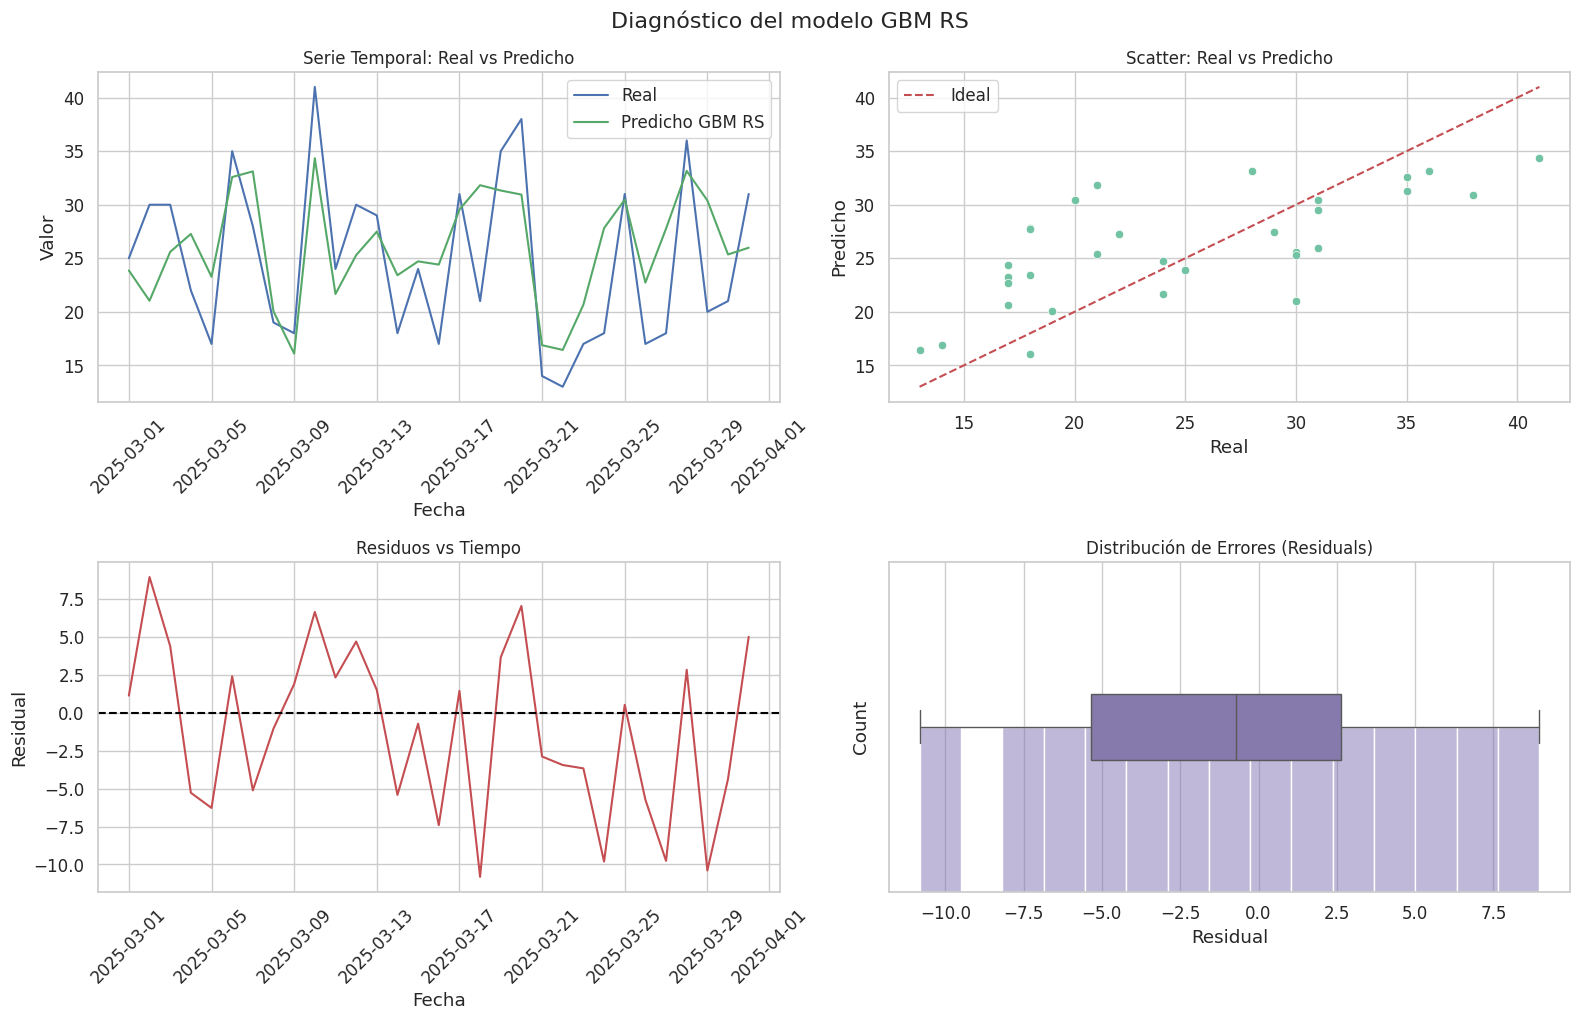

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Predicciones del GBM RS
pred_gbm_rs = gbm_opt.predict(test_h2o).as_data_frame().values.flatten()

# -------------------------
# Crear DataFrame de comparación usando la columna 'dia' de test_full
df_plot = pd.DataFrame({
    "Tiempo": test_full["dia"],   # <-- eje temporal correcto
    "Real": y_test.values,
    "Predicho": pred_gbm_rs
})
df_plot["Residual"] = df_plot["Real"] - df_plot["Predicho"]

# -------------------------
# Estilo general
sns.set(style="whitegrid", font_scale=1.1)

# -------------------------
# Crear figura con 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# 1️⃣ Línea temporal: real vs predicho
axes[0].plot(df_plot["Tiempo"], df_plot["Real"], label="Real", color="#4c72b0")
axes[0].plot(df_plot["Tiempo"], df_plot["Predicho"], label="Predicho GBM RS", color="#55a868")
axes[0].set_title("Serie Temporal: Real vs Predicho", fontsize=12)
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Valor")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 2️⃣ Scatter plot: real vs predicho
sns.scatterplot(x="Real", y="Predicho", data=df_plot, ax=axes[1], color="#72c3a3")
axes[1].plot([df_plot["Real"].min(), df_plot["Real"].max()],
             [df_plot["Real"].min(), df_plot["Real"].max()],
             'r--', label="Ideal")
axes[1].set_title("Scatter: Real vs Predicho", fontsize=12)
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Predicho")
axes[1].legend()

# 3️⃣ Residuos vs tiempo
axes[2].plot(df_plot["Tiempo"], df_plot["Residual"], color="#c44e52")
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title("Residuos vs Tiempo", fontsize=12)
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Residual")
axes[2].tick_params(axis='x', rotation=45)

# 4️⃣ Histograma + boxplot de errores
sns.histplot(df_plot["Residual"], bins=15, kde=True, ax=axes[3], color="#8172b3")
sns.boxplot(x=df_plot["Residual"], ax=axes[3], color="#8172b3", width=0.2)
axes[3].set_title("Distribución de Errores (Residuals)", fontsize=12)
axes[3].set_xlabel("Residual")

# -------------------------
plt.tight_layout()
plt.suptitle("Diagnóstico del modelo GBM RS", fontsize=16, y=1.02)
plt.show()

